> ### STATUS - annotated 2026-08-12 by agent `nb-banner-1217`. Nothing below this banner was rewritten.
>
> **What this notebook decided.** The three stage-C2b verdicts: **H-BFI not refuted** (0.01625
> against a gate of 0.02845, with the weak-power caveat that travels with it), **H-PEAK
> REFUTED** (fleet-median `R_AMS` 0.820, outside [0.85, 1.15]), and the registered **H2E-S**
> peak refit **REJECTED** on 2 of its 3 pre-registered conditions - it fixed the peaks and was
> rejected anyway.
>
> **All three still stand.** `docs/33` §6.2, §7.1 and §8 own these verdicts and carry the same
> numbers. `docs/36` then adjudicated the structural peak deficit across three research lenses
> and **recommended not pursuing a fix**, so §7's *"no further refit"* is now the project's
> position and not just this page's. The adopted configuration **H2E** remains the Phase C
> driver set.
>
> **One reading note.** `R_POT` **0.5672** here is a **fleet median of per-gauge ratios** over
> 63 gauges (per-gauge **IQR** 0.155-1.141 - that is the label `docs/36` §1's table gives that
> pair, and it is *not* a range: §5.6 measures the full per-gauge range as 0.0 to 5.4, four gauges
> producing zero simulated exceedances) - the same statistic and the same IQR `docs/36` prints as
> 0.567. The pooled figure, **0.5747**, is a different aggregation (1,285 simulated events over
> 2,236 observed) and `docs/36` carries that one too. They are not in conflict; quote the
> aggregation with the number.
>
> **Where things have moved since, downstream of this page.** §5.10 and §7.5 hand forward to C3
> and C4. **C3 is still OPEN**, re-issued as `docs/37` **Amendment A1** (2026-08-11), and
> **C4.3 is BLOCKED until the LS level lands** (`docs/47`); when it unblocks, C4 is held to
> `docs/42`'s guards G1-G9.
>
> ### UPDATE - 2026-08-19. The 2026-08-12 banner above is left exactly as written; this block supersedes its last paragraph only.
>
> **The three C2b verdicts are untouched.** What has moved is everything downstream of them.
>
> - **The LS level landed** on 2026-08-12 (`ls_formulation = buarque_2015_dg`, i.e. `V4_dg`;
>   `f_LS` = 0.25146 erosion-weighted / 0.2446790094097074 area-weighted), so `docs/47`'s
>   `C4.3-BLOCKED-UNTIL-LS-LANDS` is **discharged**. C4.3 has since run and its verdict is
>   **RAILED / EXPLORATORY - not adopted** (`docs/55`: the in-box optimum sits on the box floor,
>   the unconstrained optimum wants α ≈ 0.48 below it, the condition number is `inf`, and only the
>   product Π is identifiable). The line above - "C4.3 is BLOCKED" - was true when written and is
>   **superseded**.
> - **C5 has run and REPRODUCED the observed contrast**: 18 of 18 stations in the same direction,
>   median modelled rate ratio **3.05x** (range 1.62-4.85), against `docs/34`'s model-free 22 of 22
>   (`docs/56`). That is the project's headline result, and **Phase C is complete**.
> - **§5.9's own trigger is now in play, and this page does NOT adjudicate it.** §5.9 wrote: *"if
>   the simulated contrast were ever to come within 10 % of the observed one, the caveat would stop
>   being a caveat and become a refutation."* `docs/56` names estimator **(b)** as the reference for
>   judging the model and prints observed **2.84-2.95** against modelled **3.05**. Whether that
>   engages the clause is `docs/56`'s call, and **it has not been made**. Nothing here decides it.
> - **The lower-bound framing of §5.10 and §7.5 survives** the C4.3 railing: `docs/56` §2 shows the
>   within-station wet/dry ratio is invariant to α and to the LS level, both being static
>   multipliers that cancel.

# Notebook 17 - stage C2b: validating the two quantities the sediment model consumes

**Read this first if you have never seen the project.** Everything below is about a rainfall-runoff
model of the Magdalena-Cauca river basin in Colombia, built so that a *sediment* model can be
hung on top of it. The sediment model does not consume "discharge". It consumes two specific
pieces of the discharge: the part of the flow that arrived over the ground surface, and the size
of the flood peak. This notebook asks whether those two pieces are right, and answers: **one is
not refutable with the test that was written, and the other is measurably wrong.**

**Vocabulary is defined at first use, in plain language, before any formula.** No prior knowledge
of hydrological modelling is assumed.

---

## What this notebook is

Stage C2b of Phase C. It has four parts and they are not equally comfortable reading:

| part | question | answer |
|---|---|---|
| **1. Framing** | why validate *these two* quantities rather than discharge? | because the sediment equation reads them directly, and the discharge objective is blind to both |
| **2. H-BFI** | does the model split water into fast and slow flow the way the rivers do? | **not refuted** - median error 0.0163 against a gate of 0.0285 - *but the test had weak power, and that caveat matters as much as the result* |
| **3. H-PEAK** | does the model reproduce flood peaks? | **REFUTED.** Annual maxima are 18 % low, and 81.8 % of observed flood events have no simulated counterpart within +/-2 days |
| **4. The refit** | can a parameter refit fix the peaks? | **it fixed them and was REJECTED anyway**, on 2 of 3 conditions fixed in advance. It bought peaks by deleting canopy interception - the rainfall that leaves catch and that never reaches the soil (defined in §6.4). |

**The fourth part is the most instructive and it is a failure.** A refit that reached its target and
was rejected on the criteria written before it ran tells you something a success cannot: that the
signature and the objective are in *conflict*, i.e. that the deficit is structural rather than a
calibration oversight. This notebook documents it at the same length it would have documented a
success, because that is where the evidential value is.

## What this notebook is NOT

- It is **not** a calibration. No search is launched here. The two search archives it reads were
  produced by separate processes in August 2026 and are read from disk.
- It does **not** re-run the hydrology. The simulated discharge is read from the frozen file
  `data/processed/sim_calibrated_v2/q_gauge_H2E.npz`.
- It does **not** publish any sediment yield in tonnes per square kilometre per year. Catchment
  areas in this basin disagree by more than a factor of two on 36 % of shared gauges between the two
  available inventories (`docs/23` §13.2), so any per-area yield inherits that error one for one.
  Absolute fluxes and model-internal quantities only, and where a model-internal specific erosion
  appears it is labelled as such.

**Honesty rules applied throughout.** Every number quoted in prose was printed by a cell in this
notebook; where a project document states a number that this notebook's recomputation does not
reproduce, **the disagreement is reported rather than smoothed** (§8 collects four of them). Every
claim about a period the model was not fitted on is labelled a prediction. Every choice names the
alternative it rejected.

## 0.1 - Where every number comes from

This cell only **loads and checks**. It produces no scientific result; it exists so that nothing
later is improvised if a file is missing, and so that the provenance of every table is visible on
one screen.

Inputs, all read-only:

| file | what it holds | shape / size checked below |
|---|---|---|
| `sim_calibrated_v2/q_gauge_H2E.npz` | the **frozen** simulated and observed daily discharge at 63 gauges, 2009-2018 | `(3652, 63)` float32 |
| `model_inputs_v2/discharge.npz` | the observed record with its validity mask, and the flag marking the 63 usable gauges | mask sums to 63 |
| `c2b/bfi_per_gauge.csv`, `bfi_summary.json` | the committed flow-partition measurement (63 rows) | 63 rows |
| `c2b/peaks_per_gauge.csv`, `peaks_summary.json` | the committed flood-peak measurement (63 rows) | 63 rows |
| `peakgap/summary.json`, `events.csv`, `match_sensitivity.csv`, `per_gauge.csv` | the follow-up event-by-event diagnosis: 2,236 observed flood events with their class | 2,236 rows |
| `_calib_cache/dds_H2E-S_20260907.npz`, `_20260908.npz` | the two **refit** search archives: 1,000 evaluations each, with the per-gauge objective terms of every evaluation | 1,000 x 63 |
| `_calib_cache/dds_H2E_20260901.npz`, `_20260902.npz` | the two **incumbent** search archives | 1,000 evaluations |
| `sim_calibrated_v2/parameters_H2E.csv` | the adopted parameter set with each value's position inside its own range | 18 rows |
| `sim_calibrated_v2/metrics_fleet.csv` | the adopted configuration's skill scores per period | 12 rows for cell H2E |
| `src/baseflow.py`, `src/calib_v2.py` | the frozen filter and the frozen objective, imported rather than re-implemented | sha256 recorded |

The unit convention for the whole notebook: **discharge in m$^3$ s$^{-1}$**, **areas in km$^2$**,
**time in days**, and every ratio dimensionless.

In [1]:
import json, pathlib, sys, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': False, 'font.size': 9,
                     'figure.autolayout': False})

REPO = None
for b in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
    if (b / 'src' / 'calib_v2.py').exists() and (b / 'data' / 'processed').exists():
        REPO = b
        break
if REPO is None:
    raise SystemExit('cannot locate the repository root')
PROC = REPO / 'data' / 'processed'
sys.path.insert(0, str(REPO / 'src'))

NEED = {
    'q_gauge': PROC / 'sim_calibrated_v2' / 'q_gauge_H2E.npz',
    'params': PROC / 'sim_calibrated_v2' / 'parameters_H2E.csv',
    'metrics': PROC / 'sim_calibrated_v2' / 'metrics_fleet.csv',
    'report': PROC / 'sim_calibrated_v2' / 'report_H2E.json',
    'discharge': PROC / 'model_inputs_v2' / 'discharge.npz',
    'bfi_csv': PROC / 'c2b' / 'bfi_per_gauge.csv',
    'bfi_json': PROC / 'c2b' / 'bfi_summary.json',
    'pk_csv': PROC / 'c2b' / 'peaks_per_gauge.csv',
    'pk_json': PROC / 'c2b' / 'peaks_summary.json',
    'gap_json': PROC / 'peakgap' / 'summary.json',
    'gap_events': PROC / 'peakgap' / 'events.csv',
    'gap_match': PROC / 'peakgap' / 'match_sensitivity.csv',
    'gap_gauge': PROC / 'peakgap' / 'per_gauge.csv',
    'refit_07': PROC / '_calib_cache' / 'dds_H2E-S_20260907.npz',
    'refit_08': PROC / '_calib_cache' / 'dds_H2E-S_20260908.npz',
    'inc_01': PROC / '_calib_cache' / 'dds_H2E_20260901.npz',
    'inc_02': PROC / '_calib_cache' / 'dds_H2E_20260902.npz',
    'baseflow': REPO / 'src' / 'baseflow.py',
    'calib': REPO / 'src' / 'calib_v2.py',
    'peaks_src': REPO / 'scripts' / 'c2b' / 'peaks_measure.py',
}
missing = {k: str(v) for k, v in NEED.items() if not v.exists()}
if missing:
    raise SystemExit(f'PREREQUISITES MISSING, stopping rather than improvising: {missing}')
for k, v in NEED.items():
    h = hashlib.sha256(v.read_bytes()).hexdigest()[:12] if v.stat().st_size < 20e6 else '(large)'
    print(f'{k:<10} {v.stat().st_size/1e6:9.3f} MB  sha256 {h}  {v.relative_to(REPO)}')

import calib_v2 as CV        # the FROZEN objective: bounds, blend, recession, peak term
import baseflow as BF        # the FROZEN Eckhardt filter (docs/33 s2.1)
print(f'\nimported calib_v2 and baseflow from {REPO / "src"}')

q_gauge        3.018 MB  sha256 d545d98a8b6e  data\processed\sim_calibrated_v2\q_gauge_H2E.npz
params         0.001 MB  sha256 cfe68790db22  data\processed\sim_calibrated_v2\parameters_H2E.csv
metrics        0.008 MB  sha256 c8052df034a4  data\processed\sim_calibrated_v2\metrics_fleet.csv
report         0.006 MB  sha256 60df921d7fb4  data\processed\sim_calibrated_v2\report_H2E.json
discharge      1.083 MB  sha256 ded15f418b45  data\processed\model_inputs_v2\discharge.npz
bfi_csv        0.029 MB  sha256 ec4cca9e2613  data\processed\c2b\bfi_per_gauge.csv
bfi_json       0.005 MB  sha256 a73a566afd32  data\processed\c2b\bfi_summary.json
pk_csv         0.045 MB  sha256 0831cfb3aaaf  data\processed\c2b\peaks_per_gauge.csv
pk_json        0.009 MB  sha256 b8e83a455c17  data\processed\c2b\peaks_summary.json
gap_json       0.016 MB  sha256 8a834c1f4424  data\processed\peakgap\summary.json
gap_events     1.180 MB  sha256 a298ba0d9436  data\processed\peakgap\events.csv
gap_match      0.013 MB  sha

In [2]:
# ---- the frozen discharge, and the observed validity mask that pairs the two series ----
S = np.load(NEED['q_gauge'], allow_pickle=True)
DIS = dict(np.load(NEED['discharge'], allow_pickle=True))

DATES = pd.DatetimeIndex(S['dates'].astype('datetime64[ns]'))
YEAR = DATES.year.to_numpy()
GC = S['gauge_code'].astype(str)
AREA = S['gauge_upstream_area_km2'].astype(float)
QOBS = S['q_obs_m3s'].astype(np.float64)      # observed daily mean discharge, m3/s
QSIM = S['q_sim_fit_m3s'].astype(np.float64)  # simulated, adopted parameters, m3/s
QCLIM = S['q_clim_m3s'].astype(np.float64)    # day-of-year climatology benchmark, m3/s
NT, NG = QOBS.shape

cs = DIS['is_calibration_safe']
i0 = int(np.searchsorted(DIS['dates'], S['dates'][0]))
QVALID = DIS['q_valid'][i0:i0 + NT][:, cs]    # True where the gauge reported that day

assert int(cs.sum()) == NG == 63
assert np.array_equal(DIS['gauge_code'][cs].astype(str), GC)
assert np.array_equal(DIS['dates'][i0:i0 + NT], S['dates'])
assert np.array_equal(np.isnan(QOBS), ~QVALID), 'the npz NaN pattern must equal the validity mask'
assert np.isfinite(QSIM).all(), 'the simulation has no missing days by construction'

print(f'days   {NT}  {DATES[0].date()} .. {DATES[-1].date()}   (2008 is warm-up and absent)')
print(f'gauges {NG} calibration-safe, upstream area {AREA.min():,.0f} .. {AREA.max():,.0f} km2')
print(f'observed valid gauge-days {int(QVALID.sum()):,} of {QVALID.size:,} '
      f'({100*QVALID.mean():.1f} %), missing {int((~QVALID).sum()):,}')

BFI = pd.read_csv(NEED['bfi_csv']); BFI['gauge'] = BFI['gauge'].astype(str)
BSUM = json.loads(NEED['bfi_json'].read_text())
PK = pd.read_csv(NEED['pk_csv']); PK['gauge'] = PK['gauge'].astype(str)
PSUM = json.loads(NEED['pk_json'].read_text())
GAP = json.loads(NEED['gap_json'].read_text())
EV = pd.read_csv(NEED['gap_events'])
MSENS = pd.read_csv(NEED['gap_match'])
PGAP = pd.read_csv(NEED['gap_gauge'])
PARH2E = pd.read_csv(NEED['params'])
MET = pd.read_csv(NEED['metrics'])
print(f'\nBFI table {BFI.shape}, peaks table {PK.shape}, events {EV.shape}, '
      f'match sensitivity {MSENS.shape}, per-gauge event table {PGAP.shape}')
print(f'H2E parameter table {PARH2E.shape}, fleet metrics {MET.shape} '
      f'({int((MET["cell"]=="H2E").sum())} rows for cell H2E)')

days   3652  2009-01-01 .. 2018-12-31   (2008 is warm-up and absent)
gauges 63 calibration-safe, upstream area 68 .. 257,097 km2
observed valid gauge-days 179,612 of 230,076 (78.1 %), missing 50,464

BFI table (63, 36), peaks table (63, 55), events (2236, 36), match sensitivity (630, 5), per-gauge event table (63, 7)
H2E parameter table (18, 8), fleet metrics (39, 15) (12 rows for cell H2E)


**What that check bought.** Two things that would otherwise be assumptions. First, the simulated
and observed arrays in the frozen file are **paired day for day**: the NaN pattern of the observed
column is *exactly* the gauge's validity mask, so no comparison below can accidentally score the
model on a day the river was not measured. Second, the date axis and the gauge list agree with the
input bundle element by element, so "gauge 5" means the same river in every table.

## 0.2 - Every threshold in one place, before any result

These constants are **not chosen by this notebook**. They were fixed in `docs/33`, a
**pre-registration**: a document written and frozen *before* the measurements, which fixes the
hypotheses, the statistic that would refute each one, and the numerical bar. The point of writing
one is that a threshold chosen after seeing the answer is not a test - it is a description. Putting
them in a single cell here means a reader can see that nothing downstream moved a bar to fit a
result.

$$\text{H-BFI refuted} \iff \operatorname{median}_{g}\bigl|\mathrm{BFI}^{\text{sim}}_g -
\mathrm{BFI}^{\text{obs}}_g\bigr| \;>\; \mathrm{IQR}_g\bigl(\mathrm{BFI}^{\text{obs}}\bigr)$$

$$\text{H-PEAK refuted} \iff R_{\mathrm{AMS}} \notin [0.85,\,1.15]
\;\;\text{or}\;\; R_{\mathrm{Q1}} \notin [0.85,\,1.15]$$

where $g$ indexes gauges, $\mathrm{BFI}$ is the baseflow index (§3, dimensionless, in $[0,1]$),
$\mathrm{IQR}$ is the interquartile range $p_{75}-p_{25}$ over gauges (dimensionless), and
$R_{\mathrm{AMS}}$, $R_{\mathrm{Q1}}$ are ratios of simulated to observed flow magnitudes (§5,
dimensionless). The refit's three success conditions are stated in §6.

In [3]:
# ---- pre-registered constants, docs/33. NOTHING below re-derives or adjusts any of these ----
BFIMAX = BF.BFIMAX                  # 0.80, the Eckhardt filter's fixed maximum baseflow index
BFIMAX_ROBUST = BF.BFIMAX_ROBUST    # 0.50, reported alongside, CANNOT change a verdict
PEAK_BAND = (0.85, 1.15)            # docs/33 s1: the H-PEAK acceptance band on R_AMS and R_Q1
F_H2E = 0.25930593639066796         # incumbent objective value, dds_H2E_20260901.npz
F_BUDGET = 0.02                     # docs/33 s3.5 condition 2: |F_refit - F_H2E| <= 0.02
RAIL = 0.05                         # docs/33 s3.5 condition 3: "railed" = within 5 % of a bound
BETA_MUSLE = 0.56                   # MUSLE's exponent on (Qsur * qpeak * A); Williams (1975)
H2E_RAILED = {'k_sup@global', 'k_int_frac@global', 'wm_mult@R2'}   # the incumbent's railed set
MIN_SEG, MAX_GAP, MIN_YEAR_DAYS = 180, 3, 300   # docs/33 s2.1, s2.3(a) day-set rules
MIN_SCORED_DAYS = BF.MIN_SCORED_DAYS            # 1095: a gauge needs 3 yr for the BFI statistic

# the incumbent F is read from the archive, not trusted to the literal above
_inc = np.load(NEED['inc_01'], allow_pickle=True)
_inc2 = np.load(NEED['inc_02'], allow_pickle=True)
print(f'incumbent H2E: seed 20260901 F = {float(_inc["f"][0]):.17f}')
print(f'               seed 20260902 F = {float(_inc2["f"][0]):.17f}  (the weaker seed)')
assert float(_inc['f'][0]) == F_H2E, 'the literal F_H2E must equal the archived value'
print(f'\nH-PEAK band {PEAK_BAND}   F budget +/-{F_BUDGET}  -> '
      f'[{F_H2E-F_BUDGET:.5f}, {F_H2E+F_BUDGET:.5f}]')
print(f'rail definition: position < {RAIL} or > {1-RAIL} of a parameter\'s own range')
print(f'incumbent railed set: {sorted(H2E_RAILED)}')
print(f'MUSLE peak exponent beta = {BETA_MUSLE}')

incumbent H2E: seed 20260901 F = 0.25930593639066796
               seed 20260902 F = 0.24671195678891705  (the weaker seed)

H-PEAK band (0.85, 1.15)   F budget +/-0.02  -> [0.23931, 0.27931]
rail definition: position < 0.05 or > 0.95 of a parameter's own range
incumbent railed set: ['k_int_frac@global', 'k_sup@global', 'wm_mult@R2']
MUSLE peak exponent beta = 0.56


---

# 1 - Why this stage exists

## 1.1 - The sediment equation reads two things, and neither had ever been checked

The model is spatially discretised into **minibacias** - small elementary catchments, 8,672 of
them here, each a few tens of km$^2$, each draining into the next one downstream. Inside a
minibacia the land is not treated as uniform: it is divided into **URH** (*unidades de resposta
hidrológica*, hydrological response units, HRUs) - classes of land that behave alike
hydrologically, formed by crossing land cover with soil type. There are 24 of them here. Each URH
carries its own **water balance**: a bookkeeping identity that says water in equals water out plus
change in storage, applied daily to a soil store,

$$\frac{\mathrm{d}W}{\mathrm{d}t} = P - ET - Q_{\text{sur}} - Q_{\text{int}} - Q_{\text{bas}}$$

with $W$ the water stored in the soil column (mm), $P$ rainfall (mm d$^{-1}$), $ET$ the water
actually evaporated and transpired (mm d$^{-1}$), and the three $Q$ terms the ways water leaves
sideways (mm d$^{-1}$):

- **surface runoff** $Q_{\text{sur}}$ - water that leaves over the ground. In this model family it
  is generated by **saturation excess**: rain that falls on ground whose soil store is already
  full has nowhere to go and runs off. (The alternative mechanism, *infiltration excess*, where
  rain simply falls faster than the soil can absorb it however dry the soil, is **not** in this
  model. §7 returns to that, because it was tested as a candidate explanation and refuted.)
- **subsurface runoff** $Q_{\text{int}}$ - lateral flow through the shallow soil.
- **baseflow** $Q_{\text{bas}}$ - slow drainage from the deeper store, the flow that keeps a river
  running weeks after the last rain.

Sediment is then computed with **MUSLE** (the Modified Universal Soil Loss Equation, Williams
1975), applied per minibacia per day:

$$\mathrm{Sed} \;=\; \alpha \,\bigl(Q_{\text{sur}}\; q_{\text{peak}}\; A\bigr)^{\beta}
\; K \; C \; P \; LS$$

| symbol | meaning | units |
|---|---|---|
| $\mathrm{Sed}$ | sediment mass detached and delivered from that minibacia that day | t d$^{-1}$ |
| $Q_{\text{sur}}$ | **surface runoff depth** that day | mm |
| $q_{\text{peak}}$ | **peak flow rate** of the event | m$^3$ s$^{-1}$ |
| $A$ | minibacia area | km$^2$ |
| $\alpha,\ \beta$ | empirical scale and exponent; $\beta \approx 0.56$ | dimensionless |
| $K$ | soil erodibility - how easily this soil detaches | t ha h ha$^{-1}$ MJ$^{-1}$ mm$^{-1}$ |
| $C$ | cover-management factor - the protective effect of vegetation, 0 (armoured) to 1 (bare) | dimensionless |
| $P$ | support-practice factor - the effect of terracing, contour ploughing etc., $\le 1$ | dimensionless |
| $LS$ | slope-length-steepness factor - the topographic amplification | dimensionless |

**Read the equation and the point of this whole stage falls out.** Of the whole water balance,
MUSLE consumes exactly two hydrological quantities: $Q_{\text{sur}}$ and $q_{\text{peak}}$. It
never sees total discharge. It never sees baseflow at all - which is physically right, because
water seeping out of an aquifer carries no soil with it: **only the fast, surface part of the flow
detaches and transports sediment**. The quantity the sediment model is most sensitive to is
therefore the *fast fraction* of the flow and the *height of the flood peak*, and until stage C2b
neither had ever been compared with an observation.

The measurement target on the sediment side is **SSC**, suspended-sediment concentration
(mg L$^{-1}$): the mass of solid particles carried per litre of river water, measured by filtering
a physical sample. Observed sediment *flux* is SSC times same-day observed discharge.

### 1.1.1 - How hard a peak error hits sediment

MUSLE's peak dependence is a power law, so a *relative* error in peak flow becomes a *relative*
error in sediment, damped by the exponent:

$$\frac{\mathrm{Sed}^{\text{sim}}}{\mathrm{Sed}^{\text{obs}}}
= \left(\frac{q_{\text{peak}}^{\text{sim}}}{q_{\text{peak}}^{\text{obs}}}\right)^{\beta}
= R^{\beta}, \qquad
\frac{\partial \ln \mathrm{Sed}}{\partial \ln q_{\text{peak}}} = \beta = 0.56$$

where $R$ is a simulated-to-observed peak ratio (dimensionless) and $\beta = 0.56$ is Williams
(1975)'s exponent, inherited from `docs/31` §0 and **not fitted here**. The cell below evaluates
$R^{\beta}$ at five measured peak ratios. **Four** are fleet medians read from
`c2b/peaks_summary.json` and are the ones §5 measures; the **fifth**, the *event-matched* ratio
0.552, is carried as a literal from `docs/33` §7.6 - which is what the printed label `(S7.6)`
refers to, a section of the **pre-registration** and not of this notebook, whose §7 stops at §7.5.
§5 does not measure it, and §5.10 records a 0.006 arithmetic disagreement with `docs/33` §7.7 about
its propagation. Output is a dimensionless sediment ratio per input.

peak statistic                 R   R^0.56  sediment bias
R_Q5  5 % exceedance      0.9746   0.9857          -1.4 %
R_Q1  1 % exceedance      0.8470   0.9112          -8.9 %
R_AMS annual maxima       0.8200   0.8948         -10.5 %
R_AMS El Nino 15-16       0.6857   0.8095         -19.0 %
event-matched (S7.6)      0.5520   0.7169         -28.3 %


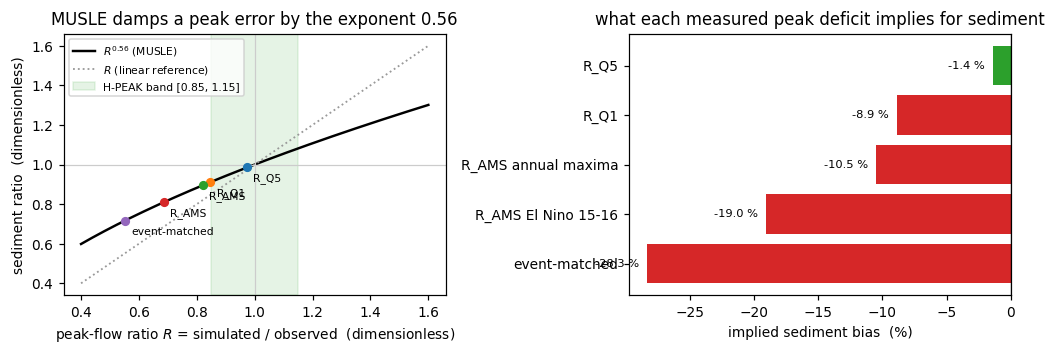

In [4]:
RVALS = [('R_Q5  5 % exceedance', PSUM['R_Q5']['med']),
         ('R_Q1  1 % exceedance', PSUM['R_Q1']['med']),
         ('R_AMS annual maxima', PSUM['R_AMS']['med']),
         ('R_AMS El Nino 15-16', PSUM['by_period']['VAL El Nino 15-16']['R_AMS']['med']),
         ('event-matched (S7.6)', 0.552)]
print(f'{"peak statistic":<24}{"R":>8}{"R^0.56":>9}{"sediment bias":>15}')
for nm, R in RVALS:
    print(f'{nm:<24}{R:8.4f}{R**BETA_MUSLE:9.4f}{100*(R**BETA_MUSLE-1):+14.1f} %')

fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.3))
r = np.linspace(0.4, 1.6, 400)
ax[0].plot(r, r ** BETA_MUSLE, 'k-', lw=1.6, label=r'$R^{0.56}$ (MUSLE)')
ax[0].plot(r, r, color='0.6', ls=':', lw=1.2, label=r'$R$ (linear reference)')
ax[0].axhline(1, color='0.8', lw=0.8); ax[0].axvline(1, color='0.8', lw=0.8)
for nm, R in RVALS:
    ax[0].plot([R], [R ** BETA_MUSLE], 'o', ms=5)
    ax[0].annotate(nm.split()[0], (R, R ** BETA_MUSLE), textcoords='offset points',
                   xytext=(4, -9), fontsize=7)
ax[0].axvspan(*PEAK_BAND, color='tab:green', alpha=0.12,
              label='H-PEAK band [0.85, 1.15]')
ax[0].set_xlabel('peak-flow ratio $R$ = simulated / observed  (dimensionless)')
ax[0].set_ylabel('sediment ratio  (dimensionless)')
ax[0].set_title('MUSLE damps a peak error by the exponent 0.56')
ax[0].legend(fontsize=7, loc='upper left')

lab = [n.split('  ')[0].split(' (')[0] for n, _ in RVALS]
bias = [100 * (R ** BETA_MUSLE - 1) for _, R in RVALS]
cols = ['tab:green' if PEAK_BAND[0] <= R <= PEAK_BAND[1] else 'tab:red' for _, R in RVALS]
ax[1].barh(lab, bias, color=cols)
ax[1].axvline(0, color='k', lw=0.8)
for y, (b, (_, R)) in enumerate(zip(bias, RVALS)):
    ax[1].text(b - 0.6, y, f'{b:+.1f} %', va='center', ha='right', fontsize=7.5)
ax[1].set_xlabel('implied sediment bias  (%)')
ax[1].set_title('what each measured peak deficit implies for sediment')
ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the black curve is $R^{0.56}$, the factor by which MUSLE scales
sediment when peak flow is wrong by a factor $R$; the dotted grey line is $R$ itself, for
reference, so the vertical gap between them is the damping the exponent provides. The green band
is the pre-registered acceptance band for the peak ratio. The five dots are the peak statistics
§5 measures. *Right:* the same five, as the percentage sediment bias each implies; green means the
peak ratio is inside the acceptance band, red means outside. Both axes dimensionless except the
right-hand bar axis, which is a percentage.

**What it shows.** The exponent is a strong damper: a peak ratio of 0.820 - an 18.0 % peak
deficit - becomes a sediment factor of 0.895, i.e. **-10.5 %**. The 5 %-exceedance ratio 0.9746
implies only -1.4 %. The El Niño annual-maximum ratio 0.6857 implies **-19.0 %**, and the
strictest, event-matched ratio of 0.552 implies **-28.3 %**.

**What it means.** Two things, and they pull in opposite directions. The damping is *good news*
for the deliverable: a large peak error becomes a moderate sediment error, which is why a peak
deficit qualifies the sediment result rather than destroying it. But the damping is also why the
pre-registered band was set at $\pm 15$ %: $1.15^{0.56}-1 \approx +8$ % sits below the
rating-curve uncertainty the observed sediment target already carries (a **rating curve** is the
empirical relation used to convert a measured river water level into a discharge; it is fitted to a
handful of physical gaugings and extrapolated at high flow, which is where it is least reliable;
the median $R^2$ of this basin's sediment rating curves is 0.54, a figure inherited from `docs/31`
§0 and not computed here), so an error inside the band
is not the dominant term in the sediment error budget and an error outside it starts to be. The
band is not arbitrary - it is where peak error stops being negligible.

## 1.2 - What Phase B actually optimised, and why it cannot see either quantity

The model's parameters were fitted in Phase B by minimising an **objective function** - a single
number summarising how badly the simulation matches observation, which a search algorithm then
tries to improve. That objective was built entirely out of **total discharge at the gauge**. Its
ingredients, each defined once here because all of them recur:

**KGE**, the Kling-Gupta efficiency, is the workhorse. It decomposes the match into three
independent failures and penalises each:

$$\mathrm{KGE} = 1 - \sqrt{(r-1)^2 + (\alpha-1)^2 + (\beta-1)^2}, \qquad
r = \mathrm{corr}(s, o), \quad \alpha = \frac{\sigma_s}{\sigma_o}, \quad
\beta = \frac{\mu_s}{\mu_o}$$

with $s$ simulated and $o$ observed daily discharge (m$^3$ s$^{-1}$), $\mu$ the mean and $\sigma$
the standard deviation over the scored days. All three components are dimensionless and all three
are 1 for a perfect simulation:

- $r$ - **timing and shape**. Does the simulated hydrograph rise and fall when the real one does?
  This is the component a rainfall field controls and a parameter cannot.
- $\alpha$ - **variability**. Is the simulation as *variable* as the river? $\alpha < 1$ means the
  simulated hydrograph is too flat: peaks too low, troughs too high.
- $\beta$ - **volume**. Is the total amount of water right? $\beta > 1$ means too much water.

KGE = 1 is perfect; KGE = 0 means no better than predicting the observed mean.

**PBIAS**, percentage bias, is the same information as $\beta$ in a friendlier form:
$\mathrm{PBIAS} = 100\,(\beta - 1)$ %, so $+5$ % means the model delivers 5 % too much water.

**NSE**, the Nash-Sutcliffe efficiency, is $1 - \sum(s-o)^2 / \sum(o-\bar o)^2$: one minus the
mean squared error normalised by the observed variance. NSE = 0 means the simulation is exactly as
good as predicting the observed **mean of that window**, which is why NSE is
**window-dependent** and treacherous: the same simulation scores differently on a window where
the river varies a lot than on a window where it does not, because the *benchmark itself* changes
with the window. That is why this project also carries an explicit
**climatology benchmark** - the day-of-year mean discharge, i.e. "what this river usually does on
this calendar day" - and reports **skill over climatology**, KGE(model) - KGE(climatology). A
model that cannot beat the calendar has learned nothing about *this particular year*.

**The search.** The algorithm is **DDS** (Dynamically Dimensioned Search, Tolson & Shoemaker
2007): start from a prior parameter vector, perturb a random subset of its dimensions - a subset
that shrinks as the budget is spent, so the search anneals from global to local - keep the new
point only if it scores better. It needs no derivatives and one control (the perturbation size),
which is why it is the standard choice for expensive hydrological objectives. Here: 1,000
evaluations per **seed** (a seed is one random-number stream, i.e. one independent search), two
seeds per configuration.

**The split.** Parameters were fitted on 2012-2014 only - three consecutive ENSO-neutral years -
and every other year is held out. This is **Klemeš (1986)'s differential split-sample test**: when
a model is going to be used to predict a *different climate regime*, it must be validated on a
period whose climate differs from the fitting period, not merely on different years of the same
regime. Since the project's headline result is a contrast between a wet La Niña (2011) and a dry
El Niño (2015-16), putting either extreme in the calibration window would make that result
circular.

**Two words for the failure modes that follow.** A **railed** parameter is one whose fitted value
sits against the edge of the range it was allowed to explore (here: within 5 % of a bound). It is
a warning, because it means the search wanted to go further and was stopped by the box, so the
"fitted" value is really a statement about the box. **Equifinality** is the property that many
different parameter sets reproduce the same aggregate behaviour equally well; it is why a good
objective value is not evidence that the internal workings are right.

**The blind spot, stated precisely.** The objective is a weighted mean of KGE on discharge, KGE on
log discharge, and a recession term - all functions of *total* flow at the gauge. Nothing in it
depends on how that flow was partitioned into surface / subsurface / baseflow, and its only
sensitivity to peaks is through $\alpha$, a whole-record standard-deviation ratio that a
ten-year record's annual maxima barely move. **Two parameter sets can score identically and hand
MUSLE completely different drivers.**

### 1.2.1 - The adopted configuration's own scorecard

This cell only selects and prints rows from `sim_calibrated_v2/metrics_fleet.csv` - the committed
skill table of the adopted configuration, cell **H2E** - and plots its three KGE components. No
metric is recomputed here; the file is the artifact of the Phase B run.

Columns used: `kge`, `r`, `alpha`, `beta`, `pbias` (%), `clim_kge`, `skill_over_clim`,
`rec_ratio` (simulated / observed recession constant, dimensionless), `n` (gauges scored). Rows:
`config == 'fit'` (the fitted parameters) against `config == 'prior'` (the un-fitted prior).

cell H2E, fitted parameters (data/processed/sim_calibrated_v2/metrics_fleet.csv)
            period      kge      nse        r    alpha     beta    pbias  clim_kge  skill_over_clim  rec_ratio  n
       CAL 2012-14   0.3216  -0.0883   0.5564   0.9196   0.9650  -3.5034    0.3361          -0.0145     1.0780 57
           VAL all   0.3563   0.1299   0.5912   0.9048   1.0351   3.5083    0.2672           0.0891     0.9816 63
    VAL La Nina 11   0.3439   0.1275   0.6519   0.9960   0.9458  -5.4186    0.2377           0.1062     1.1226 59
 VAL El Nino 15-16   0.2004  -0.2164   0.5848   0.9107   1.0748   7.4762    0.2009          -0.0005     0.9403 54
VAL other 09/10/17   0.3665   0.0886   0.6415   0.8927   1.0501   5.0076    0.2507           0.1158     1.1011 63
          VAL 2018   0.2507  -0.1739   0.5589   0.8831   1.0562   5.6246    0.3610          -0.1103     0.9489 56


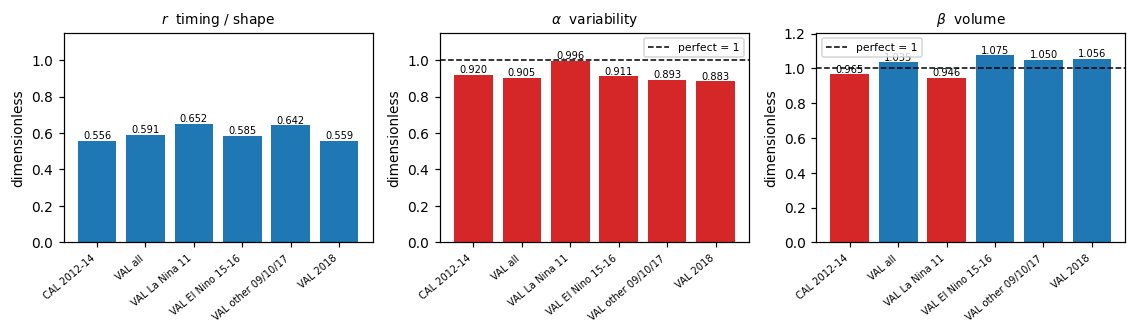

In [5]:
H = MET[(MET['cell'] == 'H2E') & (MET['config'] == 'fit')].copy()
cols = ['period', 'kge', 'nse', 'r', 'alpha', 'beta', 'pbias', 'clim_kge',
        'skill_over_clim', 'rec_ratio', 'n']
print('cell H2E, fitted parameters (data/processed/sim_calibrated_v2/metrics_fleet.csv)')
print(H[cols].to_string(index=False, float_format=lambda v: f'{v:8.4f}'))

fig, ax = plt.subplots(1, 3, figsize=(10.4, 3.1), sharey=False)
per = H['period'].tolist()
xx = np.arange(len(per))
for k, (c, nm, good) in enumerate([('r', r'$r$  timing / shape', None),
                                   ('alpha', r'$\alpha$  variability', 1.0),
                                   ('beta', r'$\beta$  volume', 1.0)]):
    v = H[c].to_numpy()
    col = ['tab:red' if (good is not None and vv < good) else 'tab:blue' for vv in v]
    ax[k].bar(xx, v, color=col)
    if good is not None:
        ax[k].axhline(good, color='k', lw=1.0, ls='--', label='perfect = 1')
        ax[k].legend(fontsize=7)
    for x, vv in zip(xx, v):
        ax[k].text(x, vv + 0.01, f'{vv:.3f}', ha='center', fontsize=6.5)
    ax[k].set_xticks(xx); ax[k].set_xticklabels(per, rotation=40, ha='right', fontsize=6.5)
    ax[k].set_title(nm, fontsize=9)
    ax[k].set_ylabel('dimensionless')
    ax[k].set_ylim(0, max(1.15, v.max() * 1.12))
plt.tight_layout(); plt.show()

**What is plotted.** The three KGE components of the adopted configuration, one panel each, by
period; bars are red where the component sits below its perfect value of 1 (dashed line), blue
otherwise. All three quantities are dimensionless. Periods: CAL 2012-14 is the fitting window;
every "VAL" row is held out.

**What it shows.** $r$ never exceeds 0.652 and sits at 0.585 in the El Niño window. $\alpha$ is
**below 1 in every single period** - 0.883 to 0.996, i.e. the simulated hydrograph is 0.4 % to
11.7 % less variable than the real one. $\beta$ is close to 1 everywhere (0.946 to 1.075), so
volume is essentially right: PBIAS on the full validation record is $+3.5$ %. Skill over
climatology is $+0.089$ over all validation years and $+0.106$ in La Niña 2011, but
$\mathbf{-0.0005}$ in El Niño 2015-16 and $-0.110$ in 2018.

**What it means.** The adopted model is a *volume-correct, variability-deficient* simulation whose
timing skill is capped near $r \approx 0.6$. The $\alpha < 1$ column is the load-bearing one for
this notebook: it is a direct, pre-existing warning that peaks are too low, visible in the
objective's own diagnostics before any peak-specific statistic was computed. §5 measures how big
that peak deficit is, and finds it is **about twice** what $\alpha$ implies - because $\alpha$ is
a whole-record dispersion ratio and the deficit lives in the extreme tail. Separately, the El Niño
skill of $-0.0005$ says that in the dry phase the model sits *exactly at* climatology: it has no
information about that year beyond the calendar. That is inherited context, established in
`docs/22` and `docs/26`, not a finding of this notebook.

## 1.3 - A demonstration: same volume, same score, different sediment driver

The claim in §1.2 - that the discharge objective cannot see the drivers - deserves a demonstration
rather than an assertion. This is a **synthetic** construction on real observed data, labelled as
such: no model output is involved.

Take the observed hydrograph $o(t)$ (m$^3$ s$^{-1}$) at one gauge and build two artificial
"models" from it:

$$A = \mu_o + (\,\overline{o}^{\,31} - \mu_{\overline o}) \frac{\sigma_o}{\sigma_{\overline o}},
\qquad
B = \mu_o + \operatorname{sgn}(o-\mu_o)\,|o-\mu_o|^{1.25} \;\text{(re-standardised)},
\;\text{then shifted 1 day late}$$

where $\overline{o}^{\,31}$ is a 31-day centred moving average (m$^3$ s$^{-1}$), $\mu$ and
$\sigma$ are the mean and standard deviation of the observed series, and each series is finally
rescaled multiplicatively so that its **total volume equals the observed total exactly**. $A$ is
a deliberately over-smooth model; $B$ a deliberately flashy one that is also one day late. The
exponent 1.25 and the 1-day shift were chosen for one stated reason: to bring $B$'s KGE close to
$A$'s, so the comparison isolates what the score *cannot* see. Both series are then filtered for
their baseflow index with the same filter §3 defines, and their annual-maximum ratio computed as
§5 defines it. Units: discharge m$^3$ s$^{-1}$; volume m$^3$ s$^{-1}$ summed over days; BFI and
all ratios dimensionless.

gauge 21147030, 1,600 km2, 3541 valid days, filter a = 0.8057
series       volume/obs     KGE      r  alpha   beta     BFI  quickflow   R_AMS  MUSLE q^0.56
observed       1.000000  1.0000  1.000  1.000  1.000  0.7875     0.2125   1.000         1.000
A smooth       1.000000  0.6928  0.697  0.946  1.000  0.7998     0.2002   0.488         0.669
B flashy       0.999899  0.6647  0.665  1.000  1.000  0.7867     0.2133   1.083         1.046

KGE differs by 0.0280; annual maxima differ by 2.22x; MUSLE peak factor differs by 1.56x; quickflow share differs by 0.0131 (absolute BFI)


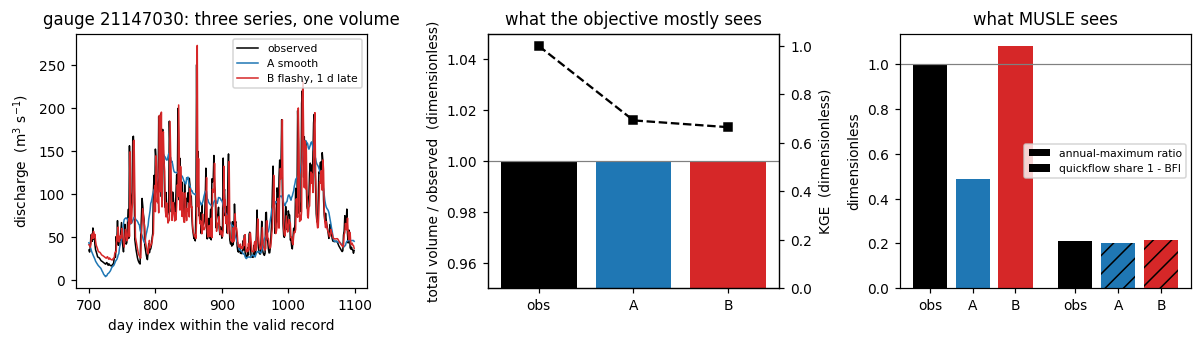

In [6]:
GEX = '21147030'          # chosen in S3.4: long record, mid-size, near-median BFI difference
jx = int(np.flatnonzero(GC == GEX)[0])
row_ex = BFI[BFI['gauge'] == GEX].iloc[0]
a_ex = float(row_ex['a'])
vex = QVALID[:, jx] & np.isfinite(QOBS[:, jx])
y = QOBS[vex, jx]
mu, sd = y.mean(), y.std()


def _to_volume(x):
    # clip at 2 % of the mean, then rescale so the total volume matches the observed exactly
    x = np.maximum(x, 0.02 * mu)
    return x * (y.sum() / x.sum())


w = 31
sm = np.convolve(np.r_[np.full(w, y[0]), y, np.full(w, y[-1])],
                 np.ones(w) / w, 'same')[w:w + y.size]
A = _to_volume(mu + (sm - sm.mean()) * (sd / sm.std()))
dev = y - mu
B = mu + np.sign(dev) * np.abs(dev) ** 1.25
B = _to_volume(mu + (B - B.mean()) * (sd / B.std()))
B = np.r_[np.full(1, B[0]), B[:-1]]          # one day late


def _bfi_of(vals):
    full = np.full(NT, np.nan); full[vex] = vals
    return BF.bfi_series(full, vex, a_ex, BFIMAX)['bfi']


def _ams_of(vals):
    full = np.full(NT, np.nan); full[vex] = vals
    rr = []
    for yy in range(2009, 2019):
        m = vex & (YEAR == yy)
        if m.sum() < MIN_YEAR_DAYS:
            continue
        mo = QOBS[m, jx].max()
        if mo > 0:
            rr.append(np.nanmax(full[m]) / mo)
    return float(np.median(rr))


bfi_o = _bfi_of(y)
print(f'gauge {GEX}, {AREA[jx]:,.0f} km2, {vex.sum()} valid days, filter a = {a_ex:.4f}')
print(f'{"series":<12}{"volume/obs":>11}{"KGE":>8}{"r":>7}{"alpha":>7}{"beta":>7}'
      f'{"BFI":>8}{"quickflow":>11}{"R_AMS":>8}{"MUSLE q^0.56":>14}')
print(f'{"observed":<12}{1.0:11.6f}{1.0:8.4f}{1.0:7.3f}{1.0:7.3f}{1.0:7.3f}'
      f'{bfi_o:8.4f}{1-bfi_o:11.4f}{1.0:8.3f}{1.0:14.3f}')
res = {}
for nm, x in (('A smooth', A), ('B flashy', B)):
    t = CV.kge_terms(x, y)
    bb, rams = _bfi_of(x), _ams_of(x)
    res[nm] = dict(kge=t['kge'], bfi=bb, rams=rams)
    print(f'{nm:<12}{x.sum()/y.sum():11.6f}{t["kge"]:8.4f}{t["r"]:7.3f}{t["alpha"]:7.3f}'
          f'{t["beta"]:7.3f}{bb:8.4f}{1-bb:11.4f}{rams:8.3f}{rams**BETA_MUSLE:14.3f}')
rq = res['B flashy']['rams'] / res['A smooth']['rams']
print(f'\nKGE differs by {abs(res["A smooth"]["kge"]-res["B flashy"]["kge"]):.4f}; '
      f'annual maxima differ by {rq:.2f}x; MUSLE peak factor differs by '
      f'{rq**BETA_MUSLE:.2f}x; quickflow share differs by '
      f'{abs(res["B flashy"]["bfi"]-res["A smooth"]["bfi"]):.4f} (absolute BFI)')

fig, ax = plt.subplots(1, 3, figsize=(11.0, 3.2))
t0, t1 = 700, 1100
tt = np.arange(vex.sum())
sel = (tt >= t0) & (tt < t1)
ax[0].plot(tt[sel], y[sel], color='k', lw=1.0, label='observed')
ax[0].plot(tt[sel], A[sel], color='tab:blue', lw=1.0, label='A smooth')
ax[0].plot(tt[sel], B[sel], color='tab:red', lw=1.0, label='B flashy, 1 d late')
ax[0].set_xlabel('day index within the valid record')
ax[0].set_ylabel('discharge  (m$^3$ s$^{-1}$)')
ax[0].set_title(f'gauge {GEX}: three series, one volume')
ax[0].legend(fontsize=7)

ax[1].bar([0, 1, 2], [1.0, A.sum() / y.sum(), B.sum() / y.sum()],
          color=['k', 'tab:blue', 'tab:red'])
ax[1].axhline(1, color='0.5', lw=0.8)
ax[1].set_xticks([0, 1, 2]); ax[1].set_xticklabels(['obs', 'A', 'B'])
ax[1].set_ylim(0.95, 1.05)
ax[1].set_ylabel('total volume / observed  (dimensionless)')
ax[1].set_title('what the objective mostly sees')
ax2 = ax[1].twinx()
ax2.plot([0, 1, 2], [1.0, res['A smooth']['kge'], res['B flashy']['kge']], 'ks--', ms=5)
ax2.set_ylabel('KGE  (dimensionless)'); ax2.set_ylim(0, 1.05)

ax[2].bar([0, 1, 2], [1.0, res['A smooth']['rams'], res['B flashy']['rams']],
          color=['k', 'tab:blue', 'tab:red'], label='annual-maximum ratio')
ax[2].bar([3.4, 4.4, 5.4], [1 - bfi_o, 1 - res['A smooth']['bfi'], 1 - res['B flashy']['bfi']],
          color=['k', 'tab:blue', 'tab:red'], hatch='//', label='quickflow share 1 - BFI')
ax[2].axhline(1, color='0.5', lw=0.8)
ax[2].set_xticks([0, 1, 2, 3.4, 4.4, 5.4])
ax[2].set_xticklabels(['obs', 'A', 'B', 'obs', 'A', 'B'])
ax[2].set_ylabel('dimensionless')
ax[2].set_title('what MUSLE sees')
ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* a 400-day window of the observed hydrograph (black) and the two
synthetic series - over-smooth $A$ (blue) and flashy-and-late $B$ (red) - in m$^3$ s$^{-1}$.
*Middle:* bars are each series' total volume divided by the observed total (left axis, and note
the axis spans only $\pm5$ %); the black dashed line with square markers is KGE on the right axis.
*Right:* the two quantities MUSLE consumes - the annual-maximum ratio (plain bars) and the
quickflow share $1-\mathrm{BFI}$ (hatched bars), both dimensionless.

**What it shows.** Volume is identical by construction (1.000000 for $A$, 0.999899 for $B$) and
KGE differs by only **0.0280** (0.6928 for $A$, 0.6647 for $B$). Yet $A$'s annual maxima are
**0.488** of observed and $B$'s are **1.083** - a factor of **2.22** between two series a
discharge objective would rank as nearly equal - and that becomes a **1.56x** difference in
MUSLE's peak factor $q_{\text{peak}}^{0.56}$ (0.669 against 1.046). The quickflow share, by
contrast, moves hardly at all: 0.2125 observed, 0.2002 for $A$, 0.2133 for $B$ - a spread of
0.0131.

**What it means.** The framing claim is demonstrated, not asserted: two "models" that a
total-discharge score cannot separate (KGE 0.693 against 0.665) hand the sediment equation peak
drivers that differ by a factor of 2.2, and a MUSLE peak factor that differs by 1.6. It also delivers an unwelcome preview. The **peak** signature separates $A$ from $B$
enormously; the **baseflow index** barely separates them at all, even though $A$ is a deliberate
caricature of an over-smooth model. That is the first sign of the power problem §4.6 documents:
on this fleet the BFI is a blunt instrument, so "not refuted" from the BFI test is much weaker
evidence than "refuted" from the peak test.

---

# 2 - What was frozen before any of this was measured

`docs/33` was written and frozen on 2026-08-10 with no C2b number computed. It fixes:

**Two hypotheses, each stated so that it can be refuted.**

- **H-BFI** - *the model's slow/fast flow character matches observation*, gauge by gauge.
  Refuted if the fleet-median absolute BFI error **exceeds the between-gauge interquartile range
  of the observed BFI**. The yardstick is the data's own spread rather than an invented constant:
  if the typical error is larger than the difference between one real catchment and another, the
  model is not resolving flow character at all, it is producing a basin-average hydrograph shape.
- **H-PEAK** - *the model reproduces flood peaks*. Refuted if the fleet-median annual-maximum
  ratio $R_{\mathrm{AMS}}$ **or** the fleet-median 1 %-exceedance ratio $R_{\mathrm{Q1}}$ falls
  outside $[0.85, 1.15]$. Two other statistics ($R_{\mathrm{Q5}}$, and a flood-event count) are
  measured for mechanism and **may not be substituted for the gate in either direction**.

**A decision table**, so that the consequence of each outcome was fixed in advance:

| H-BFI | H-PEAK | consequence |
|---|---|---|
| holds | holds | no refit - and *that is a result*, not an anticlimax |
| refuted | holds | refit with a BFI term |
| **holds** | **refuted** | **refit with a peak term** &larr; the row this stage landed on |
| refuted | refuted | refit with both |

**One refit cell and no other.** `H2E-S` = the adopted configuration plus a peak term in the
objective, everything else identical: same forcing, same evapotranspiration formulation, same
parameter box, same 63 gauges, same split, same algorithm, budget 1,000 evaluations, **seeds
20260907 and 20260908 named in advance**. No third seed, no budget increase, no bound change.

**Three success conditions for that refit**, all of which must hold (§6 evaluates them):
the signature comes inside its band; the objective value stays within 0.02 of the incumbent
**measured on the incumbent's own weight scale**; and no *new* railed parameter appears.

**And one rule about the rules**: if a frozen rule turns out to be wrong, the measuring session
**journals the objection and follows the rule anyway**. Changing a threshold after seeing data
destroys the test. §8 lists the objections that were journalled and followed.

---

# 3 - Separating a hydrograph into fast and slow flow, from first principles

## 3.1 - What is being separated, and why it matters for sediment

Watch a river after a storm. The flow rises within hours, peaks, and falls back over days - and
then keeps falling, much more slowly, for weeks. Those are two physically different waters:

- **Quickflow** (also called *direct runoff*): water that reached the channel fast, over or just
  under the ground surface, during and immediately after the storm. It travelled over soil, at
  speed, with enough energy to detach and carry particles. **This is the water that erodes.**
- **Baseflow**: water that infiltrated, joined the groundwater, and is now seeping out of the
  aquifer into the channel. It arrives filtered by metres of soil and it carries essentially no
  suspended sediment.

The **baseflow index (BFI)** is the share of the total flow volume that is baseflow:

$$\mathrm{BFI} = \frac{\sum_t b(t)}{\sum_t Q(t)}$$

with $b(t)$ the baseflow component (m$^3$ s$^{-1}$) and $Q(t)$ the total discharge
(m$^3$ s$^{-1}$) on day $t$, summed over the days that count. It is **dimensionless and bounded in
$[0,1]$**: BFI = 0.8 means four fifths of the water that passed the gauge came out of storage, and
$1-\mathrm{BFI} = 0.2$ - the **quickflow share** - is the erosive fifth.

**Why BFI is the right yardstick for MUSLE's $Q_{\text{sur}}$, and why it is not the same thing.**
MUSLE consumes surface runoff *at the hillslope*, before the water is routed down the channel
network. A filter applied to a gauge hydrograph measures the *routed* signature, after channel and
floodplain storage have already smeared the fast water into the slow tail. So BFI is not the
model's internal partition and must never be compared with it - §4.5 shows the two differ by
0.60, and that difference is a property of the router, not evidence about the partition. What the
BFI comparison *does* test is whether **the character of the hydrograph the model delivers to the
gauge is as fast as the real one**. If the model's hydrograph is systematically slower than the
river's, its fast water is in the wrong place, and MUSLE is being driven by a fiction.

## 3.2 - The Eckhardt two-parameter filter

Baseflow cannot be measured directly - you cannot label the water - so it is *estimated* by
filtering the hydrograph. The estimator frozen by `docs/33` §2.1 is the **Eckhardt (2005)
two-parameter recursive digital filter**, a single forward pass:

$$b_k = \frac{(1-\mathrm{BFI_{max}})\,a\,b_{k-1} \;+\; (1-a)\,\mathrm{BFI_{max}}\,y_k}
{1 - a\,\mathrm{BFI_{max}}}, \qquad b_k \leftarrow \min(b_k,\, y_k)$$

| symbol | meaning | units |
|---|---|---|
| $y_k$ | total discharge on day $k$ (from `q_gauge_H2E.npz`, either series) | m$^3$ s$^{-1}$ |
| $b_k$ | the estimated baseflow on day $k$ | m$^3$ s$^{-1}$ |
| $a$ | the **recession constant** as a daily ratio, $a = e^{-1/k_{\text{obs}}}$ | dimensionless, $(0,1)$ |
| $k_{\text{obs}}$ | the catchment's recession time constant: the e-folding time of its slow drainage | days |
| $\mathrm{BFI_{max}}$ | the largest baseflow index the filter is allowed to return | dimensionless |

The filter has an intuition worth stating: it says *baseflow decays like a linear reservoir with
constant $a$, but it can also be recharged in proportion to today's flow, and it can never exceed
today's flow.* The $\min(b_k, y_k)$ clamp is what makes the second and third clauses consistent.

Initialisation and day rules, all frozen: $b_0 = y_0$ at the start of each segment; the first
**30 days** of every segment are discarded as filter warm-up; gaps of **$\le$ 3 days** are
linearly interpolated and longer gaps break the record; a **segment** is a run of $\ge$ **180**
valid days; a gauge needs $\ge$ **1,095** scored days (3 years) to enter the statistic.

**$\mathrm{BFI_{max}}$ is FIXED at 0.80, and this is the single most important methodological
choice on this page.** It is Eckhardt (2005)'s tabulated value for *perennial streams with porous
aquifers*, which is the correct class for the Magdalena mainstem and its perennial tributaries. It
is **not estimated, not tuned per gauge, and not selected after seeing any result.**

*The alternative that was rejected, and why.* The obvious alternative is to fit
$\mathrm{BFI_{max}}$ per gauge - and it is the standard practice that makes much of the
baseflow-index literature worthless, because a free $\mathrm{BFI_{max}}$ can produce almost any
BFI you want. A "validation" performed with a free $\mathrm{BFI_{max}}$ validates nothing: it
measures the fitting, not the model. A second alternative - letting the *simulation* supply its
own recession constant $a$ - was rejected for the same reason in a subtler form: $a$ is a property
of the catchment, so letting the model choose it would let the model define its own yardstick. **The
same $a$, from the observed series, filters both series at each gauge, on the same days.**
`docs/33` §2.1 additionally requires the 0.50 value (Eckhardt's perennial *hard-rock* figure) to be
computed and reported as a robustness column that **cannot change a verdict**; §3.5 goes further
and sweeps the whole knob.

### 3.2.1 - The filter's self-test runs before any real series is touched

`src/baseflow.py --selftest` is a gate, not decoration: `docs/33` requires that no basin data be
filtered until synthetic cases with **analytically known** answers pass. Two of the nine are exact
identities rather than plausibility checks:

$$y_k = y_0 e^{-k/k_{\text{obs}}} \;\Rightarrow\; \mathrm{BFI} = 1 \text{ exactly}, \qquad
\text{spike train on a dry bed} \;\Rightarrow\; \mathrm{BFI} =
\frac{(1-a)\,\mathrm{BFI_{max}}}{1-a\,\mathrm{BFI_{max}}}$$

The first holds because a pure exponential decaying at the filter's own rate is a fixed point of
the recursion ($b_k = y_k$); the second because between spikes the clamp forces $b_k = 0$, leaving
only the filter's fast-response coefficient. This cell runs the frozen self-test and prints its
output verbatim.

In [7]:
BF._selftest()

PASS  exponential recession BFI ~ 1: BFI = 1.000000000000 (n_scored=370)
PASS  spike train BFI ~ 0: BFI = 0.062014, analytic 0.062014, bar < 0.10
PASS  0 <= b <= y everywhere: max(b - y) = 0.000e+00, min(b) = 1.530e+00
PASS  mixed hydrograph strictly interior: BFI(0.50) = 0.4573 < BFI(0.80) = 0.6295
PASS  gap rule (<=3 filled, 4 breaks): 3-day filled = True, 4-day still invalid = True
PASS  segments + warm-up: segments = [(0, 200), (260, 500)], n_scored = 380 (expected 440 - 2*30 = 380)
PASS  short segments dropped: n_scored = 0, bfi = nan
PASS  MRC recovers a known k: k_hat = 25.000 d vs true 25.0 d over 12 segments
PASS  a = exp(-1/k) round trip: a(13.9 d) = 0.930584453

9/9 checks passed


**What that established.** All nine checks pass, including the two analytic anchors: BFI = 1.000000
to $10^{-9}$ on a pure exponential, and 0.062014 against the analytic 0.062014 on a spike train.
Two of the nine are worth reading twice because they are recorded defects of *tests*, not of code:
the master-recession check first returned 27.078 d against a true 25.0 d, and the fault was an
additive offset in the synthetic series (a curve $Ae^{-t/k}+c$ is not straight in log space, so a
log-linear fit must read $k$ high) - no tolerance was loosened to make it pass. And a *constant*
series correctly gives $\mathrm{BFI} = \mathrm{BFI_{max}}$, not 1; a test asserting 1 there would
have been a test of a misunderstanding.

## 3.3 - The recession constant, per gauge, from the observed series only

The filter needs $a$, and $a$ comes from the **master recession curve** of the *observed*
hydrograph: take every stretch where flow declines monotonically while below the 40th flow
percentile (i.e. the river is draining, not responding to rain), require at least 3 points, fit

$$\ln Q(t) = \ln Q_0 - \frac{t}{k}, \qquad k_{\text{obs}} = \operatorname{median}_{\text{segments}} k,
\qquad a = e^{-1/k_{\text{obs}}}$$

and take the **median** over segments, because recession lengths are heavy-tailed and one long dry
spell must not set the answer for the whole gauge. $Q$ is discharge (m$^3$ s$^{-1}$), $t$ days,
$k$ days, $a$ dimensionless. The estimator is `calib_v2.recession_k`, the same function the Phase
B objective uses - named by the pre-registration precisely so that a second implementation could
not silently drift from it. This cell reads the per-gauge $k_{\text{obs}}$ and $a$ from the
committed table `c2b/bfi_per_gauge.csv` and summarises them.

gauges: 63 measured, 55 included, 8 excluded by the >= 1095 scored-day rule
excluded: 23087300, 23127050, 26127150, 26157080, 26187170, 26197020, 26217050, 28047010
   their scored days: 703 .. 1032
included scored days: 1351 .. 3622 (median 2862)
k_obs (d): median 10.444, p10 5.335, p90 17.237  ->  a median 0.9087
json: k_obs median 10.444 d, a median 0.9087 (agrees)


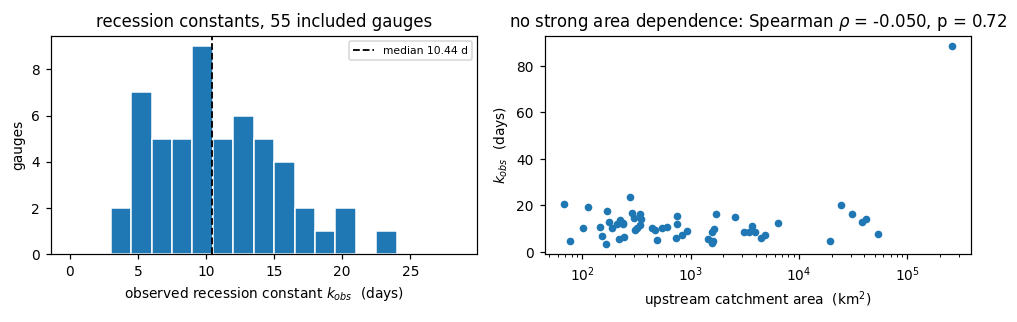

In [8]:
INC = BFI[BFI['included']].copy()
EXC = BFI[~BFI['included']].copy()
print(f'gauges: {len(BFI)} measured, {len(INC)} included, {len(EXC)} excluded by the '
      f'>= {MIN_SCORED_DAYS} scored-day rule')
print('excluded: ' + ', '.join(f'{g}' for g in EXC['gauge']))
print(f'   their scored days: {EXC["n_scored"].min():.0f} .. {EXC["n_scored"].max():.0f}')
print(f'included scored days: {INC["n_scored"].min():.0f} .. {INC["n_scored"].max():.0f} '
      f'(median {INC["n_scored"].median():.0f})')
print(f'k_obs (d): median {INC["k_obs_d"].median():.3f}, p10 {INC["k_obs_d"].quantile(.1):.3f}, '
      f'p90 {INC["k_obs_d"].quantile(.9):.3f}  ->  a median {INC["a"].median():.4f}')
print(f'json: k_obs median {BSUM["k_obs"]["med"]:.3f} d, a median {BSUM["k_obs"]["med_a"]:.4f} '
      f'(agrees)')

fig, ax = plt.subplots(1, 2, figsize=(9.0, 3.0))
ax[0].hist(INC['k_obs_d'], bins=np.arange(0, 30, 1.5), color='tab:blue', edgecolor='w')
ax[0].axvline(INC['k_obs_d'].median(), color='k', ls='--', lw=1.2,
              label=f'median {INC["k_obs_d"].median():.2f} d')
ax[0].set_xlabel('observed recession constant $k_{obs}$  (days)')
ax[0].set_ylabel('gauges'); ax[0].legend(fontsize=7)
ax[0].set_title(f'recession constants, {len(INC)} included gauges')
ax[1].semilogx(INC['area_km2'], INC['k_obs_d'], 'o', ms=4, color='tab:blue')
ax[1].set_xlabel('upstream catchment area  (km$^2$)')
ax[1].set_ylabel('$k_{obs}$  (days)')
rho, pv = stats.spearmanr(np.log10(INC['area_km2']), INC['k_obs_d'])
ax[1].set_title(f'no strong area dependence: Spearman $\\rho$ = {rho:+.3f}, p = {pv:.2f}')
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the distribution of the observed recession constant
$k_{\text{obs}}$ in days over the 55 included gauges, with the median as a dashed line. *Right:*
the same constants against upstream catchment area on a logarithmic axis (km$^2$), with the
Spearman rank correlation in the title.

**What it shows.** The median recession constant is **10.44 d** (p10 5.34, p90 17.24), giving a
median $a$ of **0.9087** - the fleet's rivers lose about 9 % of their baseflow per day when
draining. Both figures agree with the committed summary. Eight gauges of the 63 are excluded for
having fewer than 1,095 scored days (703-1,032 days each); **none** was excluded for want of a
recession constant. Against area there is no relationship at all: $\rho = -0.050$, p = 0.72.

**What it means.** The yardstick is well determined and it is not an artefact of catchment size -
a 68 km$^2$ headwater and a 257,000 km$^2$ mainstem drain at statistically indistinguishable
rates - so the filter is applied with a defensible, catchment-specific $a$ at every gauge rather
than a basin-wide guess. It also puts the model's fitted deep-store constant in context: the
adopted parameter set carries $k_{\text{bas}} = 43.0$ d, **4.1x** the observed 10.44 d recession
constant, which is the kind of mismatch the Phase B recession term was added to control.

## 3.4 - The filter on one real gauge

Before any fleet statistic, the estimator is shown doing its job on one hydrograph, so that a
reader can see what "quickflow" and "baseflow" mean on a real river rather than in a definition.
Gauge **21147030** was chosen for three stated reasons: a long record (3,480 scored days), a
mid-size catchment (1,600 km$^2$, i.e. neither a flashy headwater nor the aggregated mainstem),
and a BFI difference close to the fleet median, so it is representative rather than flattering.
The alternative - showing the worst gauge - was rejected as unrepresentative; the worst gauges are
named in §4.2 instead.

The cell applies `baseflow.bfi_series` to the observed and simulated series with the **same** $a$
and the **same** day mask, and reports both baseflow indices. Inputs: two columns of
`q_gauge_H2E.npz` (m$^3$ s$^{-1}$) and the gauge's $a$ (dimensionless). Outputs: two hydrographs
plus their baseflow components (m$^3$ s$^{-1}$) and two dimensionless indices.

gauge 21147030  area 1,600 km2  k_obs 4.629 d  a 0.8057
scored days 3480 (segment days 3600, 120 discarded as filter warm-up)
BFI observed  0.7875   quickflow share 0.2125
BFI simulated 0.7995   quickflow share 0.2005
difference    +0.0120   (committed table: +0.0120)


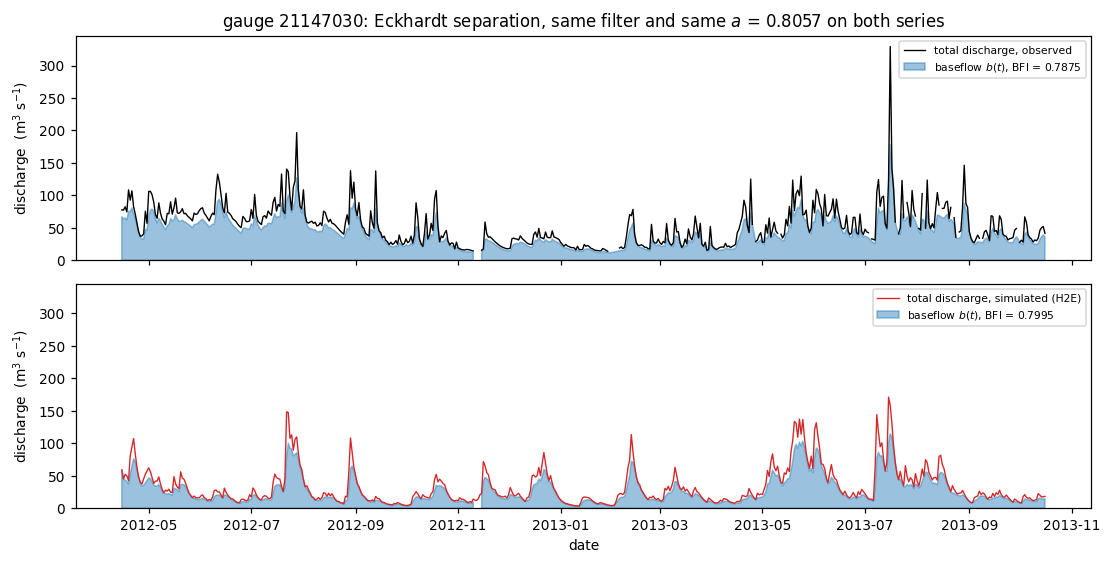

In [9]:
ro = BF.bfi_series(QOBS[:, jx], QVALID[:, jx], a_ex, BFIMAX)
rs = BF.bfi_series(QSIM[:, jx], QVALID[:, jx], a_ex, BFIMAX)
assert np.array_equal(ro['scored'], rs['scored']), 'the two series must be scored on one day set'
print(f'gauge {GEX}  area {AREA[jx]:,.0f} km2  k_obs {row_ex["k_obs_d"]:.3f} d  a {a_ex:.4f}')
print(f'scored days {ro["n_scored"]} (segment days {ro["seg_days"]}, '
      f'{ro["seg_days"]-ro["n_scored"]} discarded as filter warm-up)')
print(f'BFI observed  {ro["bfi"]:.4f}   quickflow share {1-ro["bfi"]:.4f}')
print(f'BFI simulated {rs["bfi"]:.4f}   quickflow share {1-rs["bfi"]:.4f}')
print(f'difference    {rs["bfi"]-ro["bfi"]:+.4f}   (committed table: '
      f'{float(row_ex["diff"]):+.4f})')

fig, ax = plt.subplots(2, 1, figsize=(10.2, 5.2), sharex=True)
tt = DATES
w0, w1 = 1200, 1750
sl = slice(w0, w1)
for k, (q, r, nm, col) in enumerate([(QOBS[:, jx], ro, 'observed', 'k'),
                                     (QSIM[:, jx], rs, 'simulated (H2E)', 'tab:red')]):
    ax[k].plot(tt[sl], q[sl], color=col, lw=0.9, label=f'total discharge, {nm}')
    ax[k].fill_between(tt[sl], 0, r['b'][sl], color='tab:blue', alpha=0.45,
                       label=f'baseflow $b(t)$, BFI = {r["bfi"]:.4f}')
    ax[k].set_ylabel('discharge  (m$^3$ s$^{-1}$)')
    ax[k].legend(fontsize=7, loc='upper right')
    ax[k].set_ylim(0, np.nanmax(QOBS[sl, jx]) * 1.05)
ax[0].set_title(f'gauge {GEX}: Eckhardt separation, same filter and same $a$ = {a_ex:.4f} '
                f'on both series')
ax[1].set_xlabel('date')
plt.tight_layout(); plt.show()

**What is plotted.** Two stacked panels covering the same ~550-day window, both in
m$^3$ s$^{-1}$: the observed hydrograph (top, black line) and the simulated one (bottom, red
line), each with its Eckhardt baseflow component shaded blue underneath. The white space between
the line and the shading is quickflow - the erosive water. Both panels share the y-axis scale so
the two can be compared by eye.

**What it shows.** The filter behaves as intended: the blue shading tracks the slow envelope of
the hydrograph and stops short of the storm peaks, which stand clear of it. At this gauge the
observed BFI is **0.7875** (quickflow share 0.2125) and the simulated BFI is **0.7995**
(quickflow share 0.2005), a difference of **+0.0120**, reproducing the committed table exactly.
Visually, the simulated peaks are visibly smaller than the observed ones over the same window,
while the slow envelope is if anything slightly higher.

**What it means.** The two series are being compared on identical terms - same filter, same
recession constant, same days - so the difference is attributable to the hydrographs and not to
the method. And the eye already sees the two results this notebook goes on to quantify: the
partition difference is **small** (0.012 of an index that runs 0 to 1), while the *peaks* are
plainly deficient. That ordering - partition nearly right, peaks wrong - is the C2b verdict in one
picture.

## 3.5 - How much can this test see? Sweeping the fixed knob

$\mathrm{BFI_{max}}$ is fixed at 0.80 and the verdict is computed there. But a fixed knob invites
one question that must be answered *after* the verdict, never before: **how much of the answer is
the knob?** This cell recomputes the entire fleet comparison at eight values of
$\mathrm{BFI_{max}}$ from 0.30 to 0.95, and reports the gate statistic and the gate itself at each:

$$\text{gate ratio}(\mathrm{BFI_{max}}) = \frac{\operatorname{median}_g \bigl| \mathrm{BFI}^{\text{sim}}_g -
\mathrm{BFI}^{\text{obs}}_g \bigr|}{\mathrm{IQR}_g\bigl(\mathrm{BFI}^{\text{obs}}\bigr)}$$

Refutation is ratio $> 1$. Inputs: both discharge columns for all 55 included gauges
(m$^3$ s$^{-1}$) and their recession constants; 880 filter passes, a few seconds. Everything
dimensionless. **This is reported, and by §2's rule it cannot change the verdict** - which is
computed at 0.80 and only at 0.80.

   bfimax   med_obs   med_sim   med_abs       iqr     ratio
  0.30000   0.30000   0.30034   0.00085   0.00148   0.57115
  0.40000   0.39908   0.40009   0.00148   0.00325   0.45349
  0.50000   0.49757   0.49973   0.00308   0.00487   0.63279
  0.60000   0.59506   0.59938   0.00620   0.01097   0.56491
  0.70000   0.68929   0.69867   0.01091   0.02011   0.54237
  0.80000   0.78109   0.79652   0.01625   0.02845   0.57122
  0.90000   0.87687   0.89470   0.01906   0.02564   0.74311
  0.95000   0.93043   0.94597   0.01593   0.02186   0.72839

refuted at any swept value? False
median BFI_obs vs BFImax: slope of a straight-line fit = 0.9621


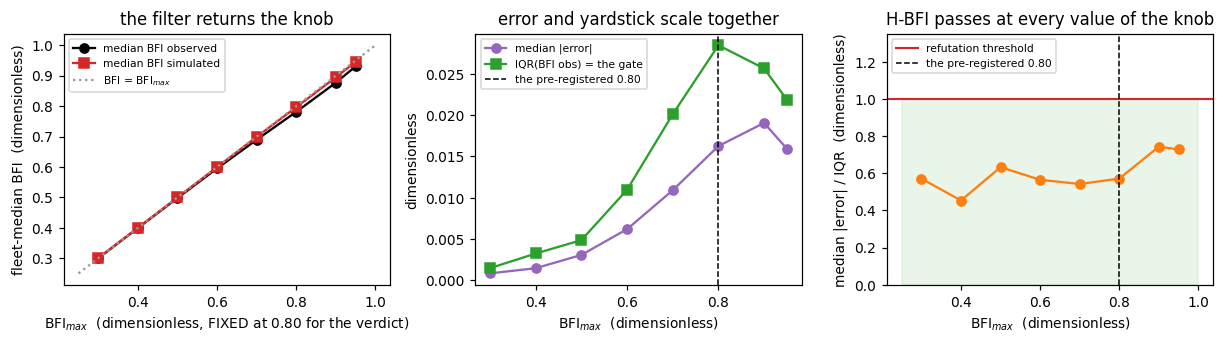

In [10]:
jj = np.array([int(np.flatnonzero(GC == g)[0]) for g in INC['gauge']])
aa = INC['a'].to_numpy()
SWEEP = []
for Bm in (0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95):
    o = np.array([BF.bfi_series(QOBS[:, j], QVALID[:, j], a, Bm)['bfi']
                  for j, a in zip(jj, aa)])
    s = np.array([BF.bfi_series(QSIM[:, j], QVALID[:, j], a, Bm)['bfi']
                  for j, a in zip(jj, aa)])
    iqr = np.percentile(o, 75) - np.percentile(o, 25)
    SWEEP.append(dict(bfimax=Bm, med_obs=np.median(o), med_sim=np.median(s),
                      med_abs=np.median(np.abs(s - o)), iqr=iqr,
                      ratio=np.median(np.abs(s - o)) / iqr))
SW = pd.DataFrame(SWEEP)
print(SW.to_string(index=False, float_format=lambda v: f'{v:9.5f}'))
print(f'\nrefuted at any swept value? {bool((SW["ratio"] > 1).any())}')
print(f'median BFI_obs vs BFImax: slope of a straight-line fit = '
      f'{np.polyfit(SW["bfimax"], SW["med_obs"], 1)[0]:.4f}')

fig, ax = plt.subplots(1, 3, figsize=(11.2, 3.2))
ax[0].plot(SW['bfimax'], SW['med_obs'], 'o-', color='k', label='median BFI observed')
ax[0].plot(SW['bfimax'], SW['med_sim'], 's-', color='tab:red', label='median BFI simulated')
ax[0].plot([0.25, 1.0], [0.25, 1.0], ':', color='0.6', label='BFI = BFI$_{max}$')
ax[0].set_xlabel('BFI$_{max}$  (dimensionless, FIXED at 0.80 for the verdict)')
ax[0].set_ylabel('fleet-median BFI  (dimensionless)')
ax[0].legend(fontsize=7); ax[0].set_title('the filter returns the knob')
ax[1].plot(SW['bfimax'], SW['med_abs'], 'o-', color='tab:purple', label='median |error|')
ax[1].plot(SW['bfimax'], SW['iqr'], 's-', color='tab:green', label='IQR(BFI obs) = the gate')
ax[1].axvline(BFIMAX, color='k', ls='--', lw=1.0, label='the pre-registered 0.80')
ax[1].set_xlabel('BFI$_{max}$  (dimensionless)')
ax[1].set_ylabel('dimensionless')
ax[1].legend(fontsize=7); ax[1].set_title('error and yardstick scale together')
ax[2].plot(SW['bfimax'], SW['ratio'], 'o-', color='tab:orange')
ax[2].axhline(1.0, color='tab:red', lw=1.4, label='refutation threshold')
ax[2].axvline(BFIMAX, color='k', ls='--', lw=1.0, label='the pre-registered 0.80')
ax[2].fill_between([0.25, 1.0], 0, 1, color='tab:green', alpha=0.10)
ax[2].set_xlabel('BFI$_{max}$  (dimensionless)')
ax[2].set_ylabel('median |error| / IQR  (dimensionless)')
ax[2].set_ylim(0, 1.35); ax[2].legend(fontsize=7)
ax[2].set_title('H-BFI passes at every value of the knob')
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the fleet-median baseflow index of the observed (black) and
simulated (red) hydrographs as a function of $\mathrm{BFI_{max}}$, with the dotted grey 1:1 line
$\mathrm{BFI} = \mathrm{BFI_{max}}$. *Middle:* the gate statistic (median absolute error, purple)
and the gate itself (the interquartile range of observed BFI, green) against the same knob, with
the pre-registered 0.80 marked. *Right:* their ratio, refutation being anything above the red line
at 1.0; the green shading is the passing region. All axes dimensionless.

**What it shows.** The left panel is the finding: the fleet-median observed BFI tracks
$\mathrm{BFI_{max}}$ almost exactly - 0.3000 at 0.30, 0.4976 at 0.50, 0.7811 at 0.80, 0.9304 at
0.95, a straight-line slope of **0.962**. The middle panel shows the error and the yardstick
growing together, and the right panel shows the ratio confined to **0.453-0.743** across the whole
sweep: **H-BFI passes at every value of the knob, and is never within 25 % of refutation at any of
them.**

**What it means.** Two conclusions, one reassuring and one deflating. Reassuring: the verdict is
not an artefact of choosing 0.80 - no available choice of the knob would have refuted H-BFI, so
nobody can argue the test was rigged by its constant. Deflating: a statistic whose fleet median is
essentially the constant you handed it has very little room left to carry information about the
model. This **extends** `docs/33` §6.5, which noted the compression against 0.80 and observed that
the 0.50 robustness column gave the same pass; the sweep shows the invariance holds across eight
values with slope ~1, so "lower the ceiling" is measurably *not* the fix for the test's weakness.
§4.6 states what would be.

---

# 4 - H-BFI: not refuted, and why that is weaker than it sounds

## 4.1 - The verdict, against the rule exactly as written

$$\text{refuted} \iff \underbrace{\operatorname{median}_g\bigl|\mathrm{BFI}^{\text{sim}}_g -
\mathrm{BFI}^{\text{obs}}_g\bigr|}_{\text{the statistic}} \;>\;
\underbrace{p_{75}\bigl(\mathrm{BFI}^{\text{obs}}\bigr) - p_{25}\bigl(\mathrm{BFI}^{\text{obs}}\bigr)}_{\text{the gate}}$$

over the $g = 55$ included gauges, both sides dimensionless. The cell recomputes both sides from
the committed per-gauge table `c2b/bfi_per_gauge.csv` and cross-checks them against the values
stored in `c2b/bfi_summary.json`, so that a transcription error between the measurement run and
this notebook would show up as a printed disagreement rather than as agreement by assumption. The
standard deviation is printed alongside because `docs/33` §1 requires it as context and states
that it **cannot** change the verdict.

quantity                                      recomputed   bfi_summary.json
fleet-median BFI observed                       0.781087           0.781087   ok
fleet-median BFI simulated                      0.796518           0.796518   ok
THE STATISTIC  median |BFI_sim - BFI_obs|       0.016251           0.016251   ok
THE GATE       IQR(BFI_obs)                     0.028450           0.028450   ok
p10-p90 of BFI_obs (context)                    0.067273           0.067273   ok
SD of BFI_obs (context only, cannot gate)       0.030688           0.030688   ok
fleet-median signed difference                  0.012798           0.012798   ok
BFImax = 0.50 statistic                         0.003083           0.003083   ok
BFImax = 0.50 gate                              0.004872           0.004872   ok

n = 55 gauges;  0.01625 <= 0.02845  ->  H-BFI is NOT REFUTED
headroom: the statistic is 0.571 of the gate
robustness at BFImax = 0.50: 0.00308 vs 0.00487 -> NOT REFUTED  (verdict does not flip)


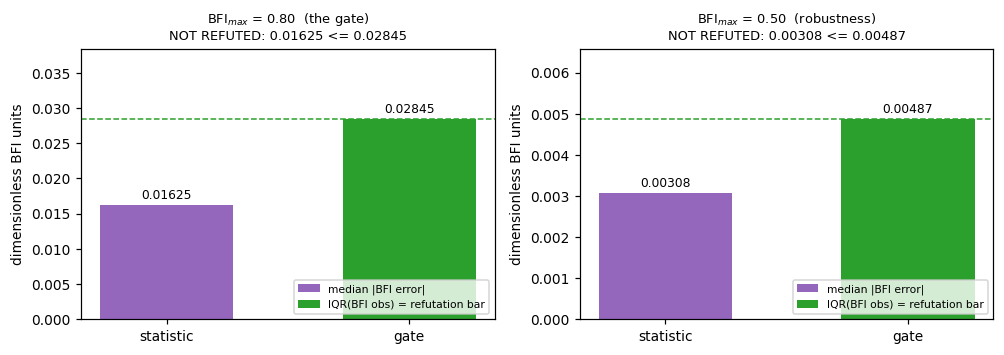

In [11]:
o = INC['bfi_obs'].to_numpy(); s = INC['bfi_sim'].to_numpy(); d = INC['diff'].to_numpy()
iqr = np.percentile(o, 75) - np.percentile(o, 25)
stat = np.median(np.abs(d))
o5, d5 = INC['bfi_obs_b50'].to_numpy(), INC['diff_b50'].to_numpy()
iqr5, stat5 = np.percentile(o5, 75) - np.percentile(o5, 25), np.median(np.abs(d5))

print(f'{"quantity":<44}{"recomputed":>12}{"bfi_summary.json":>19}')
for nm, mine, theirs in [
        ('fleet-median BFI observed', np.median(o), BSUM['b080']['med_bfi_obs']),
        ('fleet-median BFI simulated', np.median(s), BSUM['b080']['med_bfi_sim']),
        ('THE STATISTIC  median |BFI_sim - BFI_obs|', stat, BSUM['b080']['med_abs_diff']),
        ('THE GATE       IQR(BFI_obs)', iqr, BSUM['b080']['iqr_obs']),
        ('p10-p90 of BFI_obs (context)', np.percentile(o, 90) - np.percentile(o, 10),
         BSUM['b080']['p10_90_obs']),
        ('SD of BFI_obs (context only, cannot gate)', o.std(ddof=1), BSUM['b080']['sd_obs']),
        ('fleet-median signed difference', np.median(d), BSUM['b080']['med_signed_diff']),
        ('BFImax = 0.50 statistic', stat5, BSUM['b050']['med_abs_diff']),
        ('BFImax = 0.50 gate', iqr5, BSUM['b050']['iqr_obs'])]:
    flag = 'ok' if abs(mine - theirs) < 1e-9 else 'DISAGREES'
    print(f'{nm:<44}{mine:12.6f}{theirs:19.6f}   {flag}')

print(f'\nn = {len(INC)} gauges;  {stat:.5f} {"<=" if stat <= iqr else ">"} {iqr:.5f}  ->  '
      f'H-BFI is {"NOT REFUTED" if stat <= iqr else "REFUTED"}')
print(f'headroom: the statistic is {stat/iqr:.3f} of the gate')
print(f'robustness at BFImax = 0.50: {stat5:.5f} vs {iqr5:.5f} -> '
      f'{"NOT REFUTED" if stat5 <= iqr5 else "REFUTED"}  (verdict does not flip)')
print(f'\nper gauge: {int((d>0).sum())} of {len(d)} have BFI_sim > BFI_obs, {int((d<0).sum())} '
      f'the other way')
print(f'           {int((np.abs(d)>iqr).sum())} of {len(d)} individually exceed the fleet IQR')
print(f'           {int((np.abs(d)>0.20).sum())} of {len(d)} exceed 0.20, the error at which the '
      f'refit BFI term would score zero')
print(f'           largest |difference| {np.abs(d).max():.4f} at gauge '
      f'{INC["gauge"].to_numpy()[np.argmax(np.abs(d))]}')

fig, ax = plt.subplots(1, 2, figsize=(9.2, 3.3))
for k, (st, ga, tag) in enumerate([(stat, iqr, f'BFI$_{{max}}$ = {BFIMAX:.2f}  (the gate)'),
                                   (stat5, iqr5, f'BFI$_{{max}}$ = {BFIMAX_ROBUST:.2f}  '
                                                 f'(robustness)')]):
    ax[k].bar([0], [st], color='tab:purple', width=0.55, label='median |BFI error|')
    ax[k].bar([1], [ga], color='tab:green', width=0.55, label='IQR(BFI obs) = refutation bar')
    ax[k].axhline(ga, color='tab:green', ls='--', lw=1.0)
    ax[k].text(0, st + ga * 0.03, f'{st:.5f}', ha='center', fontsize=8)
    ax[k].text(1, ga + ga * 0.03, f'{ga:.5f}', ha='center', fontsize=8)
    ax[k].set_xticks([0, 1]); ax[k].set_xticklabels(['statistic', 'gate'])
    ax[k].set_ylabel('dimensionless BFI units')
    ax[k].set_ylim(0, ga * 1.35)
    ax[k].set_title(f'{tag}\nNOT REFUTED: {st:.5f} <= {ga:.5f}', fontsize=8.5)
    ax[k].legend(fontsize=7, loc='lower right')
plt.tight_layout(); plt.show()

**What is plotted.** Two panels, each with two bars in dimensionless BFI units: the purple bar is
the gate statistic (the fleet-median absolute BFI error) and the green bar with its dashed line is
the refutation bar (the interquartile range of observed BFI across gauges). Left panel is the
pre-registered $\mathrm{BFI_{max}} = 0.80$; right is the 0.50 robustness column, which by rule
cannot change the verdict.

**What it shows.** At 0.80 the statistic is **0.01625** against a gate of **0.02845**, i.e. 0.571
of the bar - **H-BFI is NOT REFUTED**. Every recomputed number matches
`bfi_summary.json` to $<10^{-9}$. At 0.50 the statistic is **0.00308** against **0.00487**: the
same verdict, so the instability clause the pre-registration wrote for a verdict-flip is not
triggered. The signed difference is **+0.0128**, and **48 of 55** gauges have BFI simulated above
BFI observed - the simulated hydrograph is the *slower* one almost everywhere. 23 of 55 gauges
individually exceed the fleet IQR, but **0 of 55** exceed 0.20.

**What it means.** By the rule that was frozen, the model's routed flow character is not
distinguishable from the rivers' at fleet scale, and the failure is one-sided: where the model is
wrong it is too slow, never too fast. That last point matters for sediment in a specific
direction - a hydrograph that is too slow delivers too little of its water as quickflow, so the
error, such as it is, biases MUSLE's $Q_{\text{sur}}$ **downward**, consistent with the peak
deficit rather than compensating for it. What this result does *not* establish is anything about
whether the model resolves flow character catchment by catchment: §4.6 is the necessary companion
to this verdict, and it is not optional reading.

## 4.2 - Gauge by gauge: does the model know which catchment is flashy?

A fleet median can hide anything. The pre-registration therefore requires a full per-gauge table,
and the natural test of *information content* is whether the simulated index tracks the observed
one across gauges:

$$r_{\text{cross}} = \mathrm{corr}_g\bigl(\mathrm{BFI}^{\text{sim}}_g,\; \mathrm{BFI}^{\text{obs}}_g\bigr)$$

a dimensionless Pearson correlation over the 55 gauges - **not** a correlation in time. If
$r_{\text{cross}} \approx 0$ the model carries no between-catchment information about flow
character even if its fleet median is right. Inputs: the `bfi_obs` and `bfi_sim` columns of the
committed table.

r(BFI_sim, BFI_obs) across gauges = +0.0940
r(difference, BFI_obs)            = -0.8252
observed BFI spans 0.6581 .. 0.7986   (12 of 55 gauges above 0.79)
simulated BFI spans 0.7011 .. 0.8038
observed SD 0.0307 vs simulated SD 0.0198 (ratio 0.646)

largest absolute differences:
   gauge  area_km2   bfi_obs   bfi_sim      diff
21237040  243.2500    0.6732    0.7905    0.1173
21167090  345.0300    0.6581    0.7708    0.1127
24017610  298.2200    0.6964    0.7990    0.1025
26167060  178.5000    0.7126    0.7983    0.0857


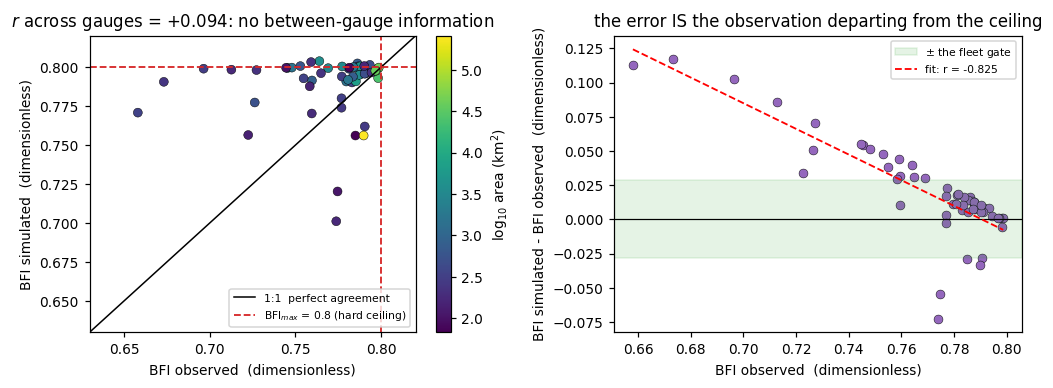

In [12]:
r_cross = np.corrcoef(s, o)[0, 1]
r_diff_obs = np.corrcoef(d, o)[0, 1]
print(f'r(BFI_sim, BFI_obs) across gauges = {r_cross:+.4f}')
print(f'r(difference, BFI_obs)            = {r_diff_obs:+.4f}')
print(f'observed BFI spans {o.min():.4f} .. {o.max():.4f}   '
      f'({int((o > 0.79).sum())} of {len(o)} gauges above 0.79)')
print(f'simulated BFI spans {s.min():.4f} .. {s.max():.4f}')
print(f'observed SD {o.std(ddof=1):.4f} vs simulated SD {s.std(ddof=1):.4f} '
      f'(ratio {s.std(ddof=1)/o.std(ddof=1):.3f})')
worst = INC.reindex(INC['diff'].abs().sort_values(ascending=False).index).head(4)
print('\nlargest absolute differences:')
print(worst[['gauge', 'area_km2', 'bfi_obs', 'bfi_sim', 'diff']]
      .to_string(index=False, float_format=lambda v: f'{v:9.4f}'))

fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.6))
sc = ax[0].scatter(o, s, c=np.log10(INC['area_km2']), cmap='viridis', s=34,
                   edgecolor='k', linewidth=0.3)
lim = (0.63, 0.82)
ax[0].plot(lim, lim, 'k-', lw=1.0, label='1:1  perfect agreement')
ax[0].axhline(BFIMAX, color='tab:red', ls='--', lw=1.2,
              label=f'BFI$_{{max}}$ = {BFIMAX} (hard ceiling)')
ax[0].axvline(BFIMAX, color='tab:red', ls='--', lw=1.2)
ax[0].set_xlim(*lim); ax[0].set_ylim(*lim)
ax[0].set_xlabel('BFI observed  (dimensionless)')
ax[0].set_ylabel('BFI simulated  (dimensionless)')
ax[0].set_title(f'$r$ across gauges = {r_cross:+.3f}: no between-gauge information')
ax[0].legend(fontsize=7, loc='lower right')
plt.colorbar(sc, ax=ax[0], label='log$_{10}$ area (km$^2$)')

ax[1].scatter(o, d, s=34, color='tab:purple', edgecolor='k', linewidth=0.3)
ax[1].axhline(0, color='k', lw=0.8)
ax[1].axhspan(-iqr, iqr, color='tab:green', alpha=0.12, label='$\\pm$ the fleet gate')
xs = np.linspace(o.min(), o.max(), 10)
pf = np.polyfit(o, d, 1)
ax[1].plot(xs, np.polyval(pf, xs), 'r--', lw=1.2,
           label=f'fit: r = {r_diff_obs:+.3f}')
ax[1].set_xlabel('BFI observed  (dimensionless)')
ax[1].set_ylabel('BFI simulated - BFI observed  (dimensionless)')
ax[1].set_title('the error IS the observation departing from the ceiling')
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* simulated against observed baseflow index, one point per gauge,
coloured by log$_{10}$ catchment area; the solid line is 1:1 and the dashed red lines mark the
filter's hard ceiling at $\mathrm{BFI_{max}} = 0.80$. *Right:* the difference (simulated minus
observed) against the observed value, with the fleet gate as a green band and a least-squares line.
All quantities dimensionless.

**What it shows.** The left panel is a horizontal band, not a diagonal: **$r_{\text{cross}} =
+0.094$**. Simulated BFI spans only 0.7011-0.8038 - clamped hard against the 0.80 ceiling - while
observed BFI spans 0.6581-0.7986, with 12 of 55 gauges above 0.79. The simulated standard
deviation is 0.0198 against the observed 0.0307, a ratio of 0.646. The right panel is a clean
negative line, **$r(\text{difference}, \mathrm{BFI_{obs}}) = -0.825$**. The four largest errors are
all small catchments: 21237040 (243 km$^2$, +0.117), 21167090 (345 km$^2$, +0.113), 24017610
(298 km$^2$, +0.103), 26167060 (178 km$^2$, +0.086).

**What it means.** This is the honest core of the H-BFI result and it is not what a "pass" sounds
like. The model does **not** track which catchment is flashy: its BFI is nearly constant across
the fleet, pinned near the filter's ceiling, and the entire structure of the error is "the
observation departs from the ceiling and the simulation does not follow". The test passed because
both distributions sit near 0.80, not because the model resolves flow character. Anyone quoting
"BFI validated" as "flow character validated" is over-reading it by a wide margin - and §4.6 says
so in the terms a reader should carry away.

## 4.3 - Where the error lives: small, flashy catchments

The per-gauge picture above suggests the error is a small-catchment error. This cell tests that
directly by splitting the fleet into area **quartiles** (four equal-count groups ordered by
upstream area, km$^2$) and reporting the median absolute BFI error in each, plus the correlation
of the signed error with log area:

$$r_{\text{area}} = \mathrm{corr}_g\bigl(\mathrm{BFI}^{\text{sim}}_g - \mathrm{BFI}^{\text{obs}}_g,\;
\log_{10} A_g\bigr)$$

with $A_g$ the gauge's upstream area (km$^2$) as carried by the model's own topology, not by the
national catalogue - `docs/23` §13.2 shows the two disagree by more than 2x on 36 % of shared
gauges. No per-area yield is computed, so the embargo is untouched.

area quartile 1:        68 -       236 km2, n = 14, median |error| = 0.0317
area quartile 2:       236 -       544 km2, n = 13, median |error| = 0.0179
area quartile 3:       544 -     2,868 km2, n = 14, median |error| = 0.0153
area quartile 4:     2,868 -   257,097 km2, n = 14, median |error| = 0.0081

r(difference, log10 area) = -0.2101   (bfi_summary.json: -0.2101)
median-split figures from the summary file: small 0.0289, large 0.0128


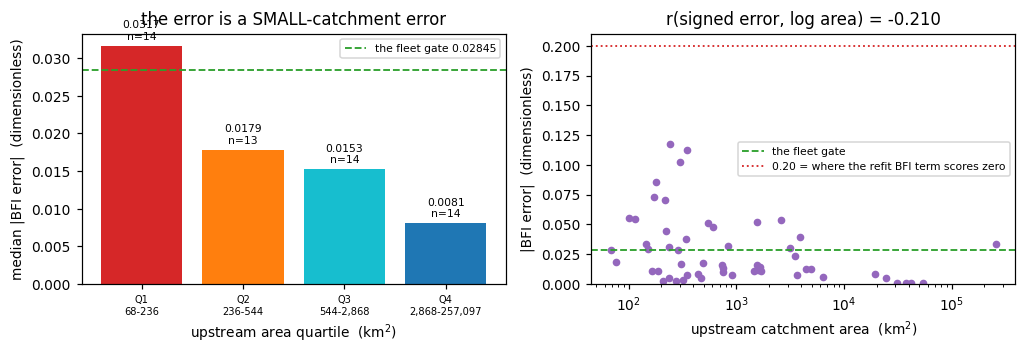

In [13]:
la = np.log10(INC['area_km2'].to_numpy())
r_area = np.corrcoef(d, la)[0, 1]
qa = np.quantile(INC['area_km2'], [0, .25, .5, .75, 1])
labels, meds, ns = [], [], []
for k in range(4):
    m = ((INC['area_km2'] >= qa[k]) & (INC['area_km2'] <= qa[k + 1])) if k == 3 else \
        ((INC['area_km2'] >= qa[k]) & (INC['area_km2'] < qa[k + 1]))
    mv = m.to_numpy()
    labels.append(f'Q{k+1}\n{qa[k]:,.0f}-{qa[k+1]:,.0f}')
    meds.append(float(np.median(np.abs(d[mv]))))
    ns.append(int(mv.sum()))
    print(f'area quartile {k+1}: {qa[k]:9,.0f} - {qa[k+1]:9,.0f} km2, n = {mv.sum():2d}, '
          f'median |error| = {meds[-1]:.4f}')
print(f'\nr(difference, log10 area) = {r_area:+.4f}   '
      f'(bfi_summary.json: {BSUM["area"]["r_diff_logarea"]:+.4f})')
print(f'median-split figures from the summary file: small {BSUM["area"]["med_abs_diff_small"]:.4f}'
      f', large {BSUM["area"]["med_abs_diff_large"]:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.3))
ax[0].bar(range(4), meds, color=['tab:red', 'tab:orange', 'tab:cyan', 'tab:blue'])
ax[0].axhline(iqr, color='tab:green', ls='--', lw=1.2, label='the fleet gate 0.02845')
for k, (v, n) in enumerate(zip(meds, ns)):
    ax[0].text(k, v + 0.0008, f'{v:.4f}\nn={n}', ha='center', fontsize=7)
ax[0].set_xticks(range(4)); ax[0].set_xticklabels(labels, fontsize=6.5)
ax[0].set_ylabel('median |BFI error|  (dimensionless)')
ax[0].set_xlabel('upstream area quartile  (km$^2$)')
ax[0].set_title('the error is a SMALL-catchment error')
ax[0].legend(fontsize=7)
ax[1].semilogx(INC['area_km2'], np.abs(d), 'o', ms=4, color='tab:purple')
ax[1].axhline(iqr, color='tab:green', ls='--', lw=1.2, label='the fleet gate')
ax[1].axhline(0.20, color='tab:red', ls=':', lw=1.2,
              label='0.20 = where the refit BFI term scores zero')
ax[1].set_xlabel('upstream catchment area  (km$^2$)')
ax[1].set_ylabel('|BFI error|  (dimensionless)')
ax[1].set_ylim(0, 0.21)
ax[1].set_title(f'r(signed error, log area) = {r_area:+.3f}')
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the median absolute BFI error in each of four equal-count area
quartiles, with the fleet gate as a dashed green line; the quartile's area range and gauge count
are printed on each bar. *Right:* the absolute error per gauge against upstream area on a log
axis, with the fleet gate (green dashed) and the 0.20 level at which the refit's BFI term would
score zero (red dotted). Errors dimensionless, areas km$^2$.

**What it shows.** The gradient is monotone and large: median absolute error **0.0317** in the
smallest quartile (68-236 km$^2$), 0.0179, 0.0153, and **0.0081** in the largest
(2,868-257,097 km$^2$) - a factor of 3.9 across the fleet - with
$r(\text{error}, \log_{10} A) = -0.210$. The smallest quartile's median error **exceeds the fleet
gate**. No gauge at any size comes within half of the 0.20 level.

**What it means.** The fleet-median pass is carried by the big rivers, where aggregation makes any
two hydrographs look alike, and the model is measurably too smooth exactly where flow character
is most distinct - the small, flashy headwaters. For sediment this is the wrong place to be wrong:
steep headwater catchments are where erosion is generated, so the region in which the routed flow
character is least trustworthy is also the region contributing most of MUSLE's source term. It
does not change the verdict - the gate is a fleet statistic and the fleet passed - but it is the
second reason (after §4.2) why this pass carries a caveat rather than a licence.

## 4.4 - By period, including the one window that crosses its own bar

The pre-registration fixes **every gate on the full 2009-2018 record**, precisely so that a verdict
cannot be extracted from a favourable - or an unfavourable - sub-window. Sub-periods are
nevertheless reported, because the project's deliverable is an ENSO contrast and the dry phase is
where everything else in this model fails. For each period the same ratio-of-sums is taken over
that window's days without re-running the filter (re-running it would need a fresh 30-day warm-up
inside each window and would therefore be a *different* estimator from the frozen one):

$$\mathrm{BFI}\big|_{\text{period}} = \frac{\sum_{t \in \text{period}} b(t)}{\sum_{t \in \text{period}} y(t)}$$

Inputs: the per-period columns of `c2b/bfi_per_gauge.csv`. All dimensionless.

            period  n  med_days   med_obs   med_sim  statistic      gate    signed  crosses
       CAL 2012-14 54  974.0000    0.7803    0.7981     0.0186    0.0281    0.0134    False
           VAL all 55 2040.0000    0.7807    0.7960     0.0154    0.0286    0.0128    False
    VAL La Nina 11 52  365.0000    0.7807    0.7962     0.0183    0.0358    0.0135    False
 VAL El Nino 15-16 50  606.0000    0.7698    0.7918     0.0295    0.0290    0.0255     True
VAL other 09/10/17 55  904.0000    0.7792    0.7965     0.0191    0.0262    0.0144    False
          VAL 2018 46  331.0000    0.7800    0.7990     0.0157    0.0336    0.0139    False

every period statistic reproduces bfi_summary.json to < 1e-9
periods whose statistic exceeds their own IQR: ['VAL El Nino 15-16']


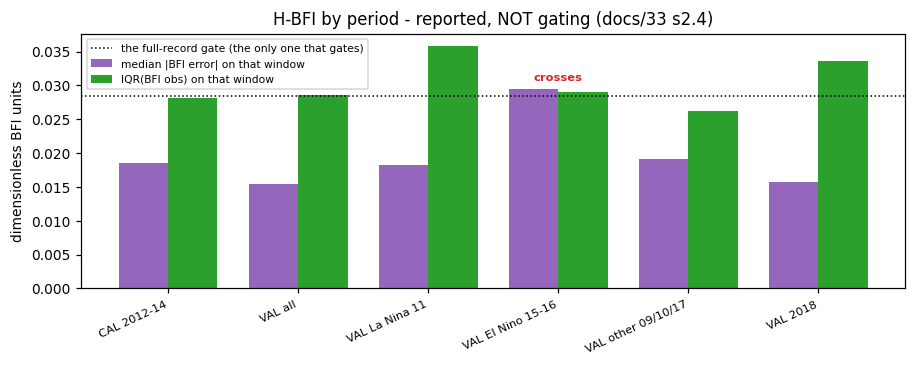

In [14]:
PER = ['CAL 2012-14', 'VAL all', 'VAL La Nina 11', 'VAL El Nino 15-16',
       'VAL other 09/10/17', 'VAL 2018']
rows = []
for p in PER:
    oo = INC[f'bfi_obs|{p}'].to_numpy(float)
    ss = INC[f'bfi_sim|{p}'].to_numpy(float)
    dd = ss - oo
    ok = np.isfinite(dd)
    st_p = np.nanmedian(np.abs(dd))
    ga_p = np.nanpercentile(oo, 75) - np.nanpercentile(oo, 25)
    rows.append(dict(period=p, n=int(ok.sum()),
                     med_days=float(np.nanmedian(INC[f'ndays|{p}'])),
                     med_obs=np.nanmedian(oo), med_sim=np.nanmedian(ss),
                     statistic=st_p, gate=ga_p, signed=np.nanmedian(dd),
                     crosses=bool(st_p > ga_p)))
PB = pd.DataFrame(rows)
print(PB.to_string(index=False, float_format=lambda v: f'{v:9.4f}'))
for p in PER:
    j_ = PB[PB['period'] == p].index[0]
    ref = BSUM['by_period'][p]
    assert abs(PB.loc[j_, 'statistic'] - ref['med_abs_diff']) < 1e-9, p
print('\nevery period statistic reproduces bfi_summary.json to < 1e-9')
print(f'periods whose statistic exceeds their own IQR: '
      f'{PB.loc[PB["crosses"], "period"].tolist()}')

fig, ax = plt.subplots(figsize=(8.4, 3.4))
x = np.arange(len(PER))
ax.bar(x - 0.19, PB['statistic'], width=0.38, color='tab:purple',
       label='median |BFI error| on that window')
ax.bar(x + 0.19, PB['gate'], width=0.38, color='tab:green',
       label='IQR(BFI obs) on that window')
for k in range(len(PER)):
    if PB.loc[k, 'crosses']:
        ax.annotate('crosses', (k, PB.loc[k, 'statistic'] + 0.0012), ha='center',
                    fontsize=7.5, color='tab:red', weight='bold')
ax.axhline(iqr, color='k', ls=':', lw=1.0, label='the full-record gate (the only one that gates)')
ax.set_xticks(x); ax.set_xticklabels(PER, rotation=25, ha='right', fontsize=7.5)
ax.set_ylabel('dimensionless BFI units')
ax.set_title('H-BFI by period - reported, NOT gating (docs/33 s2.4)')
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

**What is plotted.** For each period, the window's own gate statistic (purple) beside the window's
own interquartile range (green), in dimensionless BFI units; the dotted black line is the
full-record gate, which is the only bar with any authority. A period whose statistic exceeds its
own IQR is annotated "crosses".

**What it shows.** Five of six periods pass comfortably. **VAL El Niño 2015-16 crosses its own
bar** - statistic **0.02952** against IQR **0.02904**, by 0.0005 - and it is the only one that
does. Its median signed difference is **+0.0255**, twice the full-record +0.0128, i.e. the
simulated hydrograph is at its slowest relative to the river in exactly the dry phase. All six
recomputed statistics reproduce the committed summary to $<10^{-9}$.

**What it means.** It does **not** change the verdict, and it must not: the gate is fixed on the
full record by the pre-registration, and a rule that can be re-evaluated on a favourable window is
not a rule. But the crossing points the same way as every other dry-phase diagnostic in this
project - El Niño skill over climatology $-0.0005$, El Niño $r$ pinned at 0.585, El Niño
$R_{\mathrm{AMS}}$ 0.686 in §5. The model's flow-character error, like its skill deficit and its
peak deficit, is **concentrated in the phase the deliverable is about**. That is a coherent
picture, not six independent problems.

## 4.5 - The consistency check that is NOT the test

The model reports its own **internal** partition of generated runoff: 51.3 % surface / 29.2 %
subsurface / 19.5 % baseflow (`docs/26` §A.3). It is tempting to compare that 19.5 % with the
filtered $\mathrm{BFI_{sim}}$ of 0.7965 and declare a catastrophe. **That comparison is
forbidden by the pre-registration and it would be wrong**, for the reason §3.1 gave: the internal
partition is a *generation-side* quantity, measured at the hillslope before routing, and the three
components are then routed through three linear reservoirs with different time constants and
through the channel network. What arrives at the gauge has been redistributed in time. The two
numbers are different physical quantities, and no threshold attaches to their difference.

They are printed together anyway, clearly labelled, because the *size* of the gap is worth seeing.
Inputs: the three internal fractions (dimensionless, from `docs/26` via `bfi_summary.json`) and the
filtered simulated index (dimensionless).

MODEL-INTERNAL generation-side partition (docs/26 s A.3) - a DIFFERENT quantity:
   surface 0.513   subsurface 0.292   baseflow 0.195
ROUTED signature at the gauge, Eckhardt-filtered:
   BFI simulated (fleet median) 0.7965
   BFI observed  (fleet median) 0.7811
gap between the internal baseflow fraction and the routed BFI: +0.6015
gauges whose BFI_sim falls below 0.195: 0 of 55


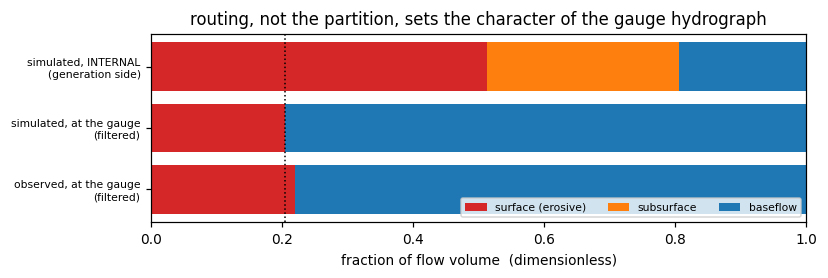

In [15]:
IP = BSUM['internal_partition']
print('MODEL-INTERNAL generation-side partition (docs/26 s A.3) - a DIFFERENT quantity:')
print(f'   surface {IP["surface"]:.3f}   subsurface {IP["subsurface"]:.3f}   '
      f'baseflow {IP["baseflow"]:.3f}')
print(f'ROUTED signature at the gauge, Eckhardt-filtered:')
print(f'   BFI simulated (fleet median) {IP["med_bfi_sim"]:.4f}')
print(f'   BFI observed  (fleet median) {np.median(o):.4f}')
print(f'gap between the internal baseflow fraction and the routed BFI: '
      f'{IP["gap"]:+.4f}')
print(f'gauges whose BFI_sim falls below 0.195: {IP["n_gauges_bfi_sim_below_0195"]} of {len(INC)}')

fig, ax = plt.subplots(figsize=(7.6, 2.6))
ax.barh([2], [IP['surface']], color='tab:red', label='surface (erosive)')
ax.barh([2], [IP['subsurface']], left=[IP['surface']], color='tab:orange', label='subsurface')
ax.barh([2], [IP['baseflow']], left=[IP['surface'] + IP['subsurface']], color='tab:blue',
        label='baseflow')
ax.barh([1], [1 - IP['med_bfi_sim']], color='tab:red')
ax.barh([1], [IP['med_bfi_sim']], left=[1 - IP['med_bfi_sim']], color='tab:blue')
ax.barh([0], [1 - np.median(o)], color='tab:red')
ax.barh([0], [np.median(o)], left=[1 - np.median(o)], color='tab:blue')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['observed, at the gauge\n(filtered)',
                    'simulated, at the gauge\n(filtered)',
                    'simulated, INTERNAL\n(generation side)'], fontsize=7)
ax.set_xlabel('fraction of flow volume  (dimensionless)')
ax.set_xlim(0, 1)
ax.axvline(1 - IP['med_bfi_sim'], color='k', ls=':', lw=1.0)
ax.set_title('routing, not the partition, sets the character of the gauge hydrograph')
ax.legend(fontsize=7, ncol=3, loc='lower right')
plt.tight_layout(); plt.show()

**What is plotted.** Three stacked bars, all in fractions of flow volume (dimensionless). Top: the
model's internal generation-side split into surface (red), subsurface (orange), baseflow (blue).
Middle and bottom: the *routed* split of the simulated and the observed gauge hydrograph into
quickflow (red) and baseflow (blue) as the Eckhardt filter sees it. The dotted line marks the
simulated quickflow share for comparison across bars.

**What it shows.** The model generates **51.3 %** of its runoff as surface flow, but at the gauge
only **20.4 %** of the volume carries the temporal signature of quickflow - a gap of **+0.602**
between the internal baseflow fraction (0.195) and the routed index (0.7965). Not one of the 55
gauges has $\mathrm{BFI_{sim}}$ below 0.195. Crucially, **the observation shows the same thing**:
the real rivers are equally "slow" under this filter, with a routed BFI of 0.781.

**What it means.** Roughly three quarters of what the model generates as fast water arrives at the
gauge looking slow. The routing cascade, not the runoff-generation split, sets the character of the
simulated hydrograph. Two consequences follow and neither is a verdict. First, **the filter cannot
see the partition**: a BFI comparison is not evidence about 51.3/29.2/19.5 in either direction, and
the internal partition remains **never validated against observation**. Second - and this is why
§5 carries the weight of this stage - **MUSLE consumes the un-routed $Q_{\text{sur}}$**, precisely
the quantity a gauge hydrograph cannot constrain. The BFI test was the best available proxy, and
its best is limited.

## 4.6 - The caveat that has to travel with the verdict

H-BFI passes, and the pass is real by the rule that was frozen. Collecting what §3.5 and §4.2-§4.5
measured, here is what a reader should and should not take from it:

**What is established.**

1. The fleet-median routed flow character of the model is within the between-catchment spread of
   the observed one: 0.01625 against 0.02845.
2. The result is robust to the filter's one fixed constant across a sweep from 0.30 to 0.95 - it
   never comes within 25 % of refutation.
3. The error is one-sided (48 of 55 gauges too slow), so it biases MUSLE's surface runoff
   **downward**, in the same direction as the peak deficit.

**What is NOT established, stated as plainly as the pass.**

1. **The test had weak power.** $\mathrm{BFI_{obs}}$ spans only 0.658-0.799 because both
   distributions compress against the fixed ceiling, which is why the yardstick is 0.028 rather
   than something like 0.2. A test whose yardstick is that narrow can only refute a gross failure.
2. **The model carries no between-gauge information about flow character**:
   $r_{\text{cross}} = +0.094$, and the entire error structure is
   $r(\text{difference}, \mathrm{BFI_{obs}}) = -0.825$, i.e. "the observation departs from the
   ceiling and the simulation does not follow".
3. **The error is concentrated in small catchments** - 0.0317 in the smallest area quartile against
   0.0081 in the largest - which is where erosion is generated.
4. **The internal partition is untested** (§4.5), and it is the internal partition MUSLE reads.

**The honest one-line summary: H-BFI is not refuted, but the gate had weak power to detect the
failure it was written to detect.** This was journalled as an issue rather than acted on, because
the rule was frozen and the verdict stands as computed. Anyone proposing a sharper flow-character
test - a flow-duration-curve slope, an event-scale runoff ratio, a storm-event separation - needs a
new pre-registration, and should note that §3.5 has already measured the obvious repair (lower the
ceiling) and shown it does not help.

**And the term that was NOT triggered.** Because H-BFI held, the refit in §6 carries the peak term
**only**. Adding a BFI term on the strength of this caveat would be fabricating a problem the
measurement did not find - and the numbers do not argue for it either: the term would score zero at
an error of 0.20 and no gauge in the fleet reaches 0.12.

---

# 5 - H-PEAK: refuted, and worse than the headline number

## 5.1 - The three peak statistics, defined

A "flood peak" can be measured three ways, and the pre-registration uses all three because they
fail differently.

**(a) The annual maximum series (AMS)** is the largest daily mean flow in each calendar year. It is
the classic flood statistic - the quantity flood-frequency analysis is built on - because it is one
number per year per site and it is what infrastructure is designed against. The comparison is a
*magnitude* comparison: the two maxima need not fall on the same day.

$$R_{\mathrm{AMS}}(g) = \operatorname{median}_{y}
\frac{\max_{t \in y} Q^{\text{sim}}_g(t)}{\max_{t \in y} Q^{\text{obs}}_g(t)}, \qquad
R_{\mathrm{AMS}}(\text{fleet}) = \operatorname{median}_g R_{\mathrm{AMS}}(g)$$

over calendar years $y$ in 2009-2018 with $\ge 300$ valid days at that gauge; $Q$ in
m$^3$ s$^{-1}$; the ratio dimensionless. The median over years, not the mean, so one freak year
cannot set a gauge's score.

**(b) Exceedance flows.** $Q_1$ is the flow exceeded on **1 %** of that gauge's valid days and
$Q_5$ the flow exceeded on **5 %** - i.e. the 99th and 95th percentiles of the daily flow
distribution. They describe the high-flow *regime* rather than individual events:
$R_{\mathrm{Q1}} = Q_1^{\text{sim}} / Q_1^{\text{obs}}$, dimensionless.

**(c) Peaks over threshold (POT).** Instead of one value per year, take *every* independent
excursion above a fixed threshold. Here the threshold is the **observed** $Q_5$ at that gauge,
applied unchanged to **both** series (a per-series threshold would make the two counts
incomparable by construction). Two exceedance peaks count as **independent** if and only if they
are $\ge 10$ days apart **and** the minimum flow between them drops below $0.6\times$ the smaller
of the two - the standard device that stops one long flood being counted as five. POT measures
**how many** floods happened; AMS measures **how big** the biggest was.

**The gate uses only (a) and (b).** $R_{\mathrm{Q5}}$ and the POT counts are measured for mechanism
and by §2's rule may not be substituted for the gate in either direction - which matters here,
because they are the more alarming numbers.

The cell recomputes all four fleet medians from the committed per-gauge table and cross-checks
against `c2b/peaks_summary.json`.

statistic      n  fleet median           IQR over gauges        role  in band?
R_AMS         63        0.8200     0.5285 -   1.1858        GATE        NO
R_Q1          63        0.8470     0.6335 -   1.2343        GATE        NO
R_Q5          63        0.9746     0.7397 -   1.2786  diagnostic       YES
R_POT         63        0.5672     0.1547 -   1.1410  diagnostic        NO

all four reproduce peaks_summary.json to < 1e-9

H-PEAK verdict: REFUTED   (peaks_summary.json says: REFUTED)
   R_AMS 0.8200 is +0.0300 from the lower bound
   R_Q1  0.8470 is +0.0030 from the lower bound
   geometric mean of R_AMS (log-symmetric, matching the refit term): 0.8105
   the two gate statistics are rank-correlated at Spearman 0.928, so the "or" in the rule is not doing any work


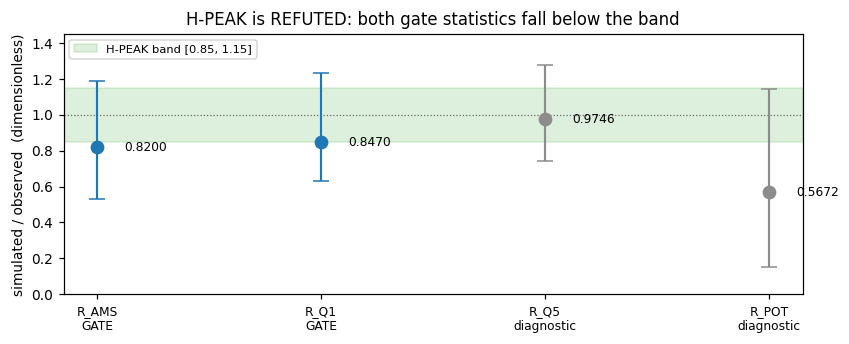

In [16]:
GATE_STATS = ['R_AMS', 'R_Q1']
DIAG_STATS = ['R_Q5', 'R_POT']
print(f'{"statistic":<12}{"n":>4}{"fleet median":>14}{"IQR over gauges":>26}'
      f'{"role":>12}{"in band?":>10}')
FLEET = {}
for c in GATE_STATS + DIAG_STATS:
    v = PK[c].to_numpy(float); v = v[np.isfinite(v)]
    med = float(np.median(v))
    FLEET[c] = med
    assert abs(med - PSUM[c]['med']) < 1e-9, f'{c} disagrees with peaks_summary.json'
    role = 'GATE' if c in GATE_STATS else 'diagnostic'
    inb = PEAK_BAND[0] <= med <= PEAK_BAND[1]
    print(f'{c:<12}{v.size:4d}{med:14.4f}   {np.percentile(v,25):8.4f} - '
          f'{np.percentile(v,75):8.4f}{role:>12}'
          f'{("YES" if inb else "NO"):>10}')
print('\nall four reproduce peaks_summary.json to < 1e-9')

verdict = 'REFUTED' if not all(PEAK_BAND[0] <= FLEET[c] <= PEAK_BAND[1] for c in GATE_STATS) \
    else 'HOLDS'
print(f'\nH-PEAK verdict: {verdict}   (peaks_summary.json says: {PSUM["H_PEAK"]["verdict"]})')
print(f'   R_AMS {FLEET["R_AMS"]:.4f} is {PEAK_BAND[0]-FLEET["R_AMS"]:+.4f} from the lower bound')
print(f'   R_Q1  {FLEET["R_Q1"]:.4f} is {PEAK_BAND[0]-FLEET["R_Q1"]:+.4f} from the lower bound')
gm = float(np.exp(np.mean(np.log(PK['R_AMS'].to_numpy(float)))))
print(f'   geometric mean of R_AMS (log-symmetric, matching the refit term): {gm:.4f}')
rho_gate = stats.spearmanr(PK['R_AMS'], PK['R_Q1']).statistic
print(f'   the two gate statistics are rank-correlated at Spearman {rho_gate:.3f}, '
      f'so the "or" in the rule is not doing any work')

fig, ax = plt.subplots(figsize=(7.8, 3.2))
names = GATE_STATS + DIAG_STATS
vals = [FLEET[c] for c in names]
p25 = [np.nanpercentile(PK[c], 25) for c in names]
p75 = [np.nanpercentile(PK[c], 75) for c in names]
x = np.arange(len(names))
ax.axhspan(*PEAK_BAND, color='tab:green', alpha=0.16, label='H-PEAK band [0.85, 1.15]')
ax.axhline(1.0, color='0.4', lw=0.8, ls=':')
for k, c in enumerate(names):
    col = 'tab:blue' if c in GATE_STATS else '0.55'
    ax.errorbar([k], [vals[k]], yerr=[[vals[k] - p25[k]], [p75[k] - vals[k]]],
                fmt='o', ms=8, color=col, capsize=5, lw=1.4)
    ax.text(k + 0.12, vals[k], f'{vals[k]:.4f}', fontsize=8, va='center')
ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n{"GATE" if c in GATE_STATS else "diagnostic"}' for c in names],
                   fontsize=8)
ax.set_ylabel('simulated / observed  (dimensionless)')
ax.set_ylim(0, 1.45)
ax.set_title(f'H-PEAK is {verdict}: both gate statistics fall below the band')
ax.legend(fontsize=7.5, loc='upper left')
plt.tight_layout(); plt.show()

**What is plotted.** The four peak statistics as fleet medians (markers) with the interquartile
range across the 63 gauges as whiskers, all dimensionless simulated/observed ratios. The green band
is the pre-registered acceptance band $[0.85, 1.15]$; the dotted grey line is perfect agreement at
1.0. Blue markers are the two statistics that can refute the hypothesis; grey are diagnostics that
cannot.

**What it shows.** **$R_{\mathrm{AMS}} = 0.8200$** and **$R_{\mathrm{Q1}} = 0.8470$**, both below
the band - by 0.030 and 0.003 respectively - so **H-PEAK is REFUTED**, and each gate statistic
fails on its own. The diagnostics are worse: $R_{\mathrm{Q5}} = 0.9746$ is almost perfect, but
$R_{\mathrm{POT}} = 0.5672$ - the model produces barely more than half the flood *events*. The
interquartile ranges are enormous (0.53-1.19 for $R_{\mathrm{AMS}}$), and the two gate statistics
are rank-correlated at Spearman 0.928, so the disjunction in the rule is not doing any work.

**What it means.** The refutation is not marginal on its primary statistic: annual maxima are
**18.0 %** low at the median. $R_{\mathrm{Q1}}$ at 0.847 sits 0.003 below its bound and would be
called marginal alone, so it is recorded as marginal and is explicitly **not** the load-bearing
number. The direction is the one $\alpha < 1$ predicted in §1.2, but the magnitude is roughly twice
what $\alpha$ implied, which tells us the deficit is not a uniform flattening of the hydrograph -
it is concentrated somewhere in the tail. §5.2 finds where.

## 5.2 - Where in the flow distribution the bias switches on

$R_{\mathrm{Q5}} = 0.975$ and $R_{\mathrm{AMS}} = 0.820$ cannot both describe a level shift. To
locate the transition, compute the simulated-to-observed ratio of the same exceedance quantile at a
ladder of percentiles:

$$R_p(g) = \frac{Q^{\text{sim}}_{g,p}}{Q^{\text{obs}}_{g,p}}, \qquad
p \in \{50, 75, 90, 95, 99, 99.5\}$$

where $Q_{g,p}$ is the $p$-th percentile of that gauge's daily flow over its valid scored days
(m$^3$ s$^{-1}$), and the fleet value is the median over gauges. $R_{95}$ and $R_{99}$ must
reproduce the committed $R_{\mathrm{Q5}}$ and $R_{\mathrm{Q1}}$ exactly - which is the point of
computing them here rather than trusting the ladder.

**The day set is copied verbatim from `scripts/c2b/peaks_measure.py`** rather than re-derived:
$\le 3$-day gaps linearly interpolated, then only runs of $\ge 180$ contiguous valid days kept,
applied identically to both series. Copying it means this notebook is self-contained; **validating
the copy against the committed table** is what makes the copy safe, and the assertion below is that
validation.

gauges reproduced 63 of 63
max |R_99  - committed R_Q1 |  = 2.220e-16
max |R_95  - committed R_Q5 |  = 2.220e-16
max |R_AMS - committed R_AMS| = 4.441e-16

exceedance percentile     fleet-median ratio
50 %                                  1.1527
75 %                                  1.1677
90 %                                  1.0446
95 %                                  0.9746
99 %                                  0.8470
99.5 %                                0.8340
annual maximum                        0.8200


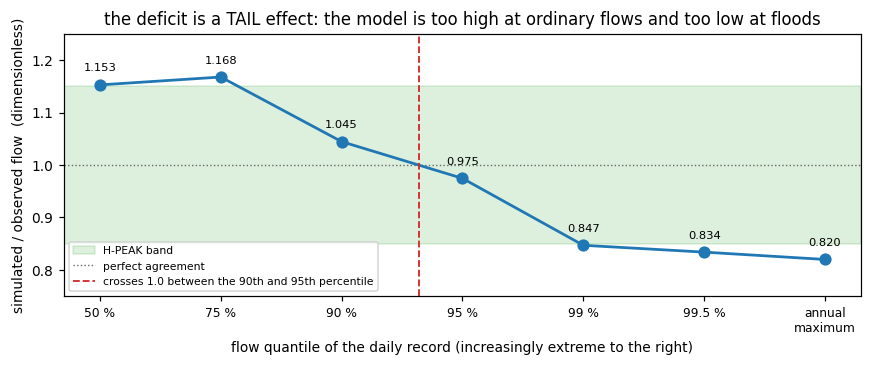

In [17]:
def build_mask(qo):
    # docs/33 s2.1 day set, VERBATIM from scripts/c2b/peaks_measure.py.
    # Returns (mask, q_filled): <= MAX_GAP-day holes linearly interpolated, then only
    # contiguous runs of >= MIN_SEG valid days retained.  Validated below against the
    # committed per-gauge table.
    v = np.isfinite(qo)
    q = qo.copy()
    idx = np.flatnonzero(v)
    if idx.size < 2:
        return np.zeros(NT, bool), q
    filled = v.copy()
    for a, b in zip(idx[:-1], idx[1:]):
        gap = b - a - 1
        if 0 < gap <= MAX_GAP:
            q[a + 1:b] = np.interp(np.arange(a + 1, b), [a, b], [qo[a], qo[b]])
            filled[a + 1:b] = True
    out = np.zeros(NT, bool)
    i = 0
    while i < NT:
        if filled[i]:
            j = i
            while j < NT and filled[j]:
                j += 1
            if j - i >= MIN_SEG:
                out[i:j] = True
            i = j
        else:
            i += 1
    return out, q


PCTS = [50, 75, 90, 95, 99, 99.5]
rows = []
for g in range(NG):
    m, qo = build_mask(QOBS[:, g])
    qs = QSIM[:, g]
    if m.sum() < 30:
        continue
    oo, ss = qo[m], qs[m]
    rec = {'gauge': GC[g], 'n_valid': int(m.sum())}
    for p in PCTS:
        a_ = np.quantile(oo, p / 100.0)
        rec[f'R_{p}'] = np.quantile(ss, p / 100.0) / a_ if a_ > 0 else np.nan
    rr = []
    for yy in range(2009, 2019):
        my = m & (YEAR == yy)
        if my.sum() < MIN_YEAR_DAYS:
            continue
        mo = qo[my].max()
        if mo > 0:
            rr.append(qs[my].max() / mo)
    rec['R_AMS'] = float(np.median(rr)) if rr else np.nan
    rows.append(rec)
LAD = pd.DataFrame(rows)
chk = LAD.merge(PK[['gauge', 'R_Q1', 'R_Q5', 'R_AMS']], on='gauge', suffixes=('', '_csv'))
print(f'gauges reproduced {len(chk)} of {NG}')
print(f'max |R_99  - committed R_Q1 |  = {np.nanmax(np.abs(chk["R_99"]-chk["R_Q1"])):.3e}')
print(f'max |R_95  - committed R_Q5 |  = {np.nanmax(np.abs(chk["R_95"]-chk["R_Q5"])):.3e}')
print(f'max |R_AMS - committed R_AMS| = {np.nanmax(np.abs(chk["R_AMS"]-chk["R_AMS_csv"])):.3e}')
assert np.nanmax(np.abs(chk['R_99'] - chk['R_Q1'])) < 1e-12, 'the copied day set must match'
assert np.nanmax(np.abs(chk['R_AMS'] - chk['R_AMS_csv'])) < 1e-12

fleet_lad = [float(np.nanmedian(LAD[f'R_{p}'])) for p in PCTS] + \
            [float(np.nanmedian(LAD['R_AMS']))]
xlab = [f'{p} %' for p in PCTS] + ['annual\nmaximum']
print(f'\n{"exceedance percentile":<24}{"fleet-median ratio":>20}')
for a_, b_ in zip(xlab, fleet_lad):
    print(f'{a_.replace(chr(10)," "):<24}{b_:20.4f}')

fig, ax = plt.subplots(figsize=(8.0, 3.4))
xx = np.arange(len(fleet_lad))
ax.axhspan(*PEAK_BAND, color='tab:green', alpha=0.16, label='H-PEAK band')
ax.axhline(1.0, color='0.4', lw=0.9, ls=':', label='perfect agreement')
ax.plot(xx, fleet_lad, 'o-', color='tab:blue', lw=1.8, ms=7)
for k, v in enumerate(fleet_lad):
    ax.annotate(f'{v:.3f}', (xx[k], v), textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=7.5)
cross = np.interp(1.0, [fleet_lad[3], fleet_lad[2]], [3, 2])
ax.axvline(cross, color='tab:red', ls='--', lw=1.2,
           label=f'crosses 1.0 between the 90th and 95th percentile')
ax.set_xticks(xx); ax.set_xticklabels(xlab, fontsize=8)
ax.set_xlabel('flow quantile of the daily record (increasingly extreme to the right)')
ax.set_ylabel('simulated / observed flow  (dimensionless)')
ax.set_ylim(0.75, 1.25)
ax.set_title('the deficit is a TAIL effect: the model is too high at ordinary flows and '
             'too low at floods')
ax.legend(fontsize=7, loc='lower left')
plt.tight_layout(); plt.show()

**What is plotted.** The fleet-median simulated/observed flow ratio at six exceedance percentiles
plus the annual maximum, left to right in order of increasing extremeness; dimensionless. The green
band is the pre-registered acceptance band, the dotted line perfect agreement, and the red dashed
vertical marks where the curve crosses 1.0.

**What it shows.** The curve descends monotonically from **1.153** at the median flow through
**1.168** (75th), **1.045** (90th), **0.975** (95th), **0.847** (99th), **0.834** (99.5th) to
**0.820** at the annual maximum. It crosses unity **between the 90th and the 95th percentile**.
The copied day-set code reproduces the committed per-gauge $R_{\mathrm{Q1}}$, $R_{\mathrm{Q5}}$ and
$R_{\mathrm{AMS}}$ to $2\times10^{-16}$ - machine precision - so the ladder and the committed table
are the same measurement.

**What it means.** Three consequences. First, **a uniform multiplicative correction on discharge
would be the wrong repair**: the model is 15 % too *high* at ordinary flows and 18 % too low at
floods, so scaling everything down would worsen the tail and scaling up would wreck the middle.
Second, it explains why the objective never noticed: 95 % of days sit in the region where the model
is fine or generous, and KGE is a whole-record statistic. Third, this **refines** `docs/33` §7.2,
which put the switch-on "between the 95th and the 99th percentile" from three points; with the
ladder the *crossing of unity* is between the 90th and 95th and the deficit then deepens
monotonically. §8 records that refinement.

## 5.3 - Gauge by gauge: a bimodal fleet, not a uniform bias

An 18 % median deficit could mean every gauge is 18 % low, or it could mean two populations. The
cell counts gauges in the three regions of the acceptance band and names the extremes. Inputs: the
`R_AMS` column of `c2b/peaks_per_gauge.csv` (dimensionless) with `area_km2` and the POT counts.

R_AMS below 0.85: 36 gauges
R_AMS inside the band     : 9 gauges  <- the number a sediment modeller would accept
R_AMS above 1.15: 18 gauges
range 0.247 .. 3.169

worst under-prediction:
   gauge  area_km2    R_AMS  n_POT_obs  n_POT_sim
21257090    485.98 0.246756         20          0
26017060    151.83 0.273436         48          1
23147040   1569.45 0.280288         40          0
worst over-prediction:
   gauge  area_km2    R_AMS  n_POT_obs  n_POT_sim
21107030    287.88 3.168677         14         37
22077060    731.39 3.074593         31         45
26237020    209.51 2.292968         20         94

gauges with fewer than 1095 valid days (flagged, NOT excluded from the peak statistics - docs/33 s2.3 does not repeat the BFI rule): 7
   excluding them anyway would give a fleet median of 0.7676 instead of 0.8200


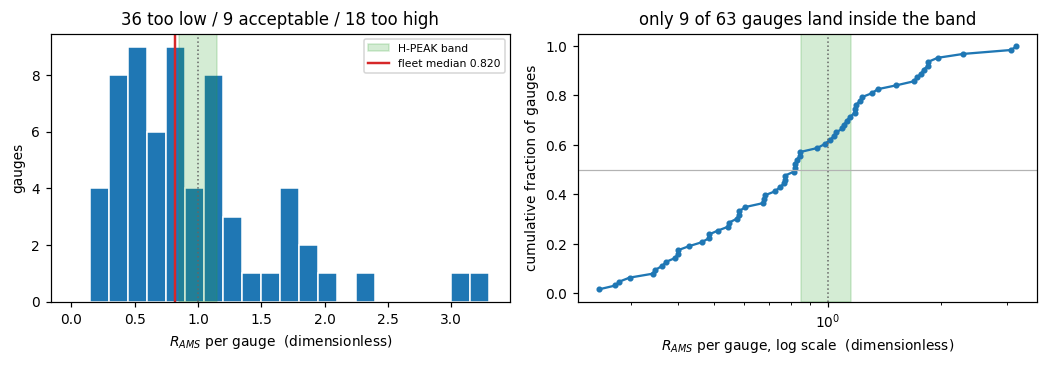

In [18]:
r = PK['R_AMS'].to_numpy(float)
lo_n, in_n, hi_n = int((r < PEAK_BAND[0]).sum()), \
    int(((r >= PEAK_BAND[0]) & (r <= PEAK_BAND[1])).sum()), int((r > PEAK_BAND[1]).sum())
print(f'R_AMS below {PEAK_BAND[0]}: {lo_n} gauges')
print(f'R_AMS inside the band     : {in_n} gauges  <- the number a sediment modeller would accept')
print(f'R_AMS above {PEAK_BAND[1]}: {hi_n} gauges')
print(f'range {r.min():.3f} .. {r.max():.3f}')
print('\nworst under-prediction:')
print(PK.nsmallest(3, 'R_AMS')[['gauge', 'area_km2', 'R_AMS', 'n_POT_obs', 'n_POT_sim']]
      .to_string(index=False))
print('worst over-prediction:')
print(PK.nlargest(3, 'R_AMS')[['gauge', 'area_km2', 'R_AMS', 'n_POT_obs', 'n_POT_sim']]
      .to_string(index=False))
print(f'\ngauges with fewer than {MIN_SCORED_DAYS} valid days (flagged, NOT excluded from the '
      f'peak statistics - docs/33 s2.3 does not repeat the BFI rule): '
      f'{int(PK["lt_1095_days"].sum())}')
rb = PK.loc[~PK['lt_1095_days'], 'R_AMS']
print(f'   excluding them anyway would give a fleet median of {rb.median():.4f} '
      f'instead of {FLEET["R_AMS"]:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.4))
ax[0].hist(r, bins=np.arange(0, 3.4, 0.15), color='tab:blue', edgecolor='w')
ax[0].axvspan(*PEAK_BAND, color='tab:green', alpha=0.20, label='H-PEAK band')
ax[0].axvline(FLEET['R_AMS'], color='tab:red', lw=1.6,
              label=f'fleet median {FLEET["R_AMS"]:.3f}')
ax[0].axvline(1.0, color='0.4', ls=':', lw=1.0)
ax[0].set_xlabel('$R_{AMS}$ per gauge  (dimensionless)')
ax[0].set_ylabel('gauges')
ax[0].set_title(f'{lo_n} too low / {in_n} acceptable / {hi_n} too high')
ax[0].legend(fontsize=7)

srt = np.sort(r)
ax[1].plot(srt, np.arange(1, srt.size + 1) / srt.size, 'o-', ms=3, color='tab:blue')
ax[1].axvspan(*PEAK_BAND, color='tab:green', alpha=0.20)
ax[1].axvline(1.0, color='0.4', ls=':', lw=1.0)
ax[1].axhline(0.5, color='0.7', lw=0.8)
ax[1].set_xscale('log')
ax[1].set_xlabel('$R_{AMS}$ per gauge, log scale  (dimensionless)')
ax[1].set_ylabel('cumulative fraction of gauges')
ax[1].set_title('only 9 of 63 gauges land inside the band')
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the distribution of the per-gauge annual-maximum ratio, with the
acceptance band shaded green, the fleet median in red and perfect agreement dotted. *Right:* the
same values as an empirical cumulative distribution on a log axis, so that under- and
over-prediction by the same factor are equidistant from 1.0. Dimensionless.

**What it shows.** The fleet is **bimodal, not uniformly low**: **36** gauges fall below 0.85,
**18** rise above 1.15, and only **9 of 63** land inside the band. The range is 0.247 to 3.169.
The worst under-predictions are 21257090 (486 km$^2$, $R_{\mathrm{AMS}}$ 0.247, 20 observed flood
events, **0** simulated), 26017060 (152 km$^2$, 0.273, 48 obs / 1 sim) and 23147040 (1,569 km$^2$,
0.280, 40 obs / 0 sim); the worst over-predictions are 21107030 (288 km$^2$, 3.169), 22077060
(731 km$^2$, 3.075) and 26237020 (210 km$^2$, 2.293, with 20 observed events against 94
simulated). Dropping the 7 short-record gauges moves the fleet median from 0.8200 to **0.7676** -
i.e. *further below* the band, so the refutation is not an artefact of the short records. That is a
larger move than `docs/33` §7.3's "excluding them moves nothing material" implies, and §8 records
the disagreement; it cannot change the verdict because it deepens it.

**What it means.** The median lands at 0.820 because the low group is *bigger*, not because the
typical gauge is 18 % low. Nine gauges out of sixty-three have a peak ratio a sediment modeller
would accept. This matters for how the deficit propagates: a **basin-total** sediment figure
inherits the $-10.5$ % of §1.1.1, but a **per-gauge** sediment figure inherits that gauge's own
ratio, which for a fifth of the fleet runs the *other* way. Any per-gauge sediment claim must
therefore carry that gauge's row of this table, and the fleet number must not be used as a local
correction.

## 5.4 - By period: every window is low, and the dry phase is among the worst

Same rule as §4.4: reported, not gating. Sub-period $R_{\mathrm{AMS}}$ is the median over that
window's qualifying years of the same annual-maximum ratio; sub-period $R_{\mathrm{Q1}}$ and
$R_{\mathrm{Q5}}$ are recomputed inside the window (which needs $\ge 90$ valid days), so the
denominators are that window's own exceedance flows. Inputs: the per-period columns of
`c2b/peaks_per_gauge.csv`. All dimensionless.

            period    R_AMS  n_R_AMS     R_Q1  n_R_Q1     R_Q5  n_R_Q5    R_POT  n_R_POT
       CAL 2012-14   0.6478       46   0.8625      54   0.9566      54   0.4228       54
           VAL all   0.8542       63   0.8790      63   0.9542      63   0.6667       63
    VAL La Nina 11   0.8078       48   0.8937      57   0.9774      57   0.5000       57
 VAL El Nino 15-16   0.6857       39   0.7445      50   0.8583      50   0.4643       50
VAL other 09/10/17   0.7940       60   0.9266      63   0.9577      63   0.5714       63
          VAL 2018   0.5893       34   0.7440      49   0.8634      49   0.3750       49

all six period medians reproduce peaks_summary.json to < 1e-9
periods with R_AMS inside the band: 1 of 6


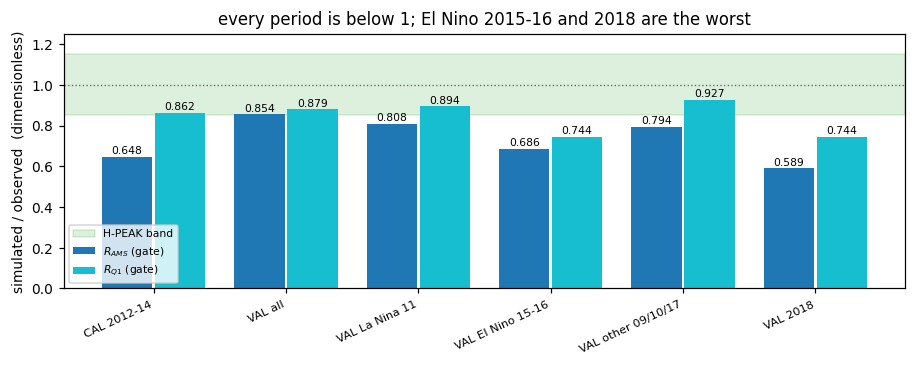

In [19]:
rows = []
for p in PER:
    e = {'period': p}
    for c in ['R_AMS', 'R_Q1', 'R_Q5', 'R_POT']:
        col = f'{c}[{p}]'
        v = PK[col].to_numpy(float) if col in PK else np.array([np.nan])
        e[c] = float(np.nanmedian(v))
        e[f'n_{c}'] = int(np.isfinite(v).sum())
    rows.append(e)
PP = pd.DataFrame(rows)
print(PP.to_string(index=False, float_format=lambda v: f'{v:8.4f}'))
for p in PER:
    ref = PSUM['by_period'][p]['R_AMS']['med']
    got = float(PP.loc[PP['period'] == p, 'R_AMS'].iloc[0])
    assert abs(got - ref) < 1e-9, p
print('\nall six period medians reproduce peaks_summary.json to < 1e-9')
print(f'periods with R_AMS inside the band: '
      f'{int(((PP["R_AMS"]>=PEAK_BAND[0]) & (PP["R_AMS"]<=PEAK_BAND[1])).sum())} of {len(PP)}')

fig, ax = plt.subplots(figsize=(8.4, 3.4))
x = np.arange(len(PER))
ax.axhspan(*PEAK_BAND, color='tab:green', alpha=0.16, label='H-PEAK band')
ax.axhline(1.0, color='0.4', ls=':', lw=0.9)
ax.bar(x - 0.2, PP['R_AMS'], width=0.38, color='tab:blue', label='$R_{AMS}$ (gate)')
ax.bar(x + 0.2, PP['R_Q1'], width=0.38, color='tab:cyan', label='$R_{Q1}$ (gate)')
for k in range(len(PER)):
    ax.text(k - 0.2, PP['R_AMS'][k] + 0.015, f'{PP["R_AMS"][k]:.3f}', ha='center', fontsize=7)
    ax.text(k + 0.2, PP['R_Q1'][k] + 0.015, f'{PP["R_Q1"][k]:.3f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(PER, rotation=25, ha='right', fontsize=7.5)
ax.set_ylabel('simulated / observed  (dimensionless)')
ax.set_ylim(0, 1.25)
ax.set_title('every period is below 1; El Nino 2015-16 and 2018 are the worst')
ax.legend(fontsize=7, loc='lower left')
plt.tight_layout(); plt.show()

**What is plotted.** The two gate statistics by period as bars, with the acceptance band shaded and
perfect agreement dotted. Dimensionless.

**What it shows.** **Every period is below 1 on both statistics.** CAL 2012-14 scores
$R_{\mathrm{AMS}} = 0.648$, VAL all 0.854, La Niña 2011 0.808, **El Niño 2015-16 0.686**, other
neutral years 0.794, and 2018 **0.589**. On $R_{\mathrm{Q1}}$, El Niño and 2018 tie for worst at
0.744. No period's $R_{\mathrm{AMS}}$ lands inside the band.

**What it means.** Two readings, one of which is a trap. The trap: CAL 2012-14 (0.648) is *worse*
than the held-out years (0.854), which looks like overfitting in reverse. It is not - it is a
reminder that **the incumbent objective contained no peak term at all**, so the calibration years
carry no peak advantage to lose. The real reading is the ENSO one, and it is a **prediction** in the
Klemeš sense because neither ENSO window was fitted: the dry El Niño phase has the second-deepest
annual-maximum deficit (0.686 against La Niña's 0.808). Propagated through $\beta = 0.56$ that is
$-19.0$ % against $-11.3$ % - so a La Niña-minus-El Niño sediment contrast computed from these
drivers is biased **toward a larger contrast**. §5.9 quantifies the same asymmetry at event level,
and §7 states what it does to the deliverable.

## 5.5 - Peak bias against catchment size - and why it is NOT the correlation pattern

This project has an established size pattern: the model's timing skill improves with catchment
area, because aggregation averages out the rainfall field's errors. The natural question is whether
the peak deficit follows it. Two Spearman rank correlations against $\log_{10}$ area answer it -
one for the peak ratio and one, as a positive control, for the per-gauge Pearson correlation of the
two daily series:

$$\rho_{\mathrm{AMS}} = \operatorname{Spearman}_g\bigl(R_{\mathrm{AMS}}(g),\ \log_{10} A_g\bigr),
\qquad
\rho_{r} = \operatorname{Spearman}_g\bigl(r_g,\ \log_{10} A_g\bigr)$$

with $r_g = \mathrm{corr}_t(Q^{\text{sim}}_g, Q^{\text{obs}}_g)$ over that gauge's valid days
(dimensionless) and $A_g$ the model-topology upstream area (km$^2$). Areas are the model's own, not
the national catalogue's (`docs/23` §13.2); no per-area quantity is formed.

peak bias            R_AMS      rho +0.0878  p     0.494  n 63   (summary: +0.0878, p 0.494)
peak bias (Q1)       R_Q1       rho +0.0265  p     0.836  n 63   (summary: +0.0265, p 0.836)
event count ratio    R_POT      rho -0.1022  p     0.425  n 63   (summary: -0.1022, p 0.425)
daily correlation    r_pearson  rho +0.5799  p  6.33e-07  n 63   (summary: +0.5799, p 6.33e-07)

tercile    n      area range (km2)    R_AMS  r_pearson
small     21        68 -       288    0.769      0.530
mid       21       298 -     1,563    0.725      0.589
large     21     1,569 -   257,097    0.981      0.739


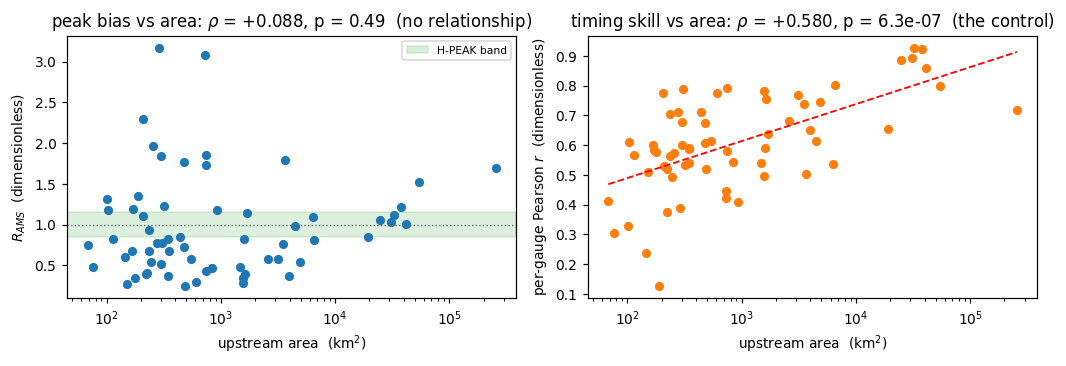

In [20]:
la = np.log10(PK['area_km2'].to_numpy(float))
for c, nm in [('R_AMS', 'peak bias'), ('R_Q1', 'peak bias (Q1)'),
              ('R_POT', 'event count ratio'), ('r_pearson', 'daily correlation')]:
    v = PK[c].to_numpy(float); ok = np.isfinite(v)
    rho, pv = stats.spearmanr(la[ok], v[ok])
    ref = PSUM['area'][c]
    print(f'{nm:<20} {c:<10} rho {rho:+.4f}  p {pv:9.3g}  n {int(ok.sum())}   '
          f'(summary: {ref["spearman_rho"]:+.4f}, p {ref["p"]:.3g})')
ter = pd.qcut(PK['area_km2'], 3, labels=['small', 'mid', 'large'])
print(f'\n{"tercile":<8}{"n":>4}{"area range (km2)":>22}{"R_AMS":>9}{"r_pearson":>11}')
for lab in ['small', 'mid', 'large']:
    sub = PK[ter == lab]
    print(f'{lab:<8}{len(sub):4d}{sub["area_km2"].min():10,.0f} - '
          f'{sub["area_km2"].max():9,.0f}{np.nanmedian(sub["R_AMS"]):9.3f}'
          f'{np.nanmedian(sub["r_pearson"]):11.3f}')

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.4), sharex=True)
rho1, p1 = stats.spearmanr(la, PK['R_AMS'])
ax[0].axhspan(*PEAK_BAND, color='tab:green', alpha=0.16, label='H-PEAK band')
ax[0].semilogx(PK['area_km2'], PK['R_AMS'], 'o', ms=5, color='tab:blue')
ax[0].axhline(1.0, color='0.4', ls=':', lw=0.9)
ax[0].set_xlabel('upstream area  (km$^2$)')
ax[0].set_ylabel('$R_{AMS}$  (dimensionless)')
ax[0].set_title(f'peak bias vs area: $\\rho$ = {rho1:+.3f}, p = {p1:.2f}  (no relationship)')
ax[0].legend(fontsize=7)
rho2, p2 = stats.spearmanr(la, PK['r_pearson'])
ax[1].semilogx(PK['area_km2'], PK['r_pearson'], 'o', ms=5, color='tab:orange')
xs = np.logspace(np.log10(PK['area_km2'].min()), np.log10(PK['area_km2'].max()), 20)
pf = np.polyfit(la, PK['r_pearson'], 1)
ax[1].plot(xs, np.polyval(pf, np.log10(xs)), 'r--', lw=1.2)
ax[1].set_xlabel('upstream area  (km$^2$)')
ax[1].set_ylabel('per-gauge Pearson $r$  (dimensionless)')
ax[1].set_title(f'timing skill vs area: $\\rho$ = {rho2:+.3f}, p = {p2:.1e}  (the control)')
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the per-gauge annual-maximum ratio against upstream area on a log
axis, with the acceptance band shaded. *Right:* the per-gauge Pearson correlation between the two
daily series against the same axis, with a least-squares line. Both dimensionless against km$^2$.

**What it shows.** The control works and the test fails. Timing skill rises strongly and
significantly with area: **$\rho_r = +0.580$, p $= 6.3\times10^{-7}$**, with tercile medians
0.530 (68-288 km$^2$), 0.589 (298-1,563) and 0.739 (1,569-257,097). Peak bias does not:
**$\rho_{\mathrm{AMS}} = +0.088$, p $= 0.49$** - indistinguishable from zero. The tercile medians
of $R_{\mathrm{AMS}}$ (0.769 / 0.725 / 0.981) hint that the biggest catchments are least biased,
but the rank correlation says that is not monotone and not significant at n = 63, and the two
largest gauges in the fleet over-predict badly (`c2b/peaks_per_gauge.csv`, read rather than printed
above: 29037020 at $R_{\mathrm{AMS}}$ 1.690 - on only 3 observed flood events, the reason §7.1
excludes it - and 21237020 at 1.523).

**What it means.** **Peaks do not follow the correlation pattern**, and the honest reading of the
tercile hint is that aggregation *cancels* peak errors of both signs inside a median without
removing them at any individual large gauge. That distinction matters for the deliverable: the
basin outlet is a large catchment, so its peak error is small in the median - but that is
cancellation, not accuracy, and the sediment source term is generated in the small catchments where
no such cancellation occurs. It also, in passing, removes the first candidate explanation for the
deficit: an error caused by the daily time step would have to be **strongest in the smallest
catchments**, and it is not (§7 measures this again at event level and reaches the same null).

## 5.6 - Event count: worse than event size

$R_{\mathrm{POT}}$ compares how *many* independent floods each series produced above the same
observed threshold. It is a diagnostic and cannot move the verdict - but for sediment it is the
more consequential number, because sediment is delivered in events and an event that never happens
contributes zero load, not a scaled-down load. Inputs: the `n_POT_obs` and `n_POT_sim` columns of
the committed table (counts, dimensionless).

fleet totals: 2,236 observed independent flood events, 1,285 simulated
   pooled ratio 0.5747   (peaks_summary.json: 0.5747)
   fleet MEDIAN of the per-gauge ratio 0.5672
gauges under-producing events: 42 of 63
gauges producing ZERO events above their own observed Q5 over ten years: 4
gauges over-producing: 19
observed events per gauge: median 37, range 3-78


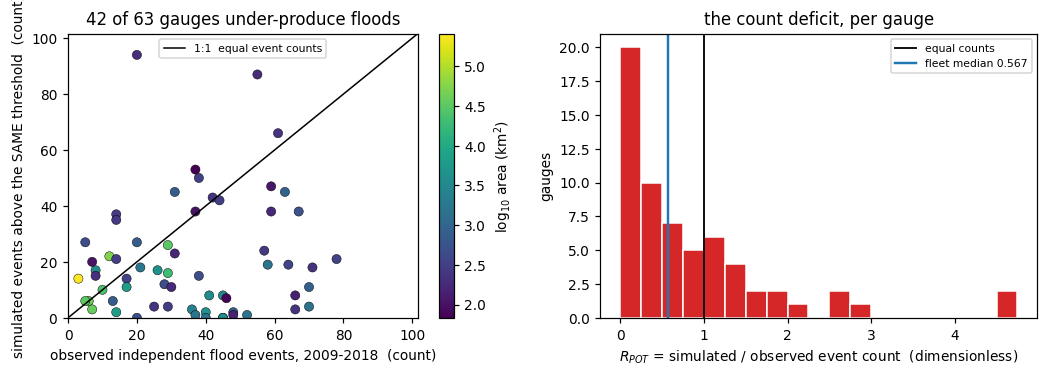

In [21]:
no_, ns_ = PK['n_POT_obs'].to_numpy(), PK['n_POT_sim'].to_numpy()
print(f'fleet totals: {no_.sum():,} observed independent flood events, {ns_.sum():,} simulated')
print(f'   pooled ratio {ns_.sum()/no_.sum():.4f}   (peaks_summary.json: '
      f'{PSUM["POT_totals"]["ratio"]:.4f})')
print(f'   fleet MEDIAN of the per-gauge ratio {FLEET["R_POT"]:.4f}')
print(f'gauges under-producing events: {int((ns_ < no_).sum())} of {NG}')
print(f'gauges producing ZERO events above their own observed Q5 over ten years: '
      f'{int((ns_ == 0).sum())}')
print(f'gauges over-producing: {int((ns_ > no_).sum())}')
print(f'observed events per gauge: median {np.median(no_):.0f}, range {no_.min()}-{no_.max()}')

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.5))
mx = max(no_.max(), ns_.max()) * 1.08
ax[0].plot([0, mx], [0, mx], 'k-', lw=1.0, label='1:1  equal event counts')
sc = ax[0].scatter(no_, ns_, c=np.log10(PK['area_km2']), cmap='viridis', s=36,
                   edgecolor='k', linewidth=0.3)
ax[0].set_xlim(0, mx); ax[0].set_ylim(0, mx)
ax[0].set_xlabel('observed independent flood events, 2009-2018  (count)')
ax[0].set_ylabel('simulated events above the SAME threshold  (count)')
ax[0].set_title(f'{int((ns_ < no_).sum())} of {NG} gauges under-produce floods')
ax[0].legend(fontsize=7)
plt.colorbar(sc, ax=ax[0], label='log$_{10}$ area (km$^2$)')
ax[1].hist(PK['R_POT'].to_numpy(float), bins=np.arange(0, 5.0, 0.25), color='tab:red',
           edgecolor='w')
ax[1].axvline(1.0, color='k', lw=1.2, label='equal counts')
ax[1].axvline(FLEET['R_POT'], color='tab:blue', lw=1.6,
              label=f'fleet median {FLEET["R_POT"]:.3f}')
ax[1].set_xlabel('$R_{POT}$ = simulated / observed event count  (dimensionless)')
ax[1].set_ylabel('gauges'); ax[1].legend(fontsize=7)
ax[1].set_title('the count deficit, per gauge')
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* simulated against observed counts of independent flood events per
gauge over 2009-2018, coloured by log area, with the 1:1 line - points below the line are gauges
where the model produces fewer floods than the river did. *Right:* the distribution of the
per-gauge count ratio, with equal counts and the fleet median marked. Counts and ratios are
dimensionless.

**What it shows.** Pooled over the fleet the model produces **1,285 independent flood events
against 2,236 observed - 57.5 %**, i.e. it misses **43 %** of the excursions above the observed
5 %-exceedance threshold. **42 of 63** gauges under-produce, **19** over-produce, 2 tie, and
**4 gauges produce zero simulated exceedances** of their own observed threshold in ten years. The
per-gauge ratio spans 0.0 to 5.4.

**What it means.** For discharge this is a diagnostic; for sediment it is the number that hurts.
MUSLE is an event equation: load is produced when surface runoff and a peak coincide. A model that
generates a little over half the events will under-deliver load **even where the surviving peaks
are the right size**, and the $R^{0.56}$ arithmetic of §1.1.1 does not capture it at all - you
cannot convert a count deficit into a magnitude factor, and `docs/35` §5.2 records
$0.567^{0.56}$ as a forbidden calculation. This is why the sediment result must be framed as a
**lower bound** rather than as a biased estimate with a correction attached.

## 5.7 - The deeper number: 81.8 % of observed floods have no simulated counterpart

The count ratio 0.575 still flatters the model, because it compares *totals*: 1,285 simulated
events could in principle be 1,285 of the 2,236 real ones. The follow-up diagnosis
(`data/processed/peakgap/`) matched them event by event. The matching is greedy one-to-one within a
window $\pm w$ days:

$$\text{matched}(w) = \bigl|\{\text{observed POT with an unused simulated POT within } \pm w
\text{ days}\}\bigr|, \qquad
\text{ceiling} = \frac{n^{\text{sim}}}{n^{\text{obs}}} = 0.575$$

The ceiling exists because one-to-one matching cannot pair more observed events than there are
simulated events to pair them with, so no window can push the matched fraction above 57.5 %. If the
deficit were a **timing** problem - the right floods on the wrong days - the matched fraction would
climb steeply with $w$ and approach that ceiling. This cell reads the window sweep from
`peakgap/match_sensitivity.csv` (one row per gauge per window) and aggregates it, cross-checking
against `peakgap/summary.json`.

     n_obs  n_sim  n_matched  matched_frac
win                                       
0     2236   1285        113        0.0505
1     2236   1285        318        0.1422
2     2236   1285        407        0.1820
3     2236   1285        464        0.2075
5     2236   1285        544        0.2433
7     2236   1285        591        0.2643
10    2236   1285        643        0.2876
15    2236   1285        697        0.3117
20    2236   1285        720        0.3220
30    2236   1285        756        0.3381

every window fraction reproduces peakgap/summary.json to < 1e-9

at the pre-registered +/-2 d window:
   1,829 of 2,236 observed flood events (81.8 %) have NO simulated event within 2 days
   MIRROR: 878 of 1,285 simulated events (68.3 %) have no observed counterpart
at +/-30 d: matched 33.8 % against a ceiling of 57.5 %
a full month of slack recovers only 15.6 percentage points


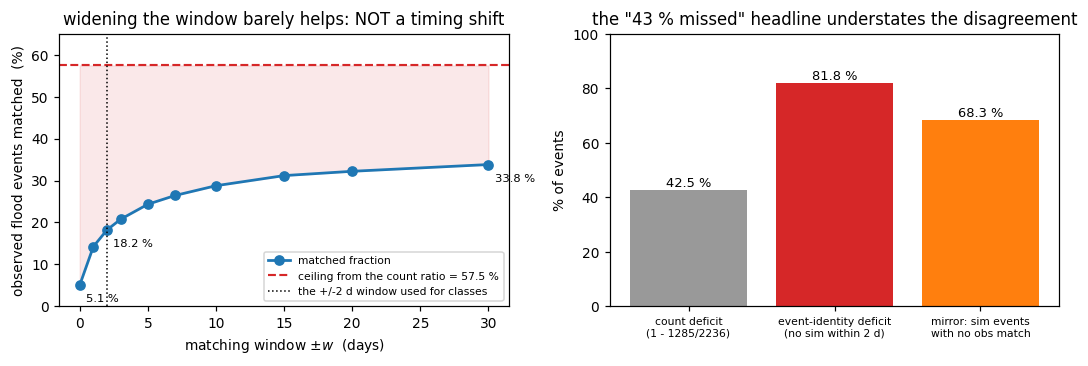

In [22]:
agg = MSENS.groupby('win')[['n_obs', 'n_sim', 'n_matched']].sum()
agg['matched_frac'] = agg['n_matched'] / agg['n_obs']
ceiling = float(GAP['pot_totals']['sim']) / float(GAP['pot_totals']['obs'])
print(agg.to_string(float_format=lambda v: f'{v:10.4f}'))
for w in agg.index:
    ref = GAP['timing_sensitivity'][str(w)]['matched_frac']
    assert abs(agg.loc[w, 'matched_frac'] - ref) < 1e-9, w
print('\nevery window fraction reproduces peakgap/summary.json to < 1e-9')
n_obs = int(GAP['pot_totals']['obs']); n_sim = int(GAP['pot_totals']['sim'])
n_missed = int(GAP['pot_totals']['n_missed']); m2 = int(agg.loc[2, 'n_matched'])
print(f'\nat the pre-registered +/-2 d window:')
print(f'   {n_missed:,} of {n_obs:,} observed flood events ({100*n_missed/n_obs:.1f} %) have NO '
      f'simulated event within 2 days')
print(f'   MIRROR: {n_sim-m2:,} of {n_sim:,} simulated events ({100*(n_sim-m2)/n_sim:.1f} %) have '
      f'no observed counterpart')
print(f'at +/-30 d: matched {agg.loc[30,"matched_frac"]*100:.1f} % against a ceiling of '
      f'{100*ceiling:.1f} %')
print(f'a full month of slack recovers only '
      f'{100*(agg.loc[30,"matched_frac"]-agg.loc[2,"matched_frac"]):.1f} percentage points')

fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.4))
ax[0].plot(agg.index, 100 * agg['matched_frac'], 'o-', color='tab:blue', lw=1.8,
           label='matched fraction')
ax[0].axhline(100 * ceiling, color='tab:red', ls='--', lw=1.4,
              label=f'ceiling from the count ratio = {100*ceiling:.1f} %')
ax[0].axvline(2, color='k', ls=':', lw=1.0, label='the +/-2 d window used for classes')
ax[0].fill_between(agg.index, 100 * agg['matched_frac'], 100 * ceiling, color='tab:red',
                   alpha=0.10)
for w in (0, 2, 30):
    ax[0].annotate(f'{100*agg.loc[w,"matched_frac"]:.1f} %', (w, 100 * agg.loc[w, 'matched_frac']),
                   textcoords='offset points', xytext=(4, -11), fontsize=7.5)
ax[0].set_xlabel('matching window $\\pm w$  (days)')
ax[0].set_ylabel('observed flood events matched  (%)')
ax[0].set_ylim(0, 65)
ax[0].set_title('widening the window barely helps: NOT a timing shift')
ax[0].legend(fontsize=7, loc='lower right')

lab = ['count deficit\n(1 - 1285/2236)', 'event-identity deficit\n(no sim within 2 d)',
       'mirror: sim events\nwith no obs match']
val = [100 * (1 - ceiling), 100 * n_missed / n_obs, 100 * (n_sim - m2) / n_sim]
ax[1].bar(range(3), val, color=['0.6', 'tab:red', 'tab:orange'])
for k, v in enumerate(val):
    ax[1].text(k, v + 1.2, f'{v:.1f} %', ha='center', fontsize=8.5)
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(lab, fontsize=7)
ax[1].set_ylabel('% of events')
ax[1].set_ylim(0, 100)
ax[1].set_title('the "43 % missed" headline understates the disagreement')
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the percentage of the 2,236 observed flood events that can be paired
one-to-one with a simulated event, as the matching window widens from $\pm 0$ to $\pm 30$ days; the
red dashed line is the hard ceiling set by the count ratio and the shaded gap is what no window can
recover. *Right:* three ways of stating the deficit as a percentage.

**What it shows.** At the pre-registered $\pm 2$ days, **1,829 of 2,236 observed flood events
(81.8 %) have no simulated counterpart**, and the mirror statistic is nearly as bad: **878 of 1,285
simulated events (68.3 %) have no observed counterpart**. Widening the window from $\pm 2$ d to
$\pm 30$ d raises the matched fraction only from **18.2 % to 33.8 %** - 15.6 percentage points -
and never approaches the 57.5 % ceiling. Every aggregated fraction reproduces the committed summary
to $<10^{-9}$.

**What it means.** This is the sharpest number in the notebook and it changes the framing. The
"43 % of floods missed" headline is a **count** deficit and it understates the disagreement badly:
the model does not merely make too few floods, **it makes them on the wrong days**. And the shape of
the window curve refutes the most comfortable explanation available - that the model has the right
events with a routing lag. A full month of slack recovers a sixth of the gap. The events are absent
or displaced far beyond any plausible routing time for catchments of 68-257,000 km$^2$. Both
numbers must from now on be quoted together, and `docs/36` §7 item 1 records that as a correction
to be propagated to three other documents.

## 5.8 - What the missed floods actually look like in the simulation

Not all 1,829 misses are alike. The follow-up diagnosis classified each by what the simulation was
doing within $\pm 2$ days of the observed peak, using the simulated rise relative to its own 8-15
day prior baseline:

| class | definition | what it means mechanically |
|---|---|---|
| **ABSENT** | simulated flow within $\pm 2$ d stayed below $1.5\times$ its 8-15 d prior baseline | **no hydrograph rise at all** - the model did not see a storm |
| PRESENT, sub-extreme | rose $\ge 1.5\times$ but stayed below the model's own $Q_5$ | the model saw something, but not a flood |
| PRESENT and extreme | exceeded the model's own $Q_5$; only the magnitude is wrong | the model called it a flood and scaled it down |

The distinction is decisive for what could fix it: a *magnitude* problem can be repaired by
routing, by a peak parameterisation, or by parameters, whereas a **rise that never happened cannot
be created by anything downstream of runoff generation**. This cell reads the class counts from
`peakgap/summary.json` and the per-event table, and plots one ABSENT event in full.

class                        n  % of missed   % of all obs POT
absent                     737         40.3               33.0
present_sub_extreme        631         34.5               28.2
present_sim_extreme        461         25.2               20.6

median simulated flow at a missed event, as a fraction of the observed Q5 threshold: 0.616
   quartiles 0.397 / 0.616 / 0.877
   31.7 % of misses come within 20 % of the threshold; 37.1 % fall below half of it

within the 737 ABSENT events:
   408 (55.4 %) had 3-day forcing rainfall below their own gauge's 33rd percentile of POT-day rainfall
   74 (10.0 %) had the storm present in the forcing at all (>= 2/3 percentile)
   224 (30.4 %) are single-day observed spikes rising > 3x their own prior baseline

example ABSENT event: gauge 21167090, 2011-01-04, 345 km2
   observed peak 234.0 m3/s against its observed Q5 of 36.8 m3/s  (6.36x)
   simulated maximum within +/-2 d: 5.97 m3/s = 0.162 of that threshold; simulated rise 0.53x its own basel

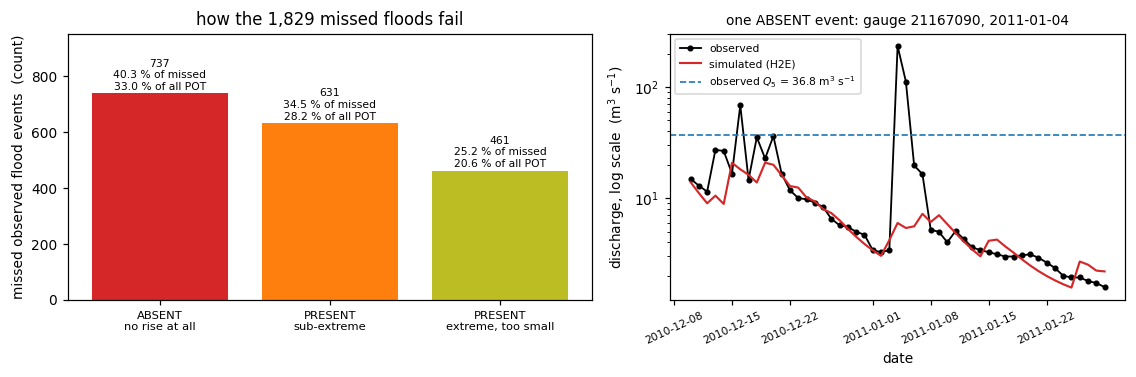

In [23]:
CL = GAP['e_absent_vs_subthreshold']
print(f'{"class":<24}{"n":>6}{"% of missed":>13}{"% of all obs POT":>19}')
for k in ['absent', 'present_sub_extreme', 'present_sim_extreme']:
    print(f'{k:<24}{CL["counts"][k]:6d}{100*CL["frac"][k]:13.1f}{100*CL["of_all_obs_POT"][k]:19.1f}')
print(f'\nmedian simulated flow at a missed event, as a fraction of the observed Q5 threshold: '
      f'{CL["median_sim_over_Q5obs"]:.3f}')
print(f'   quartiles {CL["sim_over_Q5obs_quartiles"][0]:.3f} / '
      f'{CL["sim_over_Q5obs_quartiles"][1]:.3f} / {CL["sim_over_Q5obs_quartiles"][2]:.3f}')
print(f'   {100*CL["frac_missed_sim_within_20pct_of_thr"]:.1f} % of misses come within 20 % of '
      f'the threshold; {100*CL["frac_missed_sim_below_half_thr"]:.1f} % fall below half of it')
ABS_ = EV[EV['klass'] == 'absent']
print(f'\nwithin the {len(ABS_)} ABSENT events:')
print(f'   {int((ABS_["P3_pct"] < 1/3).sum())} ({100*(ABS_["P3_pct"] < 1/3).mean():.1f} %) had '
      f'3-day forcing rainfall below their own gauge\'s 33rd percentile of POT-day rainfall')
print(f'   {int((ABS_["P3_pct"] >= 2/3).sum())} ({100*(ABS_["P3_pct"] >= 2/3).mean():.1f} %) had '
      f'the storm present in the forcing at all (>= 2/3 percentile)')
print(f'   {int(((ABS_["dur_days"] <= 1) & (ABS_["obs_rise"] > 3)).sum())} '
      f'({100*((ABS_["dur_days"] <= 1) & (ABS_["obs_rise"] > 3)).mean():.1f} %) are single-day '
      f'observed spikes rising > 3x their own prior baseline')

EG, ED = '21167090', '2011-01-04'
erow = EV[(EV['gauge'].astype(str) == EG) & (EV['date'] == ED)].iloc[0]
je = int(np.flatnonzero(GC == EG)[0])
te = int(np.flatnonzero(DATES == pd.Timestamp(ED))[0])
print(f'\nexample ABSENT event: gauge {EG}, {ED}, {erow["area_km2"]:,.0f} km2')
print(f'   observed peak {erow["q_obs"]:.1f} m3/s against its observed Q5 of '
      f'{erow["q5_obs"]:.1f} m3/s  ({erow["mag_over_Q5"]:.2f}x)')
print(f'   simulated maximum within +/-2 d: {erow["sim_max_win"]:.2f} m3/s = '
      f'{erow["sim_over_Q5obs"]:.3f} of that threshold; simulated rise '
      f'{erow["sim_rise"]:.2f}x its own baseline (ABSENT needs < 1.5x)')
print(f'   3-day forcing rainfall {erow["P3"]:.1f} mm = percentile '
      f'{erow["P3_pct"]:.3f} of this gauge\'s POT-day rainfall')

fig, ax = plt.subplots(1, 2, figsize=(10.4, 3.5),
                       gridspec_kw={'width_ratios': [1.15, 1]})
cls = ['absent', 'present_sub_extreme', 'present_sim_extreme']
cnt = [CL['counts'][k] for k in cls]
ax[0].bar(range(3), cnt, color=['tab:red', 'tab:orange', 'tab:olive'])
for k, v in enumerate(cnt):
    ax[0].text(k, v + 14, f'{v}\n{100*v/n_missed:.1f} % of missed\n'
                          f'{100*v/n_obs:.1f} % of all POT', ha='center', fontsize=7)
ax[0].set_xticks(range(3))
ax[0].set_xticklabels(['ABSENT\nno rise at all', 'PRESENT\nsub-extreme',
                       'PRESENT\nextreme, too small'], fontsize=7.5)
ax[0].set_ylabel('missed observed flood events  (count)')
ax[0].set_ylim(0, 950)
ax[0].set_title(f'how the {n_missed:,} missed floods fail')

sl = slice(te - 25, te + 26)
ax[1].plot(DATES[sl], QOBS[sl, je], 'k-o', ms=3, lw=1.2, label='observed')
ax[1].plot(DATES[sl], QSIM[sl, je], '-', color='tab:red', lw=1.4, label='simulated (H2E)')
ax[1].axhline(erow['q5_obs'], color='tab:blue', ls='--', lw=1.1,
              label=f'observed $Q_5$ = {erow["q5_obs"]:.1f} m$^3$ s$^{{-1}}$')
ax[1].set_yscale('log')
ax[1].set_ylabel('discharge, log scale  (m$^3$ s$^{-1}$)')
ax[1].set_xlabel('date')
ax[1].tick_params(axis='x', labelrotation=25, labelsize=7)
ax[1].legend(fontsize=7, loc='upper left')
ax[1].set_title(f'one ABSENT event: gauge {EG}, {ED}', fontsize=9)
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the 1,829 missed flood events split into the three classes, counts on
the y-axis, each bar annotated with its share of the missed events and of all observed events.
*Right:* one ABSENT event in detail - 51 days of observed (black, markers) and simulated (red)
discharge on a logarithmic axis in m$^3$ s$^{-1}$, with the gauge's observed 5 %-exceedance
threshold dashed in blue.

**What it shows.** **737 events - 40.3 % of the misses and 33.0 % of all 2,236 observed floods -
are ABSENT: the simulation produced no hydrograph rise whatsoever.** 631 (34.5 %) produced a rise
that stayed sub-extreme, and 461 (25.2 %) were called extreme but scaled down. At a typical missed
event the simulated flow reaches only **0.616** of the observed threshold. Inside the ABSENT class,
**408 of 737 (55.4 %)** had 3-day forcing rainfall below their gauge's own 33rd percentile, and only
**74 (10.0 %)** had the storm present in the forcing at all. The example event is stark: observed
flow jumps from 3.4 to **234 m$^3$ s$^{-1}$** - 6.4x the gauge's $Q_5$ - while the simulation moves
from 4.2 to 6.0 m$^3$ s$^{-1}$, a rise of 0.53x its own baseline, with just **15.3 mm** of 3-day
rainfall in the forcing, the 6th percentile of that gauge's flood-day rainfall.

**What it means.** A third of all observed floods produce **nothing** in the simulation, and in most
of those cases there was no storm in the model's input to respond to. That single fact constrains
every candidate repair: routing, a peak formula, and channel hydraulics all operate *downstream* of
runoff generation and cannot manufacture a rise that generation never produced, and a parameter set
cannot invent rainfall. §7 is where that argument is completed. The example also illustrates an
honest ambiguity rather than a clean win: a 69x single-day jump with no rain in the forcing is
*also* the signature of a rating-curve artefact, and `docs/36` §2.5 bounds that channel at
$\le 10$ % of all observed events (224 of 2,236 are single-day spikes of this kind). It is an upper
bound, not an estimate, and it does not discount the lower-bound framing.

## 5.9 - The ENSO asymmetry the deliverable inherits

The project's headline is a wet-versus-dry sediment contrast, so the *difference* in peak
performance between the two ENSO phases is not a detail - it biases the answer. This cell reads the
per-phase miss fractions from `peakgap/summary.json` (dimensionless fractions of that phase's
observed events) beside the per-phase annual-maximum ratios from §5.4, and converts the latter
through $\beta$.

phase                   event miss fraction    R_AMS   R_AMS^0.56
La Nina 2011                         0.7162   0.8078       0.8873
El Nino 2015-16                      0.8871   0.6857       0.8095
other                                0.8367   0.7940       0.8788

simulated La Nina : El Nino sediment ratio is inflated by a factor 1.0961 (+9.6 %) by the peak asymmetry alone
observed contrast (docs/34, model-free): 2.8x - 4.6x primary windows, 6.4x - 9.3x sensitivity, same sign at 22/22 stations
a +9.6 % inflation cannot flip a contrast of that size or sign


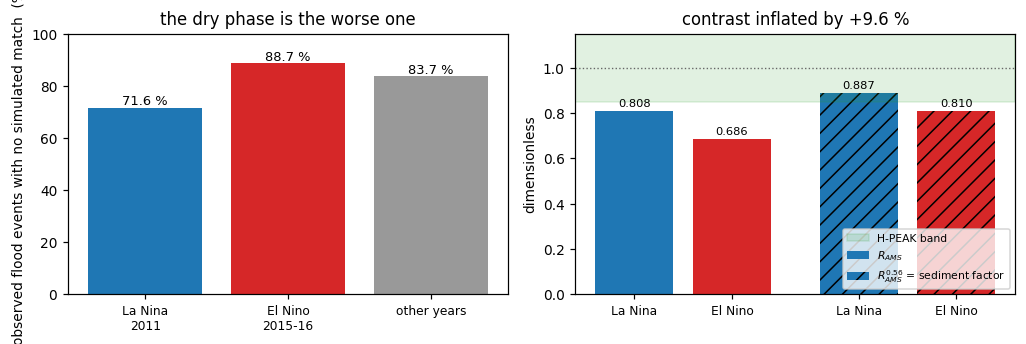

In [24]:
EN = GAP['x_enso']
print(f'{"phase":<22}{"event miss fraction":>21}{"R_AMS":>9}{"R_AMS^0.56":>13}')
pmap = {'La Nina 2011': 'VAL La Nina 11', 'El Nino 2015-16': 'VAL El Nino 15-16',
        'other': 'VAL other 09/10/17'}
for k, p in pmap.items():
    ra = float(PP.loc[PP['period'] == p, 'R_AMS'].iloc[0])
    print(f'{k:<22}{EN[k]:21.4f}{ra:9.4f}{ra**BETA_MUSLE:13.4f}')
ra_n = float(PP.loc[PP['period'] == 'VAL La Nina 11', 'R_AMS'].iloc[0])
ra_e = float(PP.loc[PP['period'] == 'VAL El Nino 15-16', 'R_AMS'].iloc[0])
infl = (ra_n ** BETA_MUSLE) / (ra_e ** BETA_MUSLE)
print(f'\nsimulated La Nina : El Nino sediment ratio is inflated by a factor '
      f'{infl:.4f} ({100*(infl-1):+.1f} %) by the peak asymmetry alone')
print(f'observed contrast (docs/34, model-free): 2.8x - 4.6x primary windows, '
      f'6.4x - 9.3x sensitivity, same sign at 22/22 stations')
print(f'a {100*(infl-1):+.1f} % inflation cannot flip a contrast of that size or sign')

fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.2))
ks = list(pmap)
ax[0].bar(range(3), [100 * EN[k] for k in ks],
          color=['tab:blue', 'tab:red', '0.6'])
for k, v in enumerate([100 * EN[x] for x in ks]):
    ax[0].text(k, v + 1.0, f'{v:.1f} %', ha='center', fontsize=8.5)
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(['La Nina\n2011', 'El Nino\n2015-16',
                                                   'other years'], fontsize=8)
ax[0].set_ylabel('observed flood events with no simulated match  (%)')
ax[0].set_ylim(0, 100)
ax[0].set_title('the dry phase is the worse one')
ax[1].bar([0, 1], [ra_n, ra_e], color=['tab:blue', 'tab:red'], label='$R_{AMS}$')
ax[1].bar([2.3, 3.3], [ra_n ** BETA_MUSLE, ra_e ** BETA_MUSLE], color=['tab:blue', 'tab:red'],
          hatch='//', label='$R_{AMS}^{0.56}$ = sediment factor')
ax[1].axhspan(*PEAK_BAND, color='tab:green', alpha=0.14, label='H-PEAK band')
ax[1].axhline(1.0, color='0.4', ls=':', lw=0.9)
for x, v in zip([0, 1, 2.3, 3.3], [ra_n, ra_e, ra_n ** BETA_MUSLE, ra_e ** BETA_MUSLE]):
    ax[1].text(x, v + 0.02, f'{v:.3f}', ha='center', fontsize=7.5)
ax[1].set_xticks([0, 1, 2.3, 3.3])
ax[1].set_xticklabels(['La Nina', 'El Nino', 'La Nina', 'El Nino'], fontsize=8)
ax[1].set_ylabel('dimensionless')
ax[1].set_ylim(0, 1.15)
ax[1].legend(fontsize=7, loc='lower right')
ax[1].set_title(f'contrast inflated by {100*(infl-1):+.1f} %')
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the fraction of that phase's observed flood events with no simulated
counterpart within $\pm 2$ days, as a percentage, for the wet La Niña window, the dry El Niño
window, and the remaining years. *Right:* the annual-maximum ratio for the two ENSO windows (plain
bars) and the sediment factor $R^{0.56}$ each implies (hatched), with the acceptance band shaded.
Dimensionless.

**What it shows.** The dry phase is the worse one on both measures: **88.7 %** of El Niño flood
events are unmatched against **71.6 %** in La Niña (83.7 % in other years), and
$R_{\mathrm{AMS}}$ is 0.686 against 0.808. Through $\beta = 0.56$ that becomes sediment factors of
0.8095 (El Niño) and 0.8873 (La Niña), so the **simulated wet:dry sediment ratio is inflated by
+9.6 %** by the peak asymmetry alone - which is the $\approx +10$ % `docs/36` §2.6 quotes.

**What it means.** The bias runs in the direction that *flatters* the headline result, which is
exactly the direction that must be declared rather than discovered. It is small against what it
would have to overturn: the observed, model-free flux contrast is 2.8x-4.6x on the primary windows
(6.4x-9.3x on the sensitivity windows) with the same sign at 22 of 22 stations, and a +9 %
inflation cannot flip a contrast of that size, let alone its sign. But the number now travels with
the simulated contrast wherever it is quoted - and if the simulated contrast were ever to come
within 10 % of the observed one, the caveat would stop being a caveat and become a refutation.

**Added 2026-08-19 - that condition is now in play, and this page does not settle it.** `docs/56`
(C5) has since applied the frozen sediment configuration to these two windows and printed a median
modelled rate ratio of **3.05x** over **18 of 18** stations, against the **named** reference
estimator (b), whose observed median is **2.84-2.95**. So the simulated and observed contrasts now
agree to within the 10 % this paragraph nominated, while the peak asymmetry measured above inflates
the simulated one by **+9.6 %** - a bias of the same size as the whole agreement. Whether the
clause fires is `docs/56`'s adjudication to make and **it has not been made**; nothing here decides
it, and the number above must be quoted alongside `docs/56`'s wherever either travels.

*(The percentage printed by the cell is $+9.6$ %; `docs/36` §2.6 rounds it to "$\approx +10$ %".
Both refer to the same calculation.)*

## 5.10 - What C3 and C4 inherit from H-PEAK

Putting §5 together into the sentence the sediment stages have to carry:

> **The measured fleet-median annual-maximum peak deficit of 18.0 % propagates through MUSLE's
> $q_{\text{peak}}^{0.56}$ to an expected sediment under-prediction of about 10.5 %, rising to
> about 19 % in the El Niño 2015-16 dry phase where the peak deficit is deepest.**

Three qualifications must travel with it, and none is optional:

1. **It is a floor, not a total.** It counts the *magnitude* term only. The **event-count** deficit
   is not in the $R^{0.56}$ arithmetic at all - an event that does not happen contributes zero load,
   not $0.895\times$ its load - and 33.0 % of observed floods produce no simulated rise whatsoever.
2. **The direction is not uniform across the fleet.** 18 gauges over-predict peaks by more than
   15 %, so at those gauges the sediment bias runs the other way. A basin-total inherits the
   $-10.5$ %; a per-gauge figure inherits that gauge's own row.
3. **It bites hardest where the ENSO contrast is measured.** The dry phase has both the deepest peak
   deficit and no skill over climatology, and the resulting $+9.6$ % inflation of the simulated
   contrast is an error that flatters the headline rather than protecting it.

**And one arithmetic disagreement, reported rather than smoothed.** `docs/33` §7.7 gives the
event-matched row of this propagation as $0.552^{0.56} = 0.723$, i.e. $-27.7$ %; recomputed here it
is **0.7169, i.e. $-28.3$ %** (the value 0.723 corresponds to $R = 0.5595$). The discrepancy is
0.006 on a diagnostic that is explicitly not a gate, so no verdict moves - but it is recorded in §8
rather than silently corrected.

---

# 6 - The refit that fixed the peaks and was rejected anyway

H-BFI held and H-PEAK was refuted, so the pre-registered decision table (§2) selected exactly one
action: **refit with a peak term in the objective, and nothing else.** That refit is cell
**H2E-S**. It ran on 2026-08-10 as two detached processes, 1,000 evaluations each, and it
**reached its target and failed its conditions.** This section is the longest in the notebook
because a failure that was called in advance is the most informative thing this stage produced.

## 6.1 - What was added to the objective, and how

The incumbent objective is

$$F = \frac{1}{N_g}\sum_{g} \frac{\sum_{t} w_t \; c2m\bigl(\text{score}_{t,g}\bigr)}
{\sum_{t} w_t}, \qquad c2m(k) = \frac{k}{2-k}$$

where $g$ runs over the $N_g$ gauges, $t$ over the *terms* of the objective, $w_t$ are the term
weights (dimensionless, summing to 1 so that a perfect simulation gives $F = 1$), and each raw
score is passed through the **Mathevet bounded transform** $c2m$, which maps an efficiency of 1 to
1, 0 to 0, and $-\infty$ to $-1$ - so one catastrophic gauge cannot dominate a fleet mean. The sum
runs only over the terms that are **defined** at that gauge, with the weights renormalised, so a
gauge missing a signature is scored on the rest rather than dropped or credited zero.

The incumbent terms and weights are KGE on discharge (0.40), KGE on log discharge (0.40), and a
recession term (0.20). The peak term registered by `docs/33` §3.2 is

$$e_{\text{peak}}(g) = 1 - \frac{\bigl|\ln R_{\mathrm{AMS}}(g)\bigr|}{\ln 1.5}$$

dimensionless: it scores 1 when the gauge's annual maxima are exactly right, **0 when they are out
by a factor of 1.5 in *either* direction**, and negative beyond. It is symmetric in log space on
purpose - a peak 1.5x too high must cost exactly what one 1.5x too low costs, or the objective
quietly encodes a preferred direction. The 1.5 scale was fixed before any C2b number existed and
is not derived from data. The new term takes weight **0.15**, drawn proportionally from all three
incumbent terms, so their relative balance is preserved rather than re-litigated:

| case | $w_{\mathrm{KGE}}$ | $w_{\log}$ | $w_{\mathrm{rec}}$ | $w_{\mathrm{peak}}$ |
|---|---|---|---|---|
| incumbent H2E | 0.40 | 0.40 | 0.20 | - |
| **H2E-S** (the row H-PEAK's refutation selected) | **0.34** | **0.34** | **0.17** | **0.15** |

**The BFI term was NOT added**, because H-BFI held (§4.6).

This cell plots the two transforms from the frozen `calib_v2` functions - not re-implemented here -
so that a reader can see what the objective rewards.

incumbent weights (KGE, logKGE, recession)      = (0.4, 0.4, 0.2)
refit weights     (KGE, logKGE, recession, peak) = (0.34, 0.34, 0.17, 0.15)   sum = 1.00
peak scale ln(1.5) = 0.405465   recession scale ln(2) = 0.693147
a gauge needs >= 300 valid days in a calendar year to contribute a peak term
   R_AMS = 1.000  ->  e_peak = +1.0000  ->  c2m(e_peak) = +1.0000
   R_AMS = 1.150  ->  e_peak = +0.6553  ->  c2m(e_peak) = +0.4873
   R_AMS = 1.500  ->  e_peak = +0.0000  ->  c2m(e_peak) = +0.0000
   R_AMS = 0.850  ->  e_peak = +0.5992  ->  c2m(e_peak) = +0.4277
   R_AMS = 0.820  ->  e_peak = +0.5106  ->  c2m(e_peak) = +0.3428
   R_AMS = 0.667  ->  e_peak = -0.0000  ->  c2m(e_peak) = -0.0000


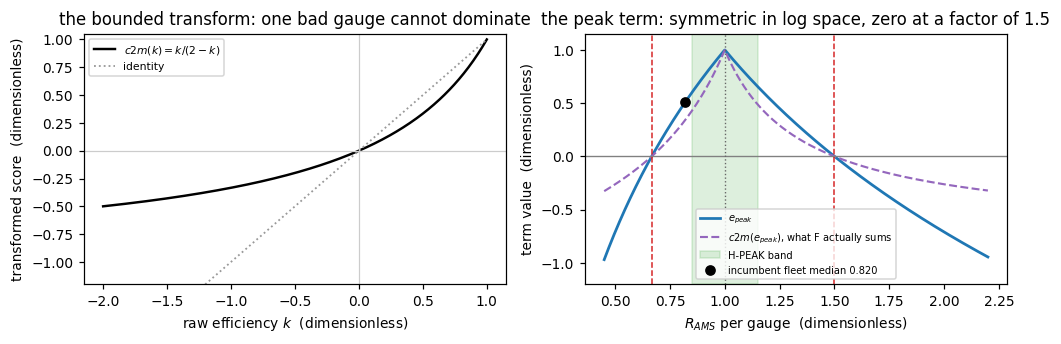

In [25]:
print(f'incumbent weights (KGE, logKGE, recession)      = {CV.W_SET_INCUMBENT}')
print(f'refit weights     (KGE, logKGE, recession, peak) = {CV.W_SET_PEAK}   sum = '
      f'{sum(CV.W_SET_PEAK):.2f}')
print(f'peak scale ln(1.5) = {CV.PEAK_SCALE:.6f}   recession scale ln(2) = {CV.REC_SCALE:.6f}')
print(f'a gauge needs >= {CV.AMS_MIN_DAYS} valid days in a calendar year to contribute a peak term')
for R in (1.0, 1.15, 1.5, 0.85, 0.82, 2 / 3):
    ep = float(CV.peak_efficiency(np.array([R]))[0])
    print(f'   R_AMS = {R:.3f}  ->  e_peak = {ep:+.4f}  ->  c2m(e_peak) = '
          f'{float(CV.c2m(np.array([ep]))[0]):+.4f}')

fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.2))
kk = np.linspace(-2.0, 1.0, 400)
ax[0].plot(kk, CV.c2m(kk), 'k-', lw=1.6, label='$c2m(k) = k/(2-k)$')
ax[0].plot(kk, kk, ':', color='0.6', lw=1.2, label='identity')
ax[0].axhline(0, color='0.8', lw=0.8); ax[0].axvline(0, color='0.8', lw=0.8)
ax[0].set_xlabel('raw efficiency $k$  (dimensionless)')
ax[0].set_ylabel('transformed score  (dimensionless)')
ax[0].set_ylim(-1.2, 1.05)
ax[0].set_title('the bounded transform: one bad gauge cannot dominate')
ax[0].legend(fontsize=7)

RR = np.linspace(0.45, 2.2, 500)
ax[1].plot(RR, CV.peak_efficiency(RR), color='tab:blue', lw=1.8, label='$e_{peak}$')
ax[1].plot(RR, CV.c2m(CV.peak_efficiency(RR)), color='tab:purple', lw=1.4, ls='--',
           label='$c2m(e_{peak})$, what F actually sums')
ax[1].axhline(0, color='0.5', lw=0.9)
ax[1].axvline(1.0, color='0.4', ls=':', lw=0.9)
for xv in (1 / 1.5, 1.5):
    ax[1].axvline(xv, color='tab:red', ls='--', lw=1.0)
ax[1].axvspan(*PEAK_BAND, color='tab:green', alpha=0.16, label='H-PEAK band')
ax[1].plot([FLEET['R_AMS']], [float(CV.peak_efficiency(np.array([FLEET['R_AMS']]))[0])], 'ko',
           ms=6, label=f'incumbent fleet median {FLEET["R_AMS"]:.3f}')
ax[1].set_xlabel('$R_{AMS}$ per gauge  (dimensionless)')
ax[1].set_ylabel('term value  (dimensionless)')
ax[1].set_ylim(-1.2, 1.15)
ax[1].set_title('the peak term: symmetric in log space, zero at a factor of 1.5')
ax[1].legend(fontsize=6.5, loc='lower center')
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the Mathevet bounded transform $c2m(k) = k/(2-k)$ (black) against the
identity (dotted), both dimensionless - it is nearly the identity for good scores and compresses
hard for bad ones. *Right:* the registered peak term $e_{\text{peak}}$ (blue) and its transformed
value (purple dashed) as a function of a gauge's annual-maximum ratio, with vertical red dashes at
the factors 1/1.5 and 1.5 where the term reaches zero, the acceptance band shaded, and the
incumbent's fleet median marked.

**What it shows.** The term is exactly symmetric about $R = 1$ on a log axis: it scores exactly 0 at
0.667 and at 1.5, $+0.599$ at the lower band edge 0.85 and $+0.655$ at the upper edge 1.15. At the
incumbent's full-record fleet median of 0.820 it scores $+0.511$; at the *calibration-window* median
the search actually saw (0.648) it is negative. The
$c2m$ curve shows the objective compresses negative scores rather than letting one hopeless gauge
set the fleet mean.

**What it means.** The instrument added to the objective is a well-behaved, direction-neutral
measure of peak error whose scale (a factor of 1.5 scores zero) was fixed in advance and mirrors the
recession term's existing "a factor of two out scores zero". Nothing about its construction favours
a particular repair. That matters for §6.7: when the search does something physically
indefensible to satisfy this term, the fault cannot be laid on a badly shaped penalty.

## 6.2 - The step without which the comparison is invalid: re-scoring on the incumbent scale

Here is the trap the pre-registration was written to avoid. **Adding a term changes the objective**,
so the refit's own $F$ is a *different quantity* from the incumbent's $F$. Comparing 0.2167 with
0.2593 and concluding "the refit is worse" would be as meaningless as comparing a mark out of 100
with a mark out of 120. `docs/33` §3.5 therefore fixes the procedure in advance:

> evaluate the blend at the **incumbent weights** $(0.40, 0.40, 0.20)$ on the refit's fitted
> parameter set, and apply the $\pm 0.02$ criterion to *that* number. The refit's native $F$ is
> reported alongside and is explicitly labelled incomparable.

**Registering that in advance is what stops a session picking whichever scale flatters.**

Doing it does **not** require re-running the model. Each DDS archive stores, for every one of its
1,000 evaluations, the *per-gauge objective terms* of that evaluation: `arch_k1` (KGE), `arch_k2`
(KGE on log flow), `arch_ks` (the simulated recession constant, days) and `arch_ra` (the per-gauge
annual-maximum ratio). The only observed-side ingredient, the observed recession constant on the
calibration window, is recomputed from the input bundle. So both scales are formed from disk in
seconds:

$$e_{\text{rec}}(g) = 1 - \frac{\bigl|\ln\bigl(k^{\text{sim}}_g / k^{\text{obs}}_g\bigr)\bigr|}{\ln 2},
\qquad
F_{\text{native}} = \mathrm{blend}\bigl(\cdot\,;\, w = (0.34,0.34,0.17,0.15)\bigr), \qquad
F_{\text{incumbent}} = \mathrm{blend}\bigl(\cdot\,;\, w = (0.40,0.40,0.20)\bigr)$$

with $k$ in days and every score dimensionless. **The reproduction check comes first**: if
$F_{\text{native}}$ recomputed here does not match the $F$ the search stored, nothing downstream can
be trusted.

In [26]:
# observed-side quantities on the CAL window, from the input bundle (no engine run)
D_SC = pd.date_range('2009-01-01', '2018-12-31', freq='D')
keep = np.isin(pd.DatetimeIndex(np.asarray(DIS['dates'], dtype='datetime64[ns]')), D_SC)
JP = np.flatnonzero(DIS['is_calibration_safe'])
QOBS_CAL_SRC = np.where(DIS['q_valid'][keep][:, JP],
                        DIS['q_m3s'][keep][:, JP].astype(np.float64), np.nan)
yrs = D_SC.year.to_numpy()
M_CAL = np.isin(yrs, CV.CAL_YEARS)
K_OBS_CAL, NSEG_OBS = CV.recession_fleet(QOBS_CAL_SRC[M_CAL])
AMS_OBS_CAL, _ = CV.ams_fleet(QOBS_CAL_SRC[M_CAL], yrs[M_CAL])
print(f'calibration window {CV.CAL_YEARS}, {int(M_CAL.sum())} days')
print(f'observed recession constants available at {int(np.isfinite(K_OBS_CAL).sum())} of {NG} '
      f'gauges, median {np.nanmedian(K_OBS_CAL):.3f} d')
print(f'observed CAL annual maxima usable at {int(np.isfinite(AMS_OBS_CAL).sum())} of '
      f'{AMS_OBS_CAL.size} gauge-years')

# search-vector bounds, in the transformed space the search works in
LOB, HIB = list(CV.LO), list(CV.HI)
for nm in CV.REG_PARAMS:
    i = CV.NAMES.index(nm)
    for _ in range(2):
        LOB.append(CV.LO[i]); HIB.append(CV.HI[i])
for nm in CV.SOIL_PARAMS:
    i = CV.NAMES.index(nm)
    for _ in range(2):
        LOB.append(CV.LO[i]); HIB.append(CV.HI[i])
LOB, HIB = np.array(LOB), np.array(HIB)

REFIT = {}
for tag, key in [('20260907', 'refit_07'), ('20260908', 'refit_08')]:
    z = np.load(NEED[key], allow_pickle=True)
    ib = int(np.nanargmax(z['arch_f']))
    k1 = z['arch_k1'][ib].astype(np.float64); k2 = z['arch_k2'][ib].astype(np.float64)
    ks = z['arch_ks'][ib].astype(np.float64); ra = z['arch_ra'][ib].astype(np.float64)
    e_rec = CV.rec_efficiency(ks, K_OBS_CAL)
    e_pk = CV.peak_efficiency(ra)
    f_native = CV.blend(k1, k2, e_rec, w=CV.W_SET_PEAK, e_peak=e_pk, use_peak=True)
    f_inc = CV.blend(k1, k2, e_rec, w=CV.W_SET_INCUMBENT)
    x = z['x'].astype(np.float64)
    REFIT[tag] = dict(stored=float(z['f'][0]), native=f_native, inc=f_inc,
                      r_ams=float(np.nanmedian(ra)), n_ra=int(np.isfinite(ra).sum()),
                      pos=(x - LOB) / (HIB - LOB), names=[str(v) for v in z['names']],
                      val=CV.inv(x[:len(CV.NAMES)], CV.IS_LOG),
                      wall=float(z['wall_s'][0]) / 60.0, hist=z['hist'],
                      arch_f=z['arch_f'], arch_ra=z['arch_ra'], arch_k1=z['arch_k1'],
                      arch_k2=z['arch_k2'], arch_ks=z['arch_ks'])
    rel = abs(f_native - REFIT[tag]['stored']) / REFIT[tag]['stored']
    print(f'\nseed {tag}: budget {int(z["budget"][0])}, wall {REFIT[tag]["wall"]:.0f} min, '
          f'peak term defined at {REFIT[tag]["n_ra"]} of {NG} gauges')
    print(f'   stored F (native scale)     {REFIT[tag]["stored"]:.10f}')
    print(f'   recomputed F (native scale) {f_native:.10f}   relative difference {rel:.2e}')
    assert rel < 1e-8, 'the native-scale reproduction must hold before anything is interpreted'
    print(f'   RE-SCORED on the incumbent (0.40, 0.40, 0.20) scale: {f_inc:.7f}')

F_MEAN = float(np.mean([REFIT[t]['inc'] for t in REFIT]))
DELTA = F_MEAN - F_H2E
print(f'\nmean incumbent-scale F over the two registered seeds: {F_MEAN:.7f}')
print(f'incumbent H2E                                       : {F_H2E:.7f}')
print(f'difference {DELTA:+.5f}  against a budget of +/-{F_BUDGET}  '
      f'-> {abs(DELTA)/F_BUDGET:.2f}x the budget  -> CONDITION 2 '
      f'{"PASSES" if abs(DELTA) <= F_BUDGET else "FAILS"}')
print(f'\nfor comparison, the NATIVE-scale values {REFIT["20260907"]["native"]:.5f} and '
      f'{REFIT["20260908"]["native"]:.5f} are a DIFFERENT quantity and must not be '
      f'compared with {F_H2E:.5f}')

calibration window [2012, 2013, 2014], 1096 days
observed recession constants available at 57 of 63 gauges, median 10.402 d
observed CAL annual maxima usable at 124 of 189 gauge-years

seed 20260907: budget 1000, wall 155 min, peak term defined at 51 of 63 gauges
   stored F (native scale)     0.2166895543
   recomputed F (native scale) 0.2166895545   relative difference 6.89e-10
   RE-SCORED on the incumbent (0.40, 0.40, 0.20) scale: 0.2248895

seed 20260908: budget 1000, wall 156 min, peak term defined at 51 of 63 gauges
   stored F (native scale)     0.2268935912
   recomputed F (native scale) 0.2268935911   relative difference 3.38e-10
   RE-SCORED on the incumbent (0.40, 0.40, 0.20) scale: 0.2298409

mean incumbent-scale F over the two registered seeds: 0.2273652
incumbent H2E                                       : 0.2593059
difference -0.03194  against a budget of +/-0.02  -> 1.60x the budget  -> CONDITION 2 FAILS

for comparison, the NATIVE-scale values 0.21669 and 0.22689 are 

**What that established, before any figure.** The recomputed native-scale $F$ reproduces what each
search stored to a relative $7\times10^{-10}$ and $3\times10^{-10}$ - the float32 precision of the
archived per-gauge terms - so the re-scoring machinery is validated against the search's own output
before being used on a new question. (`docs/33` §8 describes this reproduction as "exact"; it is
exact to float32, which is what those two relative differences are. §8 records the wording.)

On the **incumbent** scale the two seeds score **0.2248895** and **0.2298409**, mean
**0.2273652**, against the incumbent's **0.2593059**: a shortfall of **-0.03194**, which is
**1.60x** the pre-registered budget of 0.02. **Condition 2 fails.**

### 6.2.1 - The three conditions, side by side

`docs/33` §3.5 requires **all three** of these:

1. **the refuted signature comes inside its bound** - fleet-median $R_{\mathrm{AMS}} \in [0.85,1.15]$;
2. **no material cost in $F$** - mean incumbent-scale $F$ within 0.02 of 0.25931;
3. **no NEW parameter rails** - the refit's railed set must be a *subset* of the incumbent's
   $\{$`k_sup@global`, `k_int_frac@global`, `wm_mult@R2`$\}$.

A parameter is **railed** when its fitted value sits within 5 % of the end of its own allowed range,
measured in the transformed (log where applicable) space the search actually explores:

$$\mathrm{pos}(p) = \frac{x_p - \mathrm{lo}_p}{\mathrm{hi}_p - \mathrm{lo}_p} \in [0,1],
\qquad \text{railed} \iff \mathrm{pos} < 0.05 \ \text{ or } \ \mathrm{pos} > 0.95$$

dimensionless. Inputs: each archive's fitted vector `x` (18 dimensions) and the bounds from
`calib_v2`. The incumbent's own positions come from `sim_calibrated_v2/parameters_H2E.csv`.

condition                             required                            seed 20260907  seed 20260908  verdict
1 - signature inside its bound        R_AMS in [0.85, 1.15]                      0.9364         0.9970  PASS
2 - no material cost in F             mean incumbent-scale F +/-0.02            0.22489        0.22984  FAIL  (mean 0.22737, delta -0.0319)
3 - no NEW rails                      railed set within the incumbent set      see below      see below  FAIL

   incumbent H2E railed set : ['k_int_frac@global', 'k_sup@global', 'wm_mult@R2']
   seed 20260907 railed set: ['k_int_frac@global', 'kc_mult@global']
      of which NEW (not railed in the incumbent): ['kc_mult@global']
   seed 20260908 railed set: ['k_int_frac@global', 'lai_mult@global']
      of which NEW (not railed in the incumbent): ['lai_mult@global']

all three required -> refit IS REJECTED: 1 of 3 conditions met


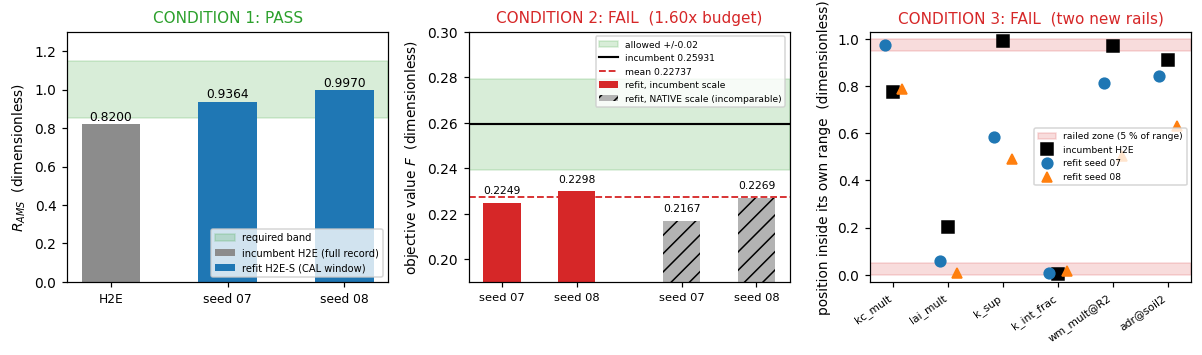

In [27]:
print(f'{"condition":<38}{"required":<34}{"seed 20260907":>15}{"seed 20260908":>15}  verdict')
c1 = [REFIT[t]['r_ams'] for t in ('20260907', '20260908')]
ok1 = all(PEAK_BAND[0] <= v <= PEAK_BAND[1] for v in c1)
print(f'{"1 - signature inside its bound":<38}{"R_AMS in [0.85, 1.15]":<34}'
      f'{c1[0]:15.4f}{c1[1]:15.4f}  {"PASS" if ok1 else "FAIL"}')
ok2 = abs(DELTA) <= F_BUDGET
print(f'{"2 - no material cost in F":<38}{"mean incumbent-scale F +/-0.02":<34}'
      f'{REFIT["20260907"]["inc"]:15.5f}{REFIT["20260908"]["inc"]:15.5f}  '
      f'{"PASS" if ok2 else "FAIL"}  (mean {F_MEAN:.5f}, delta {DELTA:+.4f})')
newrails = {}
for t in REFIT:
    rl = {n for n, p in zip(REFIT[t]['names'], REFIT[t]['pos']) if p < RAIL or p > 1 - RAIL}
    newrails[t] = rl - H2E_RAILED
ok3 = all(len(v) == 0 for v in newrails.values())
print(f'{"3 - no NEW rails":<38}{"railed set within the incumbent set":<34}'
      f'{"see below":>15}{"see below":>15}  {"PASS" if ok3 else "FAIL"}')
print(f'\n   incumbent H2E railed set : {sorted(H2E_RAILED)}')
for t in REFIT:
    rl = sorted({n for n, p in zip(REFIT[t]['names'], REFIT[t]['pos'])
                 if p < RAIL or p > 1 - RAIL})
    print(f'   seed {t} railed set: {rl}')
    print(f'      of which NEW (not railed in the incumbent): {sorted(newrails[t])}')
print(f'\nall three required -> refit '
      f'{"SUCCEEDS" if (ok1 and ok2 and ok3) else "IS REJECTED"}: '
      f'{sum([ok1, ok2, ok3])} of 3 conditions met')

fig, ax = plt.subplots(1, 3, figsize=(11.0, 3.3))
ax[0].axhspan(*PEAK_BAND, color='tab:green', alpha=0.18, label='required band')
ax[0].bar([0], [FLEET['R_AMS']], color='0.55', width=0.5, label='incumbent H2E (full record)')
ax[0].bar([1, 2], c1, color='tab:blue', width=0.5, label='refit H2E-S (CAL window)')
for x, v in zip([0, 1, 2], [FLEET['R_AMS']] + c1):
    ax[0].text(x, v + 0.02, f'{v:.4f}', ha='center', fontsize=8)
ax[0].set_xticks([0, 1, 2]); ax[0].set_xticklabels(['H2E', 'seed 07', 'seed 08'], fontsize=8)
ax[0].set_ylabel('$R_{AMS}$  (dimensionless)')
ax[0].set_ylim(0, 1.3)
ax[0].set_title('CONDITION 1: PASS', color='tab:green', fontsize=10)
ax[0].legend(fontsize=6.5, loc='lower right')

ax[1].axhspan(F_H2E - F_BUDGET, F_H2E + F_BUDGET, color='tab:green', alpha=0.18,
              label=f'allowed +/-{F_BUDGET}')
ax[1].axhline(F_H2E, color='k', lw=1.4, label=f'incumbent {F_H2E:.5f}')
ax[1].bar([0, 1], [REFIT[t]['inc'] for t in ('20260907', '20260908')], color='tab:red',
          width=0.5, label='refit, incumbent scale')
ax[1].bar([2.4, 3.4], [REFIT[t]['native'] for t in ('20260907', '20260908')], color='0.7',
          width=0.5, hatch='//', label='refit, NATIVE scale (incomparable)')
ax[1].axhline(F_MEAN, color='tab:red', ls='--', lw=1.2, label=f'mean {F_MEAN:.5f}')
for x, v in zip([0, 1, 2.4, 3.4], [REFIT['20260907']['inc'], REFIT['20260908']['inc'],
                                   REFIT['20260907']['native'], REFIT['20260908']['native']]):
    ax[1].text(x, v + 0.004, f'{v:.4f}', ha='center', fontsize=7)
ax[1].set_xticks([0, 1, 2.4, 3.4])
ax[1].set_xticklabels(['seed 07', 'seed 08', 'seed 07', 'seed 08'], fontsize=7.5)
ax[1].set_ylabel('objective value $F$  (dimensionless)')
ax[1].set_ylim(0.19, 0.30)
ax[1].set_title(f'CONDITION 2: FAIL  ({abs(DELTA)/F_BUDGET:.2f}x budget)', color='tab:red',
                fontsize=10)
ax[1].legend(fontsize=6, loc='upper right')

nm_all = REFIT['20260907']['names']
show = [k for k, n in enumerate(nm_all) if n in
        ('kc_mult@global', 'lai_mult@global', 'k_int_frac@global', 'k_sup@global',
         'wm_mult@R2', 'adr@soil2')]
SCOPE_ALIAS = {'global': 'global', 'R1': 'R1', 'R2': 'R2',
               'soil-medium': 'soil2', 'soil-fine': 'soil3'}
h2e_pos = {f'{r["parameter"]}@{SCOPE_ALIAS[r["scope"]]}': r['pos']
           for _, r in PARH2E.iterrows()}
assert set(h2e_pos) == set(nm_all), 'the incumbent table and the archive must name one space'
ax[2].axhspan(0, RAIL, color='tab:red', alpha=0.16, label='railed zone (5 % of range)')
ax[2].axhspan(1 - RAIL, 1.0, color='tab:red', alpha=0.16)
xs = np.arange(len(show))
ax[2].plot(xs, [h2e_pos.get(nm_all[k], np.nan) for k in show], 'ks', ms=8,
           label='incumbent H2E')
ax[2].plot(xs - 0.16, [REFIT['20260907']['pos'][k] for k in show], 'o', color='tab:blue',
           ms=7, label='refit seed 07')
ax[2].plot(xs + 0.16, [REFIT['20260908']['pos'][k] for k in show], '^', color='tab:orange',
           ms=7, label='refit seed 08')
ax[2].set_xticks(xs)
ax[2].set_xticklabels([nm_all[k].replace('@global', '') for k in show], rotation=35,
                      ha='right', fontsize=7)
ax[2].set_ylabel('position inside its own range  (dimensionless)')
ax[2].set_ylim(-0.03, 1.03)
ax[2].set_title('CONDITION 3: FAIL  (two new rails)', color='tab:red', fontsize=10)
ax[2].legend(fontsize=6, loc='center right')
plt.tight_layout(); plt.show()

**What is plotted.** The three pre-registered conditions, one panel each. *Left:* the fleet-median
annual-maximum ratio for the incumbent (grey, full record) and for each refit seed (blue,
calibration window), with the required band shaded green. *Middle:* the objective value - red bars
are the refit re-scored on the **incumbent** weight scale, hatched grey bars are the refit's own
**native** scale (shown to make the point that they are a different quantity), the black line is the
incumbent and the green band is the $\pm 0.02$ allowance. *Right:* the position of six parameters
inside their own allowed range, dimensionless from 0 to 1, with the railed zones shaded red -
squares are the incumbent, circles and triangles the two refit seeds.

**What it shows.** **Condition 1 passes, decisively**: the peak term moved $R_{\mathrm{AMS}}$ from
0.820 to **0.9364** and **0.9970**, comfortably inside the band. **Condition 2 fails**: the
incumbent-scale mean is 0.22737 against 0.25931, a shortfall of $-0.0319$, which is **1.60x** the
budget - and note that on its native scale (0.2167, 0.2269) the refit looks worse still, so no
choice of scale rescues it. **Condition 3 fails**: seed 07 puts `kc_mult` at position **0.975** and
seed 08 puts `lai_mult` at **0.006**, neither of which is in the incumbent's railed set. Both seeds
also rail `k_int_frac`, but that one was *already* railed in the incumbent and so is permitted.

**What it means.** The peak deficit **is** fixable by parameters - that is the finding of condition
1, and it rules out "the model simply cannot make a big flood" as an explanation. What is not
possible is fixing it *within the constraints that make the model defensible*. Two of three
conditions fail, so by the rule quoted in §2 the refit is **rejected** and the outcome is recorded
as *"the signature and the objective are in conflict"* - itself a reportable finding about model
structure, and one that explicitly **licenses no further refit**. §6.4 asks what the search did with
those two rails, because the *mechanism* of the failure is more informative than the failure.

## 6.3 - Was the whole search region infeasible, or just its optimum?

Conditions 1 and 2 are in tension at the *optimum*, but that alone does not prove they cannot be
satisfied together somewhere else. The archives let us ask directly: every one of the 2,000
evaluations the two searches performed carries its per-gauge terms, so each can be scored on
**both** axes at once -

$$\text{for each evaluation } i:\quad
\bigl(\;\operatorname{median}_g R_{\mathrm{AMS}}(g)\big|_i \;,\;\;
F_{\text{incumbent}}\big|_i \;\bigr)$$

- and plotted as a trade-off cloud, with the pre-registered band on one axis and the $F$ floor
  $0.25931 - 0.02 = 0.23931$ on the other. A point in the upper-middle region satisfies conditions
  1 and 2 simultaneously. 2,000 blend evaluations, no engine, a few seconds. All axes
  dimensionless.

**One caveat stated before the figure, not after:** the $R_{\mathrm{AMS}}$ in the archive is
computed on the **calibration window 2012-2014**, because that is the window the objective scores,
whereas the pre-registered *gate* is defined on the full 2009-2018 record. The two differ - the
incumbent's calibration-window value is 0.6482 (`docs/agents/journal_refit-launch.md`) against its
full-record 0.8200 - and §5.4's recomputation of that same window from the committed peaks table
gives 0.6478 rather than 0.6482, a 0.0004 gap recorded as §8.3 item 5. So this figure, and condition 1 above, are calibration-window statements. §8
records that as an open issue.

seed 20260907: 1000 evaluations
   R_AMS inside the band          :  663  (66.3 %)
   incumbent-scale F >= 0.23931 :    0
   BOTH at once                   :    0
   best incumbent-scale F anywhere in this archive: 0.22619
   Spearman(median R_AMS, incumbent F) = -0.019


seed 20260908: 1000 evaluations
   R_AMS inside the band          :  826  (82.6 %)
   incumbent-scale F >= 0.23931 :    0
   BOTH at once                   :    0
   best incumbent-scale F anywhere in this archive: 0.23006
   Spearman(median R_AMS, incumbent F) = -0.272


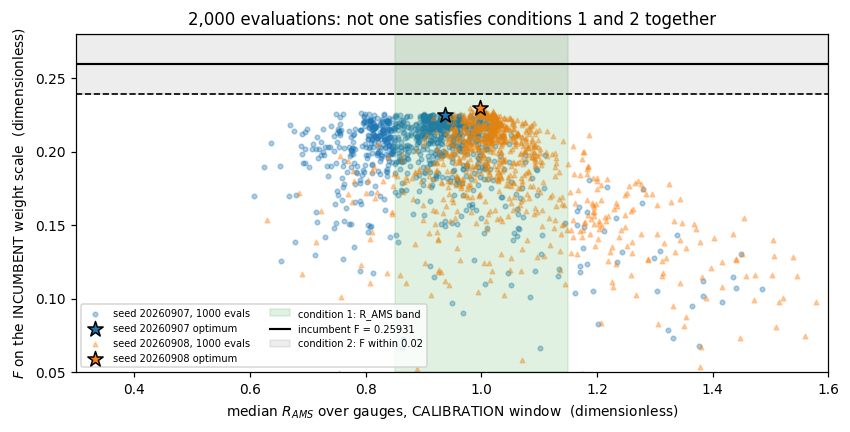

In [28]:
FR = {}
for t in REFIT:
    z = REFIT[t]
    n = z['arch_f'].size
    finc = np.full(n, np.nan); ram = np.full(n, np.nan)
    for i in range(n):
        e_rec = CV.rec_efficiency(z['arch_ks'][i].astype(np.float64), K_OBS_CAL)
        finc[i] = CV.blend(z['arch_k1'][i].astype(np.float64),
                           z['arch_k2'][i].astype(np.float64), e_rec,
                           w=CV.W_SET_INCUMBENT)
        ram[i] = np.nanmedian(z['arch_ra'][i].astype(np.float64))
    FR[t] = (ram, finc)
    inb = (ram >= PEAK_BAND[0]) & (ram <= PEAK_BAND[1])
    floor = F_H2E - F_BUDGET
    print(f'seed {t}: {n} evaluations')
    print(f'   R_AMS inside the band          : {int(inb.sum()):4d}  ({100*inb.mean():.1f} %)')
    print(f'   incumbent-scale F >= {floor:.5f} : {int((finc >= floor).sum()):4d}')
    print(f'   BOTH at once                   : {int((inb & (finc >= floor)).sum()):4d}')
    print(f'   best incumbent-scale F anywhere in this archive: {np.nanmax(finc):.5f}')
    print(f'   Spearman(median R_AMS, incumbent F) = '
          f'{stats.spearmanr(ram[np.isfinite(finc)], finc[np.isfinite(finc)]).statistic:+.3f}')

fig, ax = plt.subplots(figsize=(7.8, 4.0))
for t, col, mk in (('20260907', 'tab:blue', 'o'), ('20260908', 'tab:orange', '^')):
    ram, finc = FR[t]
    ax.scatter(ram, finc, s=9, alpha=0.35, color=col, marker=mk, label=f'seed {t}, 1000 evals')
    ax.scatter([REFIT[t]['r_ams']], [REFIT[t]['inc']], s=110, color=col, marker='*',
               edgecolor='k', zorder=5, label=f'seed {t} optimum')
ax.axvspan(*PEAK_BAND, color='tab:green', alpha=0.14, label='condition 1: R_AMS band')
ax.axhline(F_H2E, color='k', lw=1.4, label=f'incumbent F = {F_H2E:.5f}')
ax.axhspan(F_H2E - F_BUDGET, F_H2E + F_BUDGET, color='k', alpha=0.07,
           label='condition 2: F within 0.02')
ax.axhline(F_H2E - F_BUDGET, color='k', ls='--', lw=1.1)
ax.set_xlabel('median $R_{AMS}$ over gauges, CALIBRATION window  (dimensionless)')
ax.set_ylabel('$F$ on the INCUMBENT weight scale  (dimensionless)')
ax.set_xlim(0.3, 1.6); ax.set_ylim(0.05, 0.28)
ax.set_title('2,000 evaluations: not one satisfies conditions 1 and 2 together')
ax.legend(fontsize=6.5, loc='lower left', ncol=2)
plt.tight_layout(); plt.show()

**What is plotted.** Every evaluation of both searches as one point: its calibration-window median
annual-maximum ratio on the x-axis against its objective value **re-scored on the incumbent weight
scale** on the y-axis, blue circles for seed 20260907 and orange triangles for seed 20260908, with
each search's chosen optimum as a star. The green vertical band is condition 1; the horizontal grey
band and its dashed lower edge are condition 2, around the incumbent's black line. Dimensionless
throughout.

**What it shows.** The cloud is nowhere near the region where both conditions hold. **663 of 1,000**
evaluations in seed 07 and **826 of 1,000** in seed 08 land inside the $R_{\mathrm{AMS}}$ band, so
condition 1 is easy for this search - but the best incumbent-scale $F$ reached anywhere in either
archive is **0.22619** and **0.23006**, both below the 0.23931 floor. **Zero of 2,000 evaluations
satisfy conditions 1 and 2 simultaneously.** The rank correlation between the two axes is weak
($-0.02$ and $-0.27$), so this is not a smooth frontier the search failed to climb: the whole
visited region simply sits below the $F$ floor.

**What it means.** The rejection is not an artefact of DDS stopping in a bad place. Within the
2,000 points these two registered searches visited, there is **no** parameter vector that both
brings the peaks inside the band and keeps the discharge objective within its budget. That is
stronger evidence for "conflict" than the two optima alone provide. It is not a proof about the
whole parameter box - a search that spends its budget chasing the peak term does not sample the
box uniformly, and the incumbent itself sits at $F = 0.2593$ with peaks *outside* the band - but it
is the strongest statement the committed artifacts can support, and it points the same way as the
optima.

## 6.4 - How the refit bought its peaks: it deleted the canopy

Condition 3 named two new rails. This section says what they *are*, because the physical reading is
the whole lesson.

Two more definitions, needed here for the first time:

- **PET** (potential evapotranspiration, mm d$^{-1}$) is the atmospheric *demand* for water: how
  much would evaporate and transpire if water were freely available. **Actual ET** is what the soil
  and vegetation can actually supply, which is PET reduced by whatever the soil moisture allows. The
  model scales PET per land class by a crop coefficient $k_c$, and `kc_mult` is a global multiplier
  on all of them.
- **Canopy interception** is rainfall caught by leaves and stems that never reaches the soil at all:
  it evaporates from the plant surface. In this model it is controlled by the leaf area index
  (leaf area per unit ground area, m$^2$ m$^{-2}$), scaled globally by `lai_mult`. Interception both
  **removes** water and **delays** what gets through, so it is the model's main buffer between a
  storm and the soil surface.

Now look at what each seed did.

parameter              H2E value  H2E pos    seed07 value     pos    seed08 value     pos
adr@global                0.0076   0.4253          0.0149  0.5310          0.0528  0.7283
fint@global               0.7540   0.7823          0.5995  0.6106          0.5352  0.5392
b@global                  0.3567   0.4484          0.1763  0.2876          0.6000  0.5671
wm_mult@global            0.3891   0.1392          1.1575  0.4822          1.1944  0.4921
kc_mult@global            1.6625   0.7750          1.9630  0.9753          1.6807  0.7871 <-- NEW RAIL
lai_mult@global           1.0036   0.2007          0.3011  0.0602          0.0292  0.0058 <-- NEW RAIL
k_sup@global             19.1993   0.9911          2.9212  0.5823          1.9017  0.4891
k_int_frac@global         0.0201   0.0019          0.0206  0.0079          0.0211  0.0143
k_bas@global             42.9740   0.4493         20.9689  0.2994         84.3976  0.5903
celerity@global           0.3266   0.4283          0.3636  0.4528         

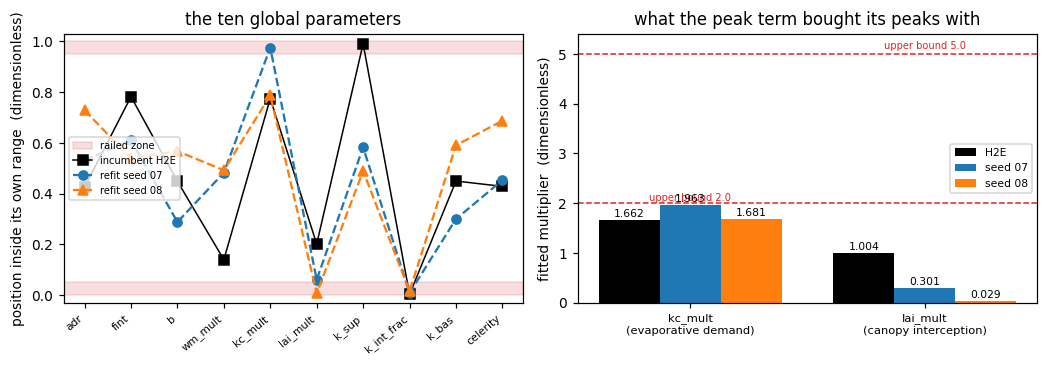

In [29]:
names = REFIT['20260907']['names']
print(f'{"parameter":<20}{"H2E value":>12}{"H2E pos":>9}   '
      f'{"seed07 value":>13}{"pos":>8}   {"seed08 value":>13}{"pos":>8}')
h2e_val = {f'{r["parameter"]}@{SCOPE_ALIAS[r["scope"]]}': r['value']
           for _, r in PARH2E.iterrows()}
h2e_pos2 = h2e_pos
for k, nm in enumerate(names[:len(CV.NAMES)]):
    hv = h2e_val.get(nm, np.nan)
    hp = h2e_pos2.get(nm, np.nan)
    v7, p7 = REFIT['20260907']['val'][k], REFIT['20260907']['pos'][k]
    v8, p8 = REFIT['20260908']['val'][k], REFIT['20260908']['pos'][k]
    star = ' <-- NEW RAIL' if ((p7 < RAIL or p7 > 1 - RAIL or p8 < RAIL or p8 > 1 - RAIL)
                               and nm not in H2E_RAILED) else ''
    print(f'{nm:<20}{hv:12.4f}{hp:9.4f}   {v7:13.4f}{p7:8.4f}   {v8:13.4f}{p8:8.4f}{star}')
print(f'\nkc_mult range {CV.RAW_LO[4]:.2f} - {CV.RAW_HI[4]:.2f} (a multiplier on every crop '
      f'coefficient)')
print(f'lai_mult range {CV.RAW_LO[5]:.2f} - {CV.RAW_HI[5]:.2f} (a multiplier on every leaf '
      f'area index, i.e. on canopy interception)')
print(f'\nH2E existed to release kc_mult from its 2.00 rail (docs/29): it reached '
      f'{h2e_val["kc_mult@global"]:.4f} = position {h2e_pos2["kc_mult@global"]:.4f}')
print(f'the refit put it back: seed 07 {REFIT["20260907"]["val"][4]:.4f} = position '
      f'{REFIT["20260907"]["pos"][4]:.4f}')
print(f'and seed 08 emptied the canopy instead: lai_mult '
      f'{REFIT["20260908"]["val"][5]:.4f} = position {REFIT["20260908"]["pos"][5]:.4f} '
      f'(H2E: {h2e_val["lai_mult@global"]:.4f})')

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.4))
xs = np.arange(len(CV.NAMES))
ax[0].axhspan(0, RAIL, color='tab:red', alpha=0.15, label='railed zone')
ax[0].axhspan(1 - RAIL, 1.0, color='tab:red', alpha=0.15)
ax[0].plot(xs, [h2e_pos2.get(n, np.nan) for n in names[:10]],
           'ks-', ms=7, lw=1.0, label='incumbent H2E')
ax[0].plot(xs, REFIT['20260907']['pos'][:10], 'o--', color='tab:blue', ms=6,
           label='refit seed 07')
ax[0].plot(xs, REFIT['20260908']['pos'][:10], '^--', color='tab:orange', ms=6,
           label='refit seed 08')
ax[0].set_xticks(xs); ax[0].set_xticklabels(CV.NAMES, rotation=40, ha='right', fontsize=7)
ax[0].set_ylabel('position inside its own range  (dimensionless)')
ax[0].set_ylim(-0.03, 1.03)
ax[0].set_title('the ten global parameters')
ax[0].legend(fontsize=6.5, loc='center left')

lab = ['kc_mult\n(evaporative demand)', 'lai_mult\n(canopy interception)']
w = 0.26
for k, i in enumerate([4, 5]):
    ax[1].bar(k - w, h2e_val[CV.NAMES[i] + '@global'], width=w, color='k',
              label='H2E' if k == 0 else None)
    ax[1].bar(k, REFIT['20260907']['val'][i], width=w, color='tab:blue',
              label='seed 07' if k == 0 else None)
    ax[1].bar(k + w, REFIT['20260908']['val'][i], width=w, color='tab:orange',
              label='seed 08' if k == 0 else None)
    ax[1].axhline(CV.RAW_HI[i], color='tab:red', ls='--', lw=1.0)
    ax[1].text(k, CV.RAW_HI[i] * 1.02, f'upper bound {CV.RAW_HI[i]:.1f}', ha='center',
               fontsize=6.5, color='tab:red')
for k, i in enumerate([4, 5]):
    for off, v in zip([-w, 0, w], [h2e_val[CV.NAMES[i] + '@global'],
                                   REFIT['20260907']['val'][i], REFIT['20260908']['val'][i]]):
        ax[1].text(k + off, v + 0.06, f'{v:.3f}', ha='center', fontsize=7)
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(lab, fontsize=7.5)
ax[1].set_ylabel('fitted multiplier  (dimensionless)')
ax[1].set_ylim(0, 5.4)
ax[1].set_title('what the peak term bought its peaks with')
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the position of each of the ten global parameters inside its own
allowed range (0 = lower bound, 1 = upper bound, dimensionless) for the incumbent (black squares)
and for the two refit seeds; the red bands are the railed zones. *Right:* the fitted values of the
two parameters that control evaporative demand and canopy interception, with each parameter's upper
bound as a red dashed line.

**What it shows.** Seed 07 pushed `kc_mult` to **1.963** - position 0.975, i.e. hard against its
upper bound of 2.00 - while seed 08 pushed `lai_mult` down to **0.029** on a range that starts at
0, position 0.006, i.e. hard against its *lower* bound. The incumbent sits at `kc_mult` 1.662
(position 0.775) and `lai_mult` 1.004 (position 0.201). **Both** seeds cut the canopy: seed 07's
`lai_mult` fell to **0.301** - a 70 % reduction on the incumbent - without technically railing, so
the two seeds differ in which of the two knobs they railed, not in what they did physically. The
other eight parameters move comparatively little, and notably the incumbent's own rail
`k_sup@global` came *off* its bound (0.991 &rarr; 0.582 and 0.489).

**What it means.** This is the mechanism of the failure, and it is not subtle. **`lai_mult` near
zero means no canopy interception**: rainfall is delivered to the soil undelayed and unbuffered,
which is exactly how a *daily* model manufactures a bigger flood peak - remove the physical buffer
between the storm and the soil surface. **`kc_mult` near 2 means doubled evaporative demand**, which
then evaporates the surplus water back out over the following days so that the volume term
($\beta$, PBIAS) stays defensible. The two seeds found the same trick through different doors.

**In a basin whose land cover is dominated by forest and tree crops, setting canopy interception to
zero is not a defensible parameterisation.** It is a textbook compensating error: the model is made
right about one thing by being made wrong about another, in a way the objective cannot see. And it
**re-breaks what the incumbent existed to fix** - the whole point of the adopted configuration was
to release `kc_mult` from a rail at 2.00 by changing the evapotranspiration formulation, which it
achieved (1.662). Adding the peak term puts it straight back. **The two objectives want opposite
things from the same parameter.**

This is the fourth compensating error this project has caught (channel celerity absorbing floodplain
storage; $k_c$ absorbing a linear ET form; the subsurface reservoir constant absorbing an inverted
store ordering) - and the first one caught **before** it was adopted, which is precisely what the
pre-registration was for.

## 6.5 - The searches themselves: two seeds, one story

Finally, the search traces, so that "the refit failed" cannot be confused with "the refit did not
converge". Each archive stores `hist`, the best-so-far objective value after each evaluation on the
**native** scale (dimensionless, 1,000 entries). A search that was still improving steeply at
evaluation 1,000 would leave the conditions untested; one that flattened has spent its budget.

seed 20260907: native F 0.15673 -> 0.21669; gain over the last 100 evaluations +0.00047 (0.22 % of final)
seed 20260908: native F 0.15673 -> 0.22689; gain over the last 100 evaluations +0.00434 (1.91 % of final)


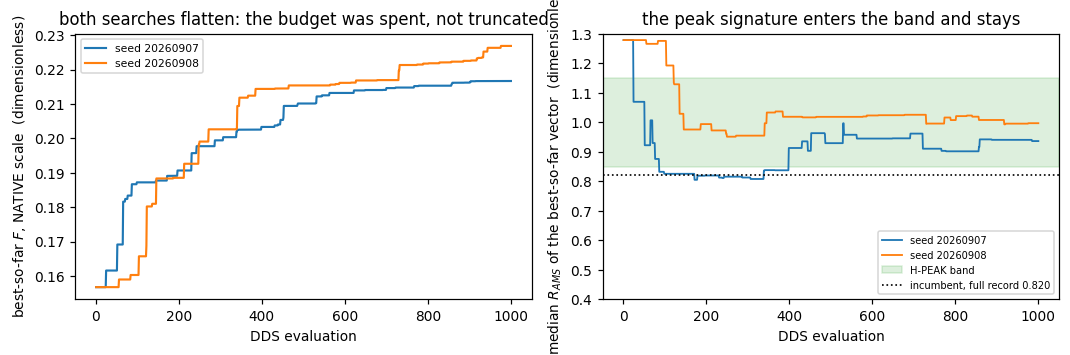

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.3))
for t, col in (('20260907', 'tab:blue'), ('20260908', 'tab:orange')):
    h = np.asarray(REFIT[t]['hist'], dtype=float)
    ax[0].plot(np.arange(1, h.size + 1), h, color=col, lw=1.4, label=f'seed {t}')
    last = h[-100:]
    print(f'seed {t}: native F {h[0]:.5f} -> {h[-1]:.5f}; gain over the last 100 '
          f'evaluations {h[-1]-h[-101]:+.5f} ({100*(h[-1]-h[-101])/h[-1]:.2f} % of final)')
ax[0].set_xlabel('DDS evaluation')
ax[0].set_ylabel('best-so-far $F$, NATIVE scale  (dimensionless)')
ax[0].set_title('both searches flatten: the budget was spent, not truncated')
ax[0].legend(fontsize=7)

for t, col, mk in (('20260907', 'tab:blue', 'o'), ('20260908', 'tab:orange', '^')):
    ram, _ = FR[t]
    h = np.asarray(REFIT[t]['arch_f'], dtype=float)
    take = np.array([int(np.nanargmax(h[:i + 1])) for i in range(h.size)])
    ax[1].plot(np.arange(1, h.size + 1), ram[take], color=col, lw=1.2, label=f'seed {t}')
ax[1].axhspan(*PEAK_BAND, color='tab:green', alpha=0.16, label='H-PEAK band')
ax[1].axhline(FLEET['R_AMS'], color='k', ls=':', lw=1.1,
              label=f'incumbent, full record {FLEET["R_AMS"]:.3f}')
ax[1].set_xlabel('DDS evaluation')
ax[1].set_ylabel('median $R_{AMS}$ of the best-so-far vector  (dimensionless)')
ax[1].set_ylim(0.4, 1.3)
ax[1].set_title('the peak signature enters the band and stays')
ax[1].legend(fontsize=6.5, loc='lower right')
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the best-so-far objective value on the refit's own native scale
against evaluation number, one line per seed. *Right:* the calibration-window median
annual-maximum ratio **of whichever vector was best so far**, against evaluation number, with the
acceptance band shaded and the incumbent's full-record value dotted. Dimensionless.

**What it shows.** Both traces rise steeply over the first few hundred evaluations and then
flatten - but not equally. Seed 07 gains **$+0.00047$** over its final hundred evaluations, 0.22 %
of its final value; seed 08 is still moving, gaining **$+0.00434$**, 1.91 % of its final value. Both
reach the acceptance band on the peak signature early and stay inside it.

**What it means, including the part that does not favour the conclusion.** Seed 07 has converged;
**seed 08 had not fully converged at evaluation 1,000**, and that must be said rather than glossed.
It does not change the verdict, for a reason that can be quantified: seed 08 is the *better* of the
two on the incumbent scale at 0.22984 and still needs $+0.0295$ - a **13 %** improvement - to reach
the 0.23931 floor, against a late-search trend of 1.9 % per hundred evaluations *on its own native
scale*, which is not the same axis. Nor is a larger budget available: `docs/33` §3.3 authorises 1,000
evaluations and two named seeds, and adding either after seeing the result is precisely what a
pre-registration forbids. Together with §6.3 - not one of the 2,000 visited points satisfies
conditions 1 and 2 together - the parameter route is closed on the evidence that exists: **within
what was registered, the peak deficit cannot be repaired by fitting.**

## 6.6 - The verdict, and what it licenses

| condition | required | seed 20260907 | seed 20260908 | verdict |
|---|---|---|---|---|
| 1 - signature inside its bound | $R_{\mathrm{AMS}} \in [0.85, 1.15]$ | **0.9364** | **0.9970** | **PASS** |
| 2 - no material cost in $F$ | mean incumbent-scale $F$ within 0.02 of 0.25931 | 0.22489 | 0.22984 | **FAIL** - mean 0.22737, $\Delta = -0.0319$, 1.60x the budget |
| 3 - no new rails | railed $\subseteq$ {`k_sup`, `k_int_frac`, `wm_mult@R2`} | `kc_mult` 0.975 | `lai_mult` 0.006 | **FAIL** - two new rails |

`docs/33` §3.5, quoted: *"Anything else is a failure of the refit, and it means the signature and
the objective are in conflict - the model cannot reproduce the driver signature without giving up
discharge skill or hitting a bound. That is itself reportable, and it is a real finding about model
structure, not a null. It does not license another refit."*

**So: no further refit.** The adopted configuration H2E remains the Phase C driver set, and Phase B
closes for the **second** time - the first close rested on parameter headroom being spent, this one
rests on a **measured conflict**. That is a complete answer to the question C2b asked, and it is a
more useful answer than a successful refit would have been, because a successful refit would have
delivered a model that was right about floods for an indefensible reason.

---

# 7 - The conclusion: the peak deficit is structural

§6 closed the parameter route. That leaves the question of *why* the model misses floods, and the
answer determines what - if anything - could be done about it. The adjudication is `docs/36`; this
section reproduces its decisive statistics from the committed event table and states the verdict at
the confidence the evidence supports.

Three candidate mechanisms were named in advance and tested.

## 7.1 - Mechanism 1: the daily time step - REFUTED

**The hypothesis.** The model runs on daily rainfall and daily water balance. A convective storm
lasts an hour; in a small steep catchment the resulting flood rises and falls inside a single day,
so a daily model must smear it into a daily mean and lose the peak. **This is the most widely cited
explanation for exactly this failure**, and it makes a sharp, testable prediction: the failure must
be **strongest in the smallest catchments**, because their response time is shortest relative to a
day.

**The test.** The fraction of a gauge's observed flood events with no simulated counterpart, against
catchment area:

$$\text{miss fraction}(g) = \frac{n^{\text{missed}}_g}{n^{\text{obs}}_g}, \qquad
\rho = \operatorname{Spearman}_g\bigl(\text{miss fraction}(g),\ \log_{10} A_g\bigr)$$

dimensionless against km$^2$. Inputs: `peakgap/per_gauge.csv`, 63 rows.

all 63 gauges     : Spearman rho = -0.0087, p = 0.946
excluding the outlet (62): Spearman rho = +0.0176, p = 0.892   (docs/36 / summary.json: +0.0176, p = 0.892, n = 62)
   the excluded gauge is 29037020 at 257,097 km2 with only 3 observed flood events in ten years

tercile  gauges        area range (km2)  events  miss fraction
small        21         68 -       288     853         0.7925
mid          20        298 -     1,464     802         0.8292
large        21      1,563 -    54,035     578         0.8408

prediction of the daily-step hypothesis: miss fraction DECREASES with area
measured: small 0.7925 -> large 0.8408  (INCREASES)  -> hypothesis REFUTED
event-level Mann-Whitney p on area, missed vs captured: 0.220 (no difference)


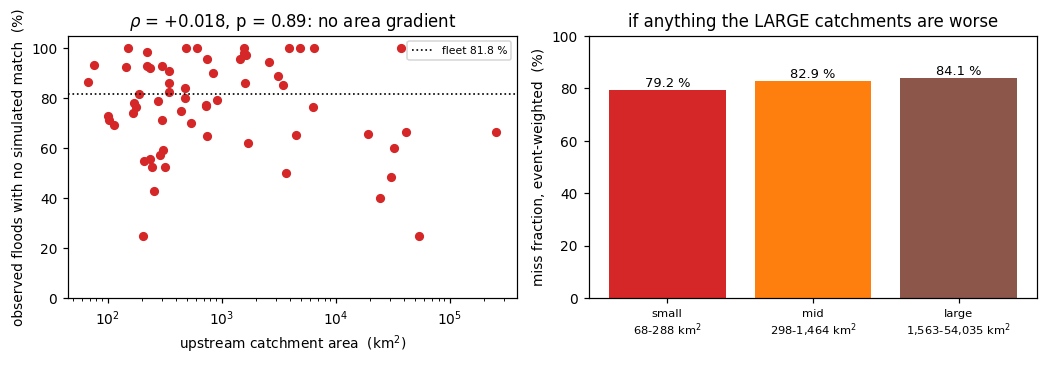

In [31]:
PGAP['miss_frac'] = PGAP['n_missed'] / PGAP['n_obs']
sub = PGAP[PGAP['area_km2'] < 1e5]      # docs/36 excludes the basin-outlet gauge, see below
rho_all, p_all = stats.spearmanr(np.log10(PGAP['area_km2']), PGAP['miss_frac'])
rho_62, p_62 = stats.spearmanr(np.log10(sub['area_km2']), sub['miss_frac'])
ref = GAP['a_area']['gauge_spearman_logA_vs_missfrac']
print(f'all {len(PGAP)} gauges     : Spearman rho = {rho_all:+.4f}, p = {p_all:.3f}')
print(f'excluding the outlet ({len(sub)}): Spearman rho = {rho_62:+.4f}, p = {p_62:.3f}   '
      f'(docs/36 / summary.json: {ref["rho"]:+.4f}, p = {ref["p"]:.3f}, n = {ref["n"]})')
out = PGAP[PGAP['area_km2'] >= 1e5]
print(f'   the excluded gauge is {out["gauge"].iloc[0]} at {out["area_km2"].iloc[0]:,.0f} km2 '
      f'with only {int(out["n_obs"].iloc[0])} observed flood events in ten years')
ter = pd.qcut(sub['area_km2'], 3, labels=['small', 'mid', 'large'])
print(f'\n{"tercile":<8}{"gauges":>7}{"area range (km2)":>24}{"events":>8}{"miss fraction":>15}')
TER = {}
for lab in ['small', 'mid', 'large']:
    x = sub[ter == lab]
    mf = x['n_missed'].sum() / x['n_obs'].sum()
    TER[lab] = mf
    print(f'{lab:<8}{len(x):7d}{x["area_km2"].min():11,.0f} - {x["area_km2"].max():9,.0f}'
          f'{int(x["n_obs"].sum()):8d}{mf:15.4f}')
print(f'\nprediction of the daily-step hypothesis: miss fraction DECREASES with area')
print(f'measured: small {TER["small"]:.4f} -> large {TER["large"]:.4f}  '
      f'({"INCREASES" if TER["large"] > TER["small"] else "decreases"})  -> hypothesis REFUTED')
print(f'event-level Mann-Whitney p on area, missed vs captured: '
      f'{GAP["a_area"]["event_level"]["mwu_p"]:.3f} (no difference)')

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.4))
ax[0].semilogx(PGAP['area_km2'], 100 * PGAP['miss_frac'], 'o', ms=5, color='tab:red')
ax[0].axhline(100 * n_missed / n_obs, color='k', ls=':', lw=1.1,
              label=f'fleet {100*n_missed/n_obs:.1f} %')
ax[0].set_xlabel('upstream catchment area  (km$^2$)')
ax[0].set_ylabel('observed floods with no simulated match  (%)')
ax[0].set_ylim(0, 105)
ax[0].set_title(f'$\\rho$ = {rho_62:+.3f}, p = {p_62:.2f}: no area gradient')
ax[0].legend(fontsize=7)
ax[1].bar(range(3), [100 * TER[k] for k in ['small', 'mid', 'large']],
          color=['tab:red', 'tab:orange', 'tab:brown'])
for k, lab in enumerate(['small', 'mid', 'large']):
    ax[1].text(k, 100 * TER[lab] + 1.2, f'{100*TER[lab]:.1f} %', ha='center', fontsize=8.5)
ax[1].set_xticks(range(3))
ax[1].set_xticklabels(['small\n68-288 km$^2$', 'mid\n298-1,464 km$^2$',
                       'large\n1,563-54,035 km$^2$'], fontsize=7.5)
ax[1].set_ylabel('miss fraction, event-weighted  (%)')
ax[1].set_ylim(0, 100)
ax[1].set_title('if anything the LARGE catchments are worse')
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* each gauge's percentage of observed floods with no simulated
counterpart against upstream area on a log axis, with the fleet value dotted. *Right:* the same
quantity pooled over events within three equal-count area terciles. Percentages against km$^2$.

**What it shows.** **No gradient.** Spearman $\rho = +0.018$, p $= 0.89$ over the 62 gauges
`docs/36` used (excluding the basin-outlet gauge, which has only 3 observed flood events in ten
years); including it gives $\rho = -0.009$, p $= 0.95$. Either way indistinguishable from zero. The
tercile miss fractions **increase** slightly with area - 79.2 %, 82.9 %, 84.1 % - and the
event-level Mann-Whitney test on area gives p $= 0.22$.

**What it means.** **The daily-time-step hypothesis is refuted, with the fingerprint inverted.** A
resolution failure must be strongest in the smallest catchments; it is not, if anything the reverse.
This matters far beyond bookkeeping: sub-daily forcing plus a sub-daily engine is the most expensive
option on the table (the engine does not exist and would be new code with no reference
implementation), and it rests on a mechanism that has now been measured and rejected twice - here
at event level, and in §5.5 through the peak-magnitude ratio.

## 7.2 - Mechanism 2: missing infiltration-excess runoff - REFUTED, bounded at 5.4 %

**The hypothesis.** The engine generates runoff by **saturation excess** only (§1.1): runoff happens
when the soil store fills. It has no **infiltration-excess** (Hortonian) pathway, in which intense
rain generates runoff on *unsaturated* soil simply because it falls faster than the soil can absorb
it. If real floods here are Hortonian, the model must miss them regardless of any parameter.

**The test - three independent fingerprints.** A Hortonian flood needs rain that is intense
*relative to* how wet the ground already is. So: (i) the missed events should have a **higher**
ratio of short-burst to accumulated rain; (ii) they should cluster in the **convective season**; and
(iii) the population of events that are simultaneously *intense* and *dry-antecedent* should be
large. The variables, all from the model's own forcing field and all converted to
**within-gauge percentiles** so that catchment size and climate cancel:

| variable | meaning | units |
|---|---|---|
| `P3`, `P3_pct` | catchment-mean rainfall over the 3 days ending at the peak, and its percentile among that gauge's flood days | mm, dimensionless |
| `P7`, `P30` | 7- and 30-day antecedent rainfall | mm |
| `intensity_ratio` | `P3 / P30` - short-burst rain relative to accumulation | dimensionless |
| `qsur_rc` | the model's own runoff coefficient at the event: 3-day generated surface runoff / `P3` | dimensionless |
| `obs_per_mm` | observed peak discharge per mm of 3-day rainfall, ranked within gauge | dimensionless rank |

The summary statistic is the **rank-biserial correlation** between each variable and the
missed/captured label: $+1$ means missed events always score higher, $-1$ always lower, 0 no
separation.

2236 events: 1829 missed, 407 captured

discriminator                              missed  captured  rank-biserial   docs/36
storm rain, 3 d (percentile)                0.441     0.810         -0.578    -0.578
wettest day of the 3 (percentile)           0.450     0.780         -0.509    -0.509
7-day antecedent (percentile)               0.448     0.800         -0.553    -0.553
30-day antecedent (percentile)              0.459     0.714         -0.388    -0.388
model's runoff coefficient (percentile)     0.448     0.770         -0.514    -0.514
intensity ratio P3/P30                      0.146     0.194         -0.339    -0.339
OBSERVED response per mm (percentile)       0.568     0.286         +0.397    +0.397

absolute rainfall: P3 29.9 vs 49.8 mm; P7 57.6 vs 89.8 mm; P30 204 vs 255 mm
55.8 % of missed events sit below their own gauge's median flood-day rainfall, against 12.3 % of captured events

Hortonian candidate cell (missed AND top-tercile 3-day storm AND bottom-tercile 30-day a

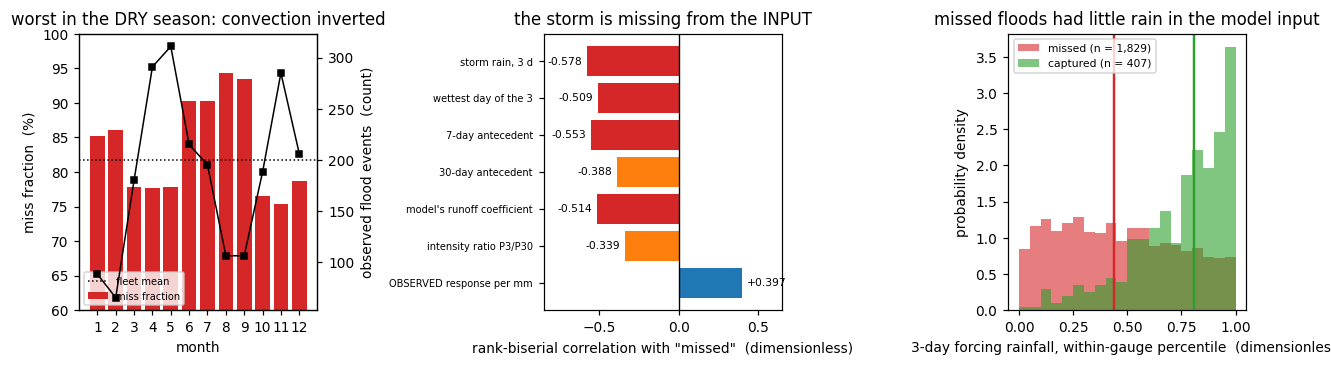

In [32]:
MISS = EV['missed'].to_numpy(bool)
print(f'{len(EV)} events: {int(MISS.sum())} missed, {int((~MISS).sum())} captured\n')
DISC = [('P3_pct', 'storm rain, 3 d (percentile)', 'f_storm_in_forcing'),
        ('Pmax3_pct', 'wettest day of the 3 (percentile)', 'f_storm_in_forcing'),
        ('P7_pct', '7-day antecedent (percentile)', 'b_antecedent'),
        ('P30_pct', '30-day antecedent (percentile)', 'b_antecedent'),
        ('qsur_rc_pct', "model's runoff coefficient (percentile)", 'b_antecedent'),
        ('intensity_ratio', 'intensity ratio P3/P30', 'b_antecedent'),
        ('obs_per_mm_pct', 'OBSERVED response per mm (percentile)', None)]
print(f'{"discriminator":<40}{"missed":>9}{"captured":>10}{"rank-biserial":>15}{"docs/36":>10}')
RB = {}
for col, lab, blk in DISC:
    v = EV[col].to_numpy(float)
    ok = np.isfinite(v)
    a_, b_ = v[ok & MISS], v[ok & ~MISS]
    u = stats.mannwhitneyu(a_, b_, alternative='two-sided')
    rb = 2 * u.statistic / (a_.size * b_.size) - 1
    RB[col] = rb
    ref = (GAP[blk][col]['rank_biserial'] if blk else
           GAP['i_obs_response_per_mm']['rank_biserial'])
    print(f'{lab:<40}{np.median(a_):9.3f}{np.median(b_):10.3f}{rb:+15.3f}{ref:+10.3f}')
print(f'\nabsolute rainfall: P3 {EV.loc[MISS,"P3"].median():.1f} vs '
      f'{EV.loc[~MISS,"P3"].median():.1f} mm; P7 {EV.loc[MISS,"P7"].median():.1f} vs '
      f'{EV.loc[~MISS,"P7"].median():.1f} mm; P30 {EV.loc[MISS,"P30"].median():.0f} vs '
      f'{EV.loc[~MISS,"P30"].median():.0f} mm')
frac_lo = float((EV.loc[MISS, 'P3_pct'] < 0.5).mean())
frac_lo_c = float((EV.loc[~MISS, 'P3_pct'] < 0.5).mean())
print(f'{100*frac_lo:.1f} % of missed events sit below their own gauge\'s median flood-day '
      f'rainfall, against {100*frac_lo_c:.1f} % of captured events')

HC = GAP['f_storm_x_antecedent']['storm_top_tercile']['dry_P30']
n_hort = int(round(HC['n'] * HC['miss_frac']))
print(f'\nHortonian candidate cell (missed AND top-tercile 3-day storm AND bottom-tercile '
      f'30-day antecedent):')
print(f'   {HC["n"]} such events, miss fraction {HC["miss_frac"]:.4f} -> {n_hort} events')
print(f'   = {100*n_hort/n_missed:.2f} % of the {n_missed:,} missed, '
      f'{100*n_hort/n_obs:.2f} % of all {n_obs:,} observed')

MO = pd.DataFrame(GAP['d_season']).T.astype(float)
MO.index = MO.index.astype(int)
MO = MO.sort_index()
jjas = MO.loc[[6, 7, 8, 9]]
onnd = MO.loc[[10, 11]]
mam = MO.loc[[3, 4, 5]]
print(f'\nseasonality: chi2 = {GAP["d_season_chi2"]["chi2"]:.1f}, dof '
      f'{GAP["d_season_chi2"]["dof"]:.0f}, p = {GAP["d_season_chi2"]["p"]:.2g}')
print(f'   Jun-Sep (DRY season)  miss {100*jjas["n_missed"].sum()/jjas["n_obs"].sum():.1f} % '
      f'over {int(jjas["n_obs"].sum())} events')
print(f'   Oct-Nov (WET peak)    miss {100*onnd["n_missed"].sum()/onnd["n_obs"].sum():.1f} % '
      f'over {int(onnd["n_obs"].sum())} events')
print(f'   Mar-May (WET peak)    miss {100*mam["n_missed"].sum()/mam["n_obs"].sum():.1f} % '
      f'over {int(mam["n_obs"].sum())} events')

fig, ax = plt.subplots(1, 3, figsize=(11.4, 3.4))
ax[0].bar(MO.index, 100 * MO['n_missed'] / MO['n_obs'], color='tab:red', label='miss fraction')
ax[0].axhline(100 * n_missed / n_obs, color='k', ls=':', lw=1.0, label='fleet mean')
ax0b = ax[0].twinx()
ax0b.plot(MO.index, MO['n_obs'], 'ks-', ms=4, lw=1.0, label='observed events')
ax0b.set_ylabel('observed flood events  (count)')
ax[0].set_xticks(range(1, 13))
ax[0].set_xlabel('month')
ax[0].set_ylabel('miss fraction  (%)')
ax[0].set_ylim(60, 100)
ax[0].set_title('worst in the DRY season: convection inverted')
ax[0].legend(fontsize=6.5, loc='lower left')

lab = [d[1] for d in DISC]
vals = [RB[d[0]] for d in DISC]
cols = ['tab:red' if v < -0.45 else ('tab:orange' if v < 0 else 'tab:blue') for v in vals]
ax[1].barh(range(len(vals)), vals, color=cols)
ax[1].axvline(0, color='k', lw=0.9)
for k, v in enumerate(vals):
    ax[1].text(v + (0.03 if v > 0 else -0.03), k, f'{v:+.3f}', va='center',
               ha='left' if v > 0 else 'right', fontsize=7)
ax[1].set_yticks(range(len(vals)))
ax[1].set_yticklabels([l.replace(' (percentile)', '') for l in lab], fontsize=6.5)
ax[1].set_xlabel('rank-biserial correlation with "missed"  (dimensionless)')
ax[1].set_xlim(-0.85, 0.65)
ax[1].invert_yaxis()
ax[1].set_title('the storm is missing from the INPUT')

bins = np.linspace(0, 1, 21)
ax[2].hist(EV.loc[MISS, 'P3_pct'], bins=bins, density=True, alpha=0.6, color='tab:red',
           label=f'missed (n = {int(MISS.sum()):,})')
ax[2].hist(EV.loc[~MISS, 'P3_pct'], bins=bins, density=True, alpha=0.6, color='tab:green',
           label=f'captured (n = {int((~MISS).sum())})')
ax[2].axvline(EV.loc[MISS, 'P3_pct'].median(), color='tab:red', lw=1.6)
ax[2].axvline(EV.loc[~MISS, 'P3_pct'].median(), color='tab:green', lw=1.6)
ax[2].set_xlabel('3-day forcing rainfall, within-gauge percentile  (dimensionless)')
ax[2].set_ylabel('probability density')
ax[2].set_title('missed floods had little rain in the model input')
ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

**What is plotted.** *Left:* the miss fraction by calendar month (red bars, left axis, %) with the
number of observed flood events per month (black line, right axis) - the second series matters
because a high miss fraction in a month with few events is a different claim from one in a busy
month. *Middle:* the rank-biserial correlation of each candidate discriminator with being missed;
negative means missed events score *lower*. *Right:* the distribution of the 3-day forcing rainfall
percentile for missed (red) and captured (green) events, with medians as vertical lines.
Dimensionless except where noted.

**What it shows.** All three Hortonian fingerprints point the wrong way. (i) The **intensity ratio
is inverted**: missed events have rank-biserial $-0.339$, i.e. their short-burst rain is *lower*
relative to accumulation, not higher. (ii) **Seasonality is inverted**: clustering is highly
significant ($\chi^2 = 63.1$, 11 dof, p $= 2.5\times10^{-9}$) but the worst months are the
**June-September dry season** (91.5 % missed over 622 events; August 94.3 %, September 93.4 %) and
the best are the two rainy peaks, October-November (75.9 %) and March-May (77.7 %). (iii) The
**candidate cell is small**: events that are missed *and* in the top within-gauge tercile of 3-day
storm rain *and* in the bottom tercile of 30-day antecedent number **99 - 5.4 % of the missed events
and 4.4 % of all observed floods**.

Meanwhile one discriminator dominates every other: **the 3-day storm rainfall in the model's own
forcing field, rank-biserial $-0.578$** (p $= 1.2\times10^{-74}$), median percentile 0.441 for
missed against 0.810 for captured, 29.9 mm against 49.8 mm in absolute terms. **55.8 %** of missed
events sit below their own gauge's median flood-day rainfall, against 12.3 % of captured events. And
the **observed** response per mm of forcing rainfall runs the other way ($+0.397$): 0.568 for missed
against 0.286 for captured. The model's own runoff coefficient at missed events is 0.212 against
0.270 at captured ones.

*(Provenance, because §0's rule is that every prose number was printed by a cell and these three
were not: the p-value $1.2\times10^{-74}$ is `f_storm_in_forcing.P3_pct.mwu_p`, the August 94.3 %
and September 93.4 % miss fractions are `d_season`, and the runoff coefficients 0.212 / 0.270 are
`b_antecedent.qsur_rc` - all read from the committed `peakgap/summary.json` the cell above already
loads. The cell prints the runoff coefficient as a within-gauge **percentile** (0.448 against
0.770), not as the raw coefficient.)*

**What it means.** The infiltration-excess hypothesis is **refuted as the primary cause and bounded
at $\approx 5$ %**: even at 100 % attribution, a Hortonian module recovers 99 of 1,829 events. What
the evidence points at instead is the **input**: the catchment responded (observed peak per mm of
rainfall is *twice* as high at missed events) while the rainfall field did not contain a storm. The
engine generated less runoff mainly because it was handed less rain. Even the model's own runoff
coefficient being *lower* at missed events is consistent with that: less rain on drier antecedent
soil generates proportionally less saturation-excess runoff, which is **correct** behaviour for the
mechanism the engine has.

## 7.3 - Mechanism 3: the rainfall field is missing the storms - SUPPORTED, at moderate confidence

The rainfall the model is forced with is built by **IDW** - inverse distance weighting - which
estimates rainfall at an unmeasured point as a weighted average of nearby gauge measurements, with
weights falling off as distance$^{-p}$. It is the simplest defensible spatial interpolator and it
has one structural weakness that matters here: **it cannot reproduce a storm no gauge recorded.**
Convective cells here are a few kilometres across; the gauge network's spacing is of the order of
30 km. A storm that falls between gauges is, to the model, a storm that did not happen.

Two more terms, needed to state what is already known about that field:

- **LOOCV** (leave-one-out cross-validation): hold out one gauge, interpolate its rainfall from all
  the others, compare with what it actually recorded, and repeat for every gauge. It measures how
  much of the *real* rainfall field the interpolation reconstructs. For this network the median
  daily LOOCV correlation is **0.429** - a hard ceiling on how well any model driven by this field
  can time a flood.
- **Quantile mapping**: a bias-correction technique that rescales one dataset's distribution onto
  another's, quantile by quantile. It was used in an attempt to merge satellite rainfall (CHIRPS)
  with the gauge field; the merged product was **rejected on pre-registered gates** because its
  basin areal mean came out 7.5 % too high. That rejection stands and is not re-opened here.

**The verdict, at the confidence the evidence supports.**

> **The peak deficit is an input-data problem, not a runoff-engine problem.** Its proximate cause is
> that the daily rainfall field does not contain the storms that produced ~82 % of the observed
> flood events. This is the $r \approx 0.57$ correlation ceiling already established for this model,
> expressed at **event** scale rather than at series scale.
>
> Held with **moderate, not high, confidence** - because it is diagnosed *against the field it
> accuses*.

**The circularity, stated plainly rather than buried.** An input that lacks a storm will always look
like the cause of a missed flood. What partially breaks the circle is the ABSENT class: a missing
*mechanism* cannot manufacture a flood out of near-zero rain, and 55.4 % of ABSENT events have
near-zero rain in the field - so the mechanism hypotheses are ruled out as *primary*, which is a
weaker and safer claim than proving the rain was really there. The clean test - asking an
**independent** rainfall product (CHIRPS) whether it sees the storms behind those 1,829 events, with
the 407 captured events as a built-in control - is pre-registered in `docs/36` §5 and **was not run
here**; this notebook's scope is C2b, and that audit is a separate stage.

**Two things this notebook does not claim.** First, that the observations are all correct: up to
10 % of observed events (224 of 2,236 single-day spikes rising more than threefold with no rain in
the forcing) could be rating-curve or transcription artefacts - the rating curve (§1.1.1) being
extrapolated at exactly the high flows this notebook is about. That is an **upper bound, not an
estimate**, and it does not discount the lower-bound framing. Second, that a denser rainfall
network would fix it: the obvious candidate network's station density nearly **doubles** between the
La Niña and the El Niño windows, which would inject a non-climatic trend into the very contrast the
project exists to measure.

## 7.4 - This is a named, published limitation of the method itself

One piece of context stops this from reading as a local embarrassment. The peak deficit is a
**documented limitation of MGB-SED as published**, not a defect introduced by this application.
Fagundes (2018) §6.4.1 states that the peak-energy term MUSLE would need *"é desconsiderada pela
dificuldade de se obter tal informação"* - is disregarded because of the difficulty of obtaining
that information - and §6.4.2 that *"o modelo também não representou de forma adequada grandes
picos de concentração"* - the model also did not adequately represent large concentration peaks.

**This citation is inherited from `docs/36` §8 and was not verified against the source by this
notebook**, which is stated so that a reader knows which claims here rest on measurement and which
on a reference. The measurements are ours; the precedent is theirs.

What *is* ours is the quantification. `R_AMS` 0.820, `R_Q1` 0.847, `R_Q5` 0.975, `R_POT` 0.567, an
81.8 % event-identity deficit, El Niño `R_AMS` 0.686 - that is **more specific than anything
published for MGB-SED**, which makes it a contribution rather than an apology.

## 7.5 - What C3 and C4 inherit as a lower bound

Two final terms, needed to state the inheritance precisely and to keep it inside this project's
embargo:

- **Sediment delivery ratio (SDR)**: the fraction of the soil eroded on hillslopes that actually
  reaches the river network, the rest being deposited on the way. Dimensionless, in $[0,1]$.
- **Specific erosion**: eroded mass per unit area per unit time (e.g. t km$^{-2}$ yr$^{-1}$). Where
  such a number appears anywhere in this project it must be labelled **model-internal** - computed
  from the model's own minibacia areas - because gauge-referenced yields in t km$^{-2}$ yr$^{-1}$
  are **embargoed** (`docs/23`: catchment areas disagree by more than 2x on 36 % of shared gauges,
  and a per-area yield inherits that error one for one). **No such yield appears in this notebook.**

**The inheritance, stated as the sediment stages must carry it:**

1. **Simulated flood-driven sediment transport is a LOWER BOUND.** Low by at least **10.5 %**
   fleet-wide from the measured magnitude deficit alone, and at least **19.0 %** in the El Niño dry
   phase - before the event-count deficit is counted at all.
2. **The event deficit is not convertible into a factor.** $0.567^{0.56}$ is **not** a valid
   sediment ratio and is registered as forbidden arithmetic: an event that does not happen
   contributes zero load, not a scaled load. 33.0 % of observed floods produce no simulated rise.
3. **The simulated ENSO contrast is inflated by $\approx +10$ %** by the peak asymmetry, in the
   direction that flatters the headline. Quoted against an observed, model-free contrast of
   2.8x-4.6x (primary windows) with the same sign at 22 of 22 stations, a 10 % inflation cannot flip
   it - but if the two ever came within 10 % of each other, this caveat would become a refutation - which
   `docs/56` (C5, 2026-08-12) has since brought into play: a median modelled rate ratio of **3.05x**
   over 18 of 18 stations against its named reference estimator (b)'s observed **2.84-2.95**. The
   adjudication is `docs/56`'s and is **open**; §5.9 carries the detail. `docs/56` §2 also shows why
   the lower-bound framing of this list survives the C4.3 railing: the within-station wet/dry ratio
   is invariant to α and to the LS level.
4. **MUSLE's $\alpha$ and $\beta$ must not be allowed to absorb any of this.** The compensation
   available by tuning them is roughly 5x, so a calibration free to move them could hide the entire
   deficit and report a perfect fit. `docs/35` §6 registers hard stops for exactly that reason, and
   `docs/42` carries the guards that enforce them.
5. **One clause of the sediment verdict is OPEN, and this notebook does not close it.** `docs/37`
   amendment A1 leaves the implied sediment delivery ratio unresolved: the plausibility band it was
   originally to be tested against turned out to be **uncitable**, and this project's standing rule
   is that *an uncited plausibility band may not be used to pass **or** fail a gate*. The gate was
   therefore **retired in both directions**, not quietly passed. Nothing in §5-§7 above changes
   that; the peak deficit is a *lower-bound* statement about flood-driven transport and cannot by
   itself settle a delivery-ratio question.

---

# 8 - Problems, failures, refutations, and what a reader must NOT conclude

This project's value is its audit trail, so the failures get a section rather than a footnote.

## 8.1 - What was tried and failed

| # | attempt | outcome |
|---|---|---|
| 1 | **The H2E-S peak refit** (§6) | **REJECTED** on 2 of 3 pre-registered conditions. It reached the peak band (`R_AMS` 0.820 &rarr; 0.94-1.00) and paid with 1.60x the allowed objective budget and two new parameter rails, buying peaks by deleting canopy interception. No further refit is licensed. |
| 2 | **The daily-time-step explanation** (§7.1) | **REFUTED** with the fingerprint inverted: no area gradient ($\rho = +0.018$, p $= 0.89$), and if anything the larger catchments are worse. |
| 3 | **The infiltration-excess explanation** (§7.2) | **REFUTED as primary and bounded at 5.4 %**: inverted intensity ratio ($-0.339$), inverted seasonality (worst in the Jun-Sep dry season at 91.5 %), and a candidate cell of 99 events. |
| 4 | **Lowering the filter's ceiling to give H-BFI more power** (§3.5) | **measured and rejected**: the fleet-median BFI tracks $\mathrm{BFI_{max}}$ with slope 0.962 and the gate ratio stays in 0.45-0.74 across eight values, so no choice of the knob makes the test sharper. |

## 8.2 - Beliefs this stage corrected

1. **"The model misses 43 % of flood events" was the wrong framing.** That is a *count* deficit. The
   **event-identity** deficit at $\pm 2$ days is **81.8 %**, and the mirror statistic - simulated
   peaks with no observed counterpart - is **68.3 %**. Both must now be quoted together.
2. **"It might be a timing shift" is refuted.** Widening the matching window from $\pm 2$ d to
   $\pm 30$ d recovers only 15.6 percentage points and never approaches the 57.5 % ceiling.
3. **"$\alpha < 1$ tells you how big the peak deficit is" understates it by half.** $\alpha$ is a
   whole-record dispersion ratio: $-9.5$ % on the full validation record, $-0.4$ to $-11.7$ % across
   periods. The annual-maximum deficit is $-18.0$ %.
4. **"A pass on H-BFI validates the flow partition" is an over-reading.** The test has weak power
   (§4.6), the model carries no between-gauge information ($r = +0.094$), and the *internal*
   partition - the quantity MUSLE actually consumes - remains untested.

## 8.3 - Disagreements with project documents, reported not smoothed

Six, all found by recomputing rather than transcribing. None changes a verdict. Items 5 and 6 were
added on 2026-08-19; item 6 collects this notebook's disagreements with **itself**.

| # | document | says | this notebook computes |
|---|---|---|---|
| 1 | `docs/33` §8 | the recomputed peak-scale $F$ reproduces each archived $F$ **"exactly"** | it reproduces to a **relative $7\times10^{-10}$ and $3\times10^{-10}$** - the float32 precision of the archived per-gauge terms. "Exact to float32" is the accurate wording. |
| 2 | `docs/33` §7.7 | event-matched propagation $0.552^{0.56} = 0.723$, i.e. $-27.7$ % | $0.552^{0.56} = \mathbf{0.7169}$, i.e. $\mathbf{-28.3}$ %. (0.723 corresponds to $R = 0.5595$.) A diagnostic row, not a gate. |
| 3 | `docs/33` §7.3 | excluding the 7 short-record gauges "moves nothing material" | the fleet median $R_{\mathrm{AMS}}$ moves **0.8200 &rarr; 0.7676**, larger than the gate margin - but *deeper* below the band, so the refutation is strengthened, not threatened. |
| 4 | `docs/33` §7.2 | the deficit "switches on somewhere between the 95th and the 99th percentile" | with the full quantile ladder the **crossing of unity is between the 90th and the 95th** (1.045 &rarr; 0.975) and the deficit deepens monotonically to the annual maximum. A refinement, not a contradiction. |
| 5 | `docs/agents/journal_refit-launch.md`, quoted in §6.3 and §8.4 | the incumbent's calibration-window fleet-median $R_{\mathrm{AMS}}$ is **0.6482** | §5.4's recomputation of that same window from the committed `c2b/peaks_per_gauge.csv` gives **0.6478**. Both round to 0.648, which is how §5.4 and §6.1 quote it. The two are formed on different day sets - the peaks table's $\ge$ 180-day segment rule against the objective's $\ge$ 300-valid-day calendar-year rule - which is the likely source, but that was **not** run down. A calibration-window diagnostic; no gate reads it. |
| 6 | *this notebook, prose against its own printed cells* | four prose figures did not match the cell that printed them: §5.4 read the La Niña propagation as ~~$-11.5$ %~~, §5.10 item 3 read the contrast inflation as ~~$+9.3$ %~~, §8.1 row 4 and §10 read the BFI$_{max}$ tracking slope as ~~0.966~~ and ~~0.97~~, and §9 row 1 read §1.3's synthetic MUSLE peak factor as ~~1.97x~~ | corrected on 2026-08-19 to the values the cells actually print: **$-11.3$ %** ($0.8078^{0.56} = 0.8873$, §5.9's cell), **$+9.6$ %** (§5.9's cell and its figure title), **0.962** (§3.5's cell prints 0.9621) and **1.56x** (§1.3's cell, 0.669 against 1.046). The retired figures are shown struck through rather than deleted. No verdict reads any of them. |

## 8.4 - Objections journalled under the freeze rule, and followed anyway

The pre-registration's rule is that a session which believes a frozen rule is wrong **journals the
objection and follows the rule**. These were:

1. **The gate window and the objective window differ.** `docs/33` §2.3 defines $R_{\mathrm{AMS}}$ on
   the full 2009-2018 record, but the objective necessarily scores the calibration window 2012-2014,
   where the incumbent's own median $R_{\mathrm{AMS}}$ is **0.6482** rather than 0.8200
   (`docs/agents/journal_refit-launch.md`). **Consequence, stated as an open issue: condition 1 in
   §6.2.1 and the frontier in §6.3 are calibration-window statements.** The full-record
   $R_{\mathrm{AMS}}$ of the refit's fitted vectors was never computed and cannot be computed
   cheaply - it needs a full ten-year engine run and a rebuilt gauge file, and no such artifact
   exists for H2E-S. It does not change the verdict, which rests on conditions 2 and 3.
2. **Annual maxima were taken on calendar years**, not water years, because §2.3 specifies calendar
   years. A water-year definition would split the wet season differently.
3. **The $\ge 1{,}095$-day gauge rule is written for the BFI statistic only** and was therefore not
   applied to the peak statistics; the 7 affected gauges are flagged rather than dropped (see
   §8.3 item 3 for what dropping them would do).
4. **The POT *candidate* rule was not fixed** by the pre-registration, only the independence rule.
   Candidates were taken as all local maxima above the threshold and merged pairwise, applied
   identically to both series.
5. **12 of the 63 gauges contribute no peak term at all** (no calibration year with $\ge 300$ valid
   days), so the refit's objective saw the signature at 51 gauges; `blend` renormalises those 12
   onto their remaining terms, which is the pre-registered behaviour for a missing signature.
6. **Event timing (§5.7) was not pre-registered.** It is fenced off as diagnostic and no gate reads
   it.

## 8.5 - Known weaknesses of this notebook's own evidence

1. **The rainfall diagnosis is partly self-referential** (§7.3): it accuses the field it is computed
   from. The pre-registered CHIRPS witness test that would break the circularity was not run here.
2. **The matching code is not committed.** `docs/36` §7 item 10 records that the script producing
   `peakgap/events.csv` and `match_sensitivity.csv` lives only in a session scratchpad. This
   notebook re-derives every **aggregate** from those committed outputs and reproduces them to
   $<10^{-9}$, but it **cannot re-derive the event matching itself** - that step is trusted, not
   verified. A session needing it must rewrite it from `scripts/c2b/peaks_measure.py`, from which it
   was copied.
3. **The observation-side channel is an upper bound.** 224 of 2,236 events (10.0 %) are single-day
   spikes that could be rating-curve artefacts, but at daily resolution a genuine one-day convective
   flood in an ungauged-rainfall headwater is indistinguishable from a bad reading. It must not be
   used to discount the lower bound.
4. **The timing lag is window-dependent.** From the committed table's own columns
   (`lag_med_abs_d_w10`, `lag_med_abs_d`, `lag_med_abs_d_w20` in `c2b/peaks_per_gauge.csv`) the fleet
   median absolute lag of large events is **2 d, 4 d and 6 d** at search windows of $\pm 10$,
   $\pm 15$ and $\pm 20$ days - it simply tracks the window, because 15 % of events land on the
   window edge. **"The model is 4 days off" is therefore not a valid statement.** The
   window-independent facts are that the *signed* lag has fleet median **0 d** (IQR $-1$ to $+1$, so
   no systematic early or late bias) and that only ~45 % of large observed events have a simulated
   peak within two days. This notebook does not plot the lag statistics for exactly that reason.
5. **`R_Q1` is marginal.** It fails its bound by 0.003. It is recorded as marginal and is explicitly
   not the load-bearing statistic; `R_AMS` at 0.820 is 0.030 clear.

## 8.6 - What a reader should NOT conclude

- **NOT** that the flow partition is validated. H-BFI is *not refuted*, which is a much weaker
  statement, and the internal partition MUSLE consumes was never tested (§4.5, §4.6).
- **NOT** that the model cannot produce large floods. It can - the refit proved it (condition 1
  passed). What it cannot do is produce them while remaining defensible (§6.4).
- **NOT** that a denser rainfall network is the fix. It is the option with the largest gain ceiling
  and it carries a possibly disqualifying flaw of its own: station density nearly doubles between
  the two ENSO windows.
- **NOT** that a sub-daily model would fix it. That mechanism was measured and refuted (§7.1).
- **NOT** that the sediment result is invalid. It is **qualified**: simulated flood-driven transport
  is a lower bound, with the size of the bound measured rather than assumed (§7.5).
- **NOT** that the $-10.5$ % figure is the total sediment bias. It is the magnitude term only and it
  is a floor.

---

# 9 - Every choice on this page, and the alternative it rejected

| choice | taken | alternative rejected, and why |
|---|---|---|
| validate the **drivers** rather than discharge | BFI and peak signatures against observation | *carry on with discharge KGE alone* - rejected because MUSLE reads $Q_{\text{sur}}$ and $q_{\text{peak}}$, and §1.3 demonstrates two series a discharge score cannot separate whose MUSLE peak factor differs by 1.56x |
| baseflow separation method | Eckhardt two-parameter filter | *a graphical / straight-line separation* - not reproducible; *a tracer-based separation* - no isotope data for this basin |
| $\mathrm{BFI_{max}}$ | **FIXED at 0.80**, Eckhardt's perennial porous-aquifer value | *fit it per gauge* - the standard practice that makes much of the BFI literature worthless: a free $\mathrm{BFI_{max}}$ can produce almost any BFI, so a validation done with one validates nothing |
| the recession constant $a$ | from the **observed** master recession curve, same $a$ for both series | *let the simulation supply its own $a$* - would let the model define its own yardstick and stop the comparison being apples-to-apples |
| the H-BFI yardstick | the between-gauge **IQR of observed BFI** | *an invented constant such as 0.05* - unjustifiable; the data's own spread is self-scaling and symmetric |
| the peak gate | fleet-median $R_{\mathrm{AMS}}$ and $R_{\mathrm{Q1}}$ in $[0.85, 1.15]$ | *use the event count $R_{\mathrm{POT}}$* - it is the more alarming statistic (0.567) and was deliberately left as a diagnostic, so the gate could not be made easier *or* harder after the fact |
| the peak-term shape | $1 - |\ln R| / \ln 1.5$, symmetric in log space | *a one-sided penalty on low peaks* - would encode a preferred direction; an over-predicted peak damages a sediment claim exactly as much |
| the $F$ comparison scale | re-scored at the **incumbent** weights (§6.2) | *compare the refit's native $F$ with the incumbent's* - not like-for-like, since adding a term changes the quantity; registering the scale in advance is what stops a session picking whichever flatters |
| the median over years and gauges | median throughout | *the mean* - annual maxima and recession lengths are heavy-tailed, and one freak year or one pathological gauge must not set a fleet verdict |
| catchment areas | the model's own topology | *the national catalogue* - the two disagree by >2x on 36 % of shared gauges (`docs/23` §13.2) |
| the example gauge (§3.4, §1.3) | 21147030: long record, mid-size, near-median BFI error | *the worst gauge* - unrepresentative; the worst are named in §4.2 and §5.3 instead |
| the day set for peaks | copied verbatim from `scripts/c2b/peaks_measure.py` and **validated** to $2\times10^{-16}$ | *re-derive it here* - a second implementation is a second thing to drift; *import the script* - it executes on import |
| re-scoring cost | from the **search archives'** per-gauge terms, no engine run | *re-run the engine at the fitted vectors* - hours of compute for numbers the archives already contain, and this notebook is required not to re-run expensive work |
| what to do about the peak deficit | **accept it and propagate it as an explicit lower bound** | *a second refit* (not licensed - §6.6); *sub-daily forcing* (mechanism refuted, engine does not exist); *an infiltration-excess module* (bounded at 5.4 %); *within-day disaggregation* (cannot move a daily water balance); *new routing* (downstream of generation, and MUSLE's source term is upstream of routing - gain exactly zero) |

---

# 10 - Summary

**The stage in one paragraph.** MUSLE consumes surface runoff and peak flow; Phase B fitted the
model on total discharge, which is blind to the first and nearly blind to the second. Two
pre-registered hypotheses tested them. The flow-partition hypothesis (H-BFI) was **not refuted**
(median error 0.0163 against a gate of 0.0285) but the test had weak power - the filter's output
tracks its own fixed constant with slope 0.96, the model carries no between-gauge information about
flow character ($r = +0.094$), and the error is concentrated in the small catchments where erosion
is generated. The flood-peak hypothesis (H-PEAK) was **refuted**: annual maxima 18.0 % low
($R_{\mathrm{AMS}} = 0.820$), 1 %-exceedance flows 15.3 % low, only 57.5 % as many independent flood
events, and - the deeper number - **81.8 % of the 2,236 observed flood events have no simulated
counterpart within $\pm 2$ days**, with a third of them producing no simulated hydrograph rise at
all. The registered refit **fixed the peaks and was rejected**, on 2 of 3 conditions fixed before it
ran: it cost 1.60x the allowed objective budget and re-railed the two parameters that control
evapotranspiration and canopy interception, i.e. it bought floods by deleting the canopy. Both
engine-side mechanism hypotheses were then measured and refuted with inverted fingerprints. The
deficit is **structural**, its proximate cause is the rainfall field rather than the runoff engine,
and it is a named, published limitation of MGB-SED itself - now quantified more precisely than
anything in that literature.

| question | answer | evidence |
|---|---|---|
| does the model partition water like the rivers? | **not refuted, weak power** | 0.01625 vs 0.02845; $r_{\text{cross}} = +0.094$; §4 |
| does it reproduce flood peaks? | **NO** | $R_{\mathrm{AMS}}$ 0.820, $R_{\mathrm{Q1}}$ 0.847, both below [0.85, 1.15]; §5.1 |
| where is the peak deficit? | the extreme tail only | ratio crosses 1 between the 90th and 95th percentile; §5.2 |
| is it a timing problem? | **no** | $\pm 30$ d recovers 15.6 points of 82; §5.7 |
| can parameters fix it? | **yes, indefensibly** | condition 1 passed; conditions 2 and 3 failed; §6 |
| is it the daily time step? | **no** | $\rho$(miss, area) $= +0.018$, p $= 0.89$; §7.1 |
| is it missing Hortonian runoff? | **no, $\le 5.4$ %** | inverted intensity and seasonality; §7.2 |
| what is it, then? | the rainfall field, at moderate confidence | storm rainfall rank-biserial $-0.578$; observed response per mm twice as high at missed events; §7.3 |
| what does sediment inherit? | a **lower bound**: $\ge 10.5$ % low, $\ge 19$ % in El Niño, contrast inflated $\approx +10$ % | §5.10, §7.5 |

**What would falsify this notebook's conclusions**, rather than merely limit them:

- the copied day-set code failing to reproduce the committed per-gauge table (it matches to
  $2\times10^{-16}$);
- the native-scale $F$ recomputation failing to reproduce what the searches stored (it matches to
  $7\times10^{-10}$);
- an area gradient in the miss fraction, which would revive the resolution hypothesis (measured:
  $\rho = +0.018$, p $= 0.89$);
- a matching-window curve that approached its ceiling, which would make the deficit a timing shift
  (it recovers 15.6 points out of a possible 82 at a full month);
- an independent rainfall product that also fails to see the storms behind the missed events, which
  would weaken §7.3's verdict sharply and make acceptance the *only* defensible position. That test
  is pre-registered and **has not been run**.

**Status.** Phase B closes for the second time - not on exhausted headroom but on a **measured
conflict** between a driver signature and the objective. The adopted configuration H2E remains the
Phase C driver set. The peak bias travels with it as a named, quantified caveat rather than a hidden
one.